In [ ]:
import pandas as pd
df=pd.read_csv("comprehensive_features-DeepFakeDetection.csv")
df.shape

(367, 1569)

In [10]:
import pandas as pd
import numpy as np

def reshape_dataset(input_csv, output_csv, original_frames=224, new_frames=56, features_per_frame=7):
    """
    Reshapes dataset by splitting each row into multiple segments
    Args:
        input_csv: Path to input CSV file
        output_csv: Path to save transformed CSV
        original_frames: Original frames per row (224)
        new_frames: New frames per row (56)
        features_per_frame: Number of features per frame (7)
    """
    # Calculate splitting parameters
    split_factor = original_frames // new_frames  # 224/56 = 4
    new_feature_columns = new_frames * features_per_frame  # 56*7 = 392
    
    # Read original data
    df = pd.read_csv(input_csv, header=None)
    print(f"Original dataset shape: {df.shape}")
    
    # Create new dataframe
    new_data = []
    
    for idx, row in df.iterrows():
        # Separate features and label
        features = row.values[:-1].astype(np.float32)
        label = row.values[-1]
        
        # Reshape to (224,7)
        frame_data = features.reshape(original_frames, features_per_frame)
        
        # Split into 4 chunks of (56,7)
        for i in range(split_factor):
            start_idx = i * new_frames
            end_idx = (i+1) * new_frames
            
            # Extract and flatten segment
            segment = frame_data[start_idx:end_idx].flatten()
            new_row = np.concatenate([segment, [label]])
            
            new_data.append(new_row)
    
    # Create new dataframe
    new_df = pd.DataFrame(new_data)
    print(f"New dataset shape: {new_df.shape}")
    
    # Save results
    new_df.to_csv(output_csv, index=False, header=False)
    print(f"Saved transformed data to {output_csv}")

# Usage
reshape_dataset(
    input_csv="comprehensive_features-FaceSwap.csv",
    output_csv="comprehensive_features-FaceSwap_new.csv",
    original_frames=224,
    new_frames=56,
    features_per_frame=7
)


Original dataset shape: (230, 1569)
New dataset shape: (920, 393)
Saved transformed data to comprehensive_features-FaceSwap_new.csv


In [73]:
df_1=pd.read_csv("eyebrow_features_deepfake.csv",header=None)
df_2=pd.read_csv("eyebrow_features_DeepFakeDetection.csv",header=None)
df_3=pd.read_csv("eyebrow_features_FaceSwap.csv",header=None)
df_4=pd.read_csv("eyebrow_features_Face2Face.csv",header=None)
print(df_1[225].value_counts())
print(df_2[225].value_counts())
print(df_3[225].value_counts())
print(df_4[225].value_counts())
print()
df_1=pd.read_csv("eyeblink_dataset-deepfake.csv",header=None)
df_2=pd.read_csv("eyeblink_dataset-DeepFakeDetection.csv",header=None)
df_3=pd.read_csv("eyeblink_dataset-FaceSwap.csv",header=None)
df_4=pd.read_csv("eyeblink_dataset-Face2Face.csv",header=None)
print(df_1[450].value_counts())
print(df_2[450].value_counts())
print(df_3[450].value_counts())
print(df_4[450].value_counts())
print()
df_1=pd.read_csv("comprehensive_features-deepfake_new.csv",header=None)
df_2=pd.read_csv("comprehensive_features-DeepFakeDetection_new.csv",header=None)
df_3=pd.read_csv("comprehensive_features-FaceSwap_new.csv",header=None)
df_4=pd.read_csv("comprehensive_features-Face2Face_new.csv",header=None)
print(df_1[392].value_counts())
print(df_2[392].value_counts())
print(df_3[392].value_counts())
print(df_4[392].value_counts())

225
0    742
1    742
Name: count, dtype: int64
225
1    1016
0     742
Name: count, dtype: int64
225
0    742
1    592
Name: count, dtype: int64
225
0    742
1    742
Name: count, dtype: int64

450
0    742
1    742
Name: count, dtype: int64
450
1    1029
0     742
Name: count, dtype: int64
450
0    742
1    592
Name: count, dtype: int64
450
0    742
1    742
Name: count, dtype: int64

392
0    1132
1    1132
Name: count, dtype: int64
392
1    1472
0    1132
Name: count, dtype: int64
392
0    1132
1     920
Name: count, dtype: int64
392
0    1132
1    1132
Name: count, dtype: int64


Model architecture:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 75, 64)         │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 75, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 37, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 37, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 37, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,009 (136.75 KB)

 Trainable params: 34,625 (135.25 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
15/15 - 2s - 156ms/step - accuracy: 0.6006 - auc: 0.6440 - loss: 0.6835 - precision: 0.5923 - recall: 0.6484 - val_accuracy: 0.5294 - val_auc: 0.6257 - val_loss: 0.6840 - val_precision: 1.0000 - val_recall: 0.0588
Epoch 2/100
15/15 - 0s - 18ms/step - accuracy: 0.6428 - auc: 0.6878 - loss: 0.6435 - precision: 0.6288 - recall: 0.6989 - val_accuracy: 0.5378 - val_auc: 0.5734 - val_loss: 0.6850 - val_precision: 0.5584 - val_recall: 0.3613
Epoch 3/100
15/15 - 0s - 19ms/step - accuracy: 0.6344 - auc: 0.6909 - loss: 0.6371 - precision: 0.6306 - recall: 0.6505 - val_accuracy: 0.5756 - val_auc: 0.5875 - val_loss: 0.6864 - val_precision: 0.6098 - val_recall: 0.4202
Epoch 4/100
15/15 - 0s - 18ms/step - accuracy: 0.6533 - auc: 0.7179 - loss: 0.6193 - precision: 0.6327 - recall: 0.7326 - val_accuracy: 0.5630 - val_auc: 0.6276 - val_loss: 0.6764 - val_precision: 0.5610 - val_recall: 0.5798
Epoch 5/100
15/15 - 0s - 18ms/step - accuracy: 0.6670 - auc: 0.7247 - loss: 0.6110 - precision: 0.6

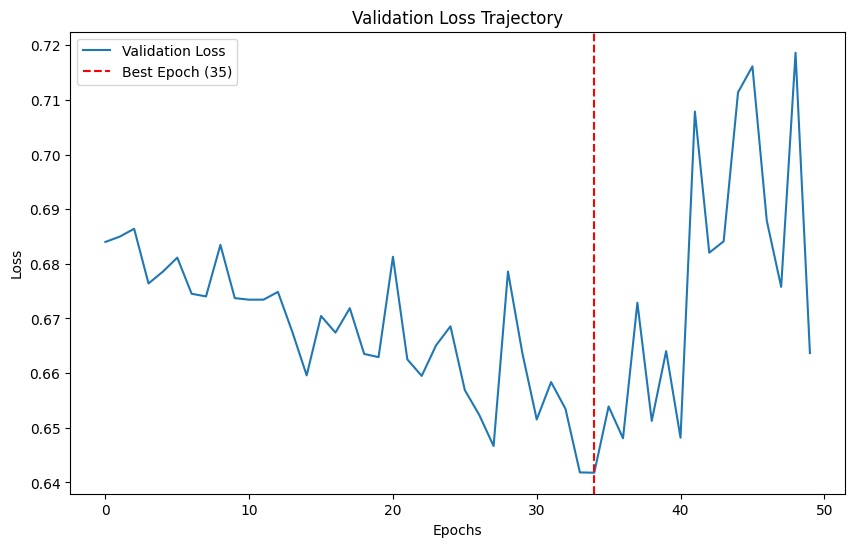

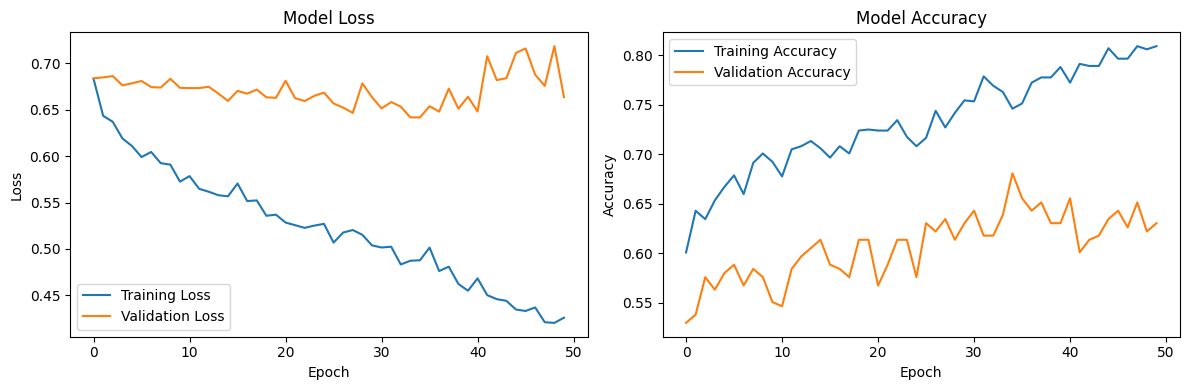


Final evaluation:
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6651 - auc: 0.7159 - loss: 0.6477 - precision: 0.6502 - recall: 0.5755 
Metrics Dictionary: {'loss': 0.6730555295944214, 'compile_metrics': 0.6531986594200134}
Manually calculated accuracy: 0.6532

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.73      0.68       149
           1       0.68      0.57      0.62       148

    accuracy                           0.65       297
   macro avg       0.66      0.65      0.65       297
weighted avg       0.66      0.65      0.65       297


Test Metrics Summary:
Test loss: 0.6731
Test compile_metrics: 0.6532
Test accuracy: 0.6532


In [3]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import os
# from tensorflow import keras


class EyebrowDeepfakeDetector:
    def __init__(self, model_type='lstm', input_shape=(75, 6), num_classes=1):
        self.model_type = model_type
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()
        self.scaler = StandardScaler()

    def _build_model(self):
        """Build and compile the model based on specified architecture type"""
        if self.model_type == 'lstm':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'gru':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'cnn':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling1D(2),
                tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.GlobalAveragePooling1D(),
                tf.keras.layers.Dense(64, activation='relu'),
                tf.keras.layers.Dropout(0.3),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'transformer':
            inputs = tf.keras.Input(shape=self.input_shape)
            pos_encoding = self._positional_encoding(self.input_shape[0], self.input_shape[1])
            x = inputs + pos_encoding[:, :self.input_shape[0], :]
            
            # Transformer block
            x = tf.keras.layers.MultiHeadAttention(
                num_heads=4, key_dim=self.input_shape[1])(x, x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Feed forward network
            x = tf.keras.layers.Dense(128, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Classification head
            x = tf.keras.layers.GlobalAveragePooling1D()(x)
            x = tf.keras.layers.Dense(64, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.2)(x)
            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
            
            model = tf.keras.Model(inputs=inputs, outputs=outputs)
            
        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
            
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss='binary_crossentropy',
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ]
        )
        return model

    def _positional_encoding(self, max_length=75, d_model=6):
        """Generate positional encoding for transformer"""
        positions = np.arange(max_length)[:, np.newaxis]
        depths = np.arange(d_model)[np.newaxis, :]/d_model
        
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.zeros(angle_rads.shape)
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        
        return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

    def load_data(self, csv_path):
        """Load and reshape eyebrow movement data"""
        df = pd.read_csv(csv_path, header=None)
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(np.int32)
        
        # Reshape to (samples, 75, 3)
        if X.shape[1] == 450:  # Verify input dimensions
            X = X.reshape(-1, 75, 6)
        return X, y

    def preprocess_data(self, X, y, test_size=0.2):
        """Standardize features and split data"""
        # Stratified train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=42)
        
        # Feature-wise standardization
        orig_shape = X_train.shape
        self.scaler.fit(X_train.reshape(-1, 6))
        X_train = self.scaler.transform(X_train.reshape(-1, 6)).reshape(orig_shape)
        X_test = self.scaler.transform(X_test.reshape(-1, 6)).reshape(X_test.shape)
        
        return X_train, X_test, y_train, y_test

    def train(self, X_train, y_train, X_val, y_val, epochs=100):
        """Train model with early stopping and checkpointing"""
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(
                f'best_{self.model_type}_model.keras', save_best_only=True)
        ]
        
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=64,
            callbacks=callbacks,
            verbose=2
        )

        # Print final training metrics
        print("\nFinal Training Metrics:")
        for metric in history.history:
            if not metric.startswith('val_'):
                print(f"Training {metric}: {history.history[metric][-1]:.4f}")
        
        # Print final validation metrics
        print("\nFinal Validation Metrics:")
        for metric in history.history:
            if metric.startswith('val_'):
                print(f"{metric}: {history.history[metric][-1]:.4f}")

                # Analyze stopping reason
        best_epoch = np.argmin(history.history['val_loss']) + 1
        print(f"Best model found at epoch {best_epoch}")

        # Plot validation metrics trajectory
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.axvline(x=best_epoch-1, color='r', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
        plt.title('Validation Loss Trajectory')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        return history

    def evaluate(self, X_test, y_test):
        """Comprehensive model evaluation"""
        # Quantitative metrics
        results = self.model.evaluate(X_test, y_test, verbose=1)
        metrics = dict(zip(self.model.metrics_names, results))
        
        # Debug: Print the metrics dictionary
        print("Metrics Dictionary:", metrics)
        
        # Qualitative analysis
        y_pred_prob = self.model.predict(X_test,verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        # Calculate and print accuracy directly
        from sklearn.metrics import accuracy_score
        calc_accuracy = accuracy_score(y_test, y_pred)
        print(f"Manually calculated accuracy: {calc_accuracy:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        plt.xticks([0, 1], ['Real', 'Fake'])
        plt.yticks([0, 1], ['Real', 'Fake'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(f'{self.model_type}_confusion_matrix.png')
        plt.close()
        
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.savefig(f'{self.model_type}_roc_curve.png')
        plt.close()
        
        # Ensure accuracy is in the metrics dictionary
        if 'accuracy' not in metrics:
            metrics['accuracy'] = calc_accuracy
        
        return metrics


# Usage example
if __name__ == "__main__":
    # Initialize detector - choose model type
    detector = EyebrowDeepfakeDetector(model_type='cnn', input_shape=(75, 6))
    
    # Load and preprocess data
    X, y = detector.load_data(os.path.join("","eyeblink_dataset-deepfake.csv"))
    X_train, X_test, y_train, y_test = detector.preprocess_data(X, y)
    
    # Split validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # Train model
    print("Model architecture:")
    detector.model.summary()
    history = detector.train(X_train, y_train, X_val, y_val)
    
        # Plot training history
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{detector.model_type}_training_history.png')
    plt.show()
    plt.close('all')

    # Evaluate
    print("\nFinal evaluation:")
    test_metrics = detector.evaluate(X_test, y_test)

        # Print all metrics in a formatted way
    print("\nTest Metrics Summary:")
    for metric_name, metric_value in test_metrics.items():
        print(f"Test {metric_name}: {metric_value:.4f}")

    # Save final model
    detector.model.save(f'final_{detector.model_type}_model.keras')


Model architecture:


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 75, 64)         │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 75, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 37, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 37, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 37, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_5      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,009 (136.75 KB)

 Trainable params: 34,625 (135.25 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
18/18 - 3s - 142ms/step - accuracy: 0.6007 - auc: 0.6236 - loss: 0.6811 - precision: 0.6570 - recall: 0.6550 - val_accuracy: 0.6056 - val_auc: 0.6155 - val_loss: 0.6797 - val_precision: 0.6387 - val_recall: 0.7394
Epoch 2/100
18/18 - 0s - 17ms/step - accuracy: 0.6882 - auc: 0.7591 - loss: 0.5723 - precision: 0.7109 - recall: 0.7812 - val_accuracy: 0.6620 - val_auc: 0.7040 - val_loss: 0.6675 - val_precision: 0.6751 - val_recall: 0.8061
Epoch 3/100
18/18 - 0s - 18ms/step - accuracy: 0.7102 - auc: 0.7733 - loss: 0.5623 - precision: 0.7266 - recall: 0.8040 - val_accuracy: 0.6338 - val_auc: 0.6957 - val_loss: 0.6565 - val_precision: 0.6287 - val_recall: 0.9030
Epoch 4/100
18/18 - 0s - 18ms/step - accuracy: 0.7200 - auc: 0.7877 - loss: 0.5438 - precision: 0.7320 - recall: 0.8176 - val_accuracy: 0.6444 - val_auc: 0.7325 - val_loss: 0.6459 - val_precision: 0.6468 - val_recall: 0.8545
Epoch 5/100
18/18 - 0s - 17ms/step - accuracy: 0.7235 - auc: 0.7939 - loss: 0.5370 - precision: 0.7

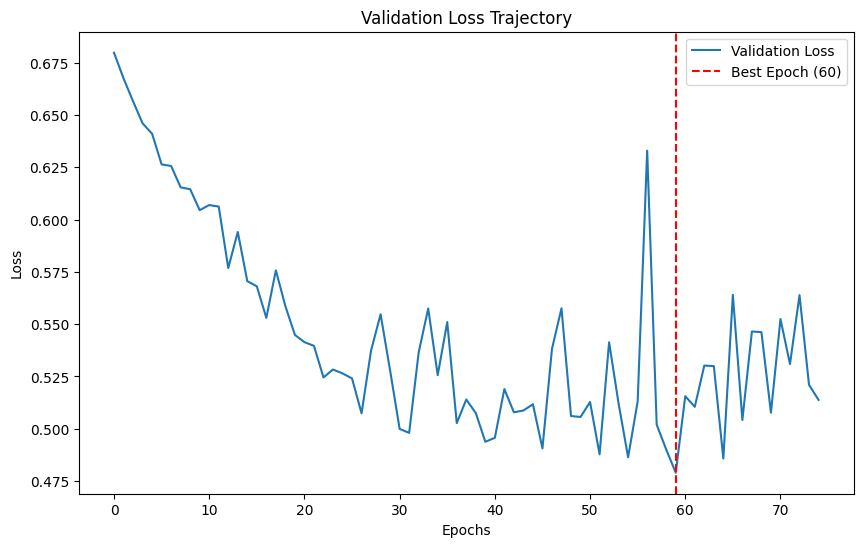

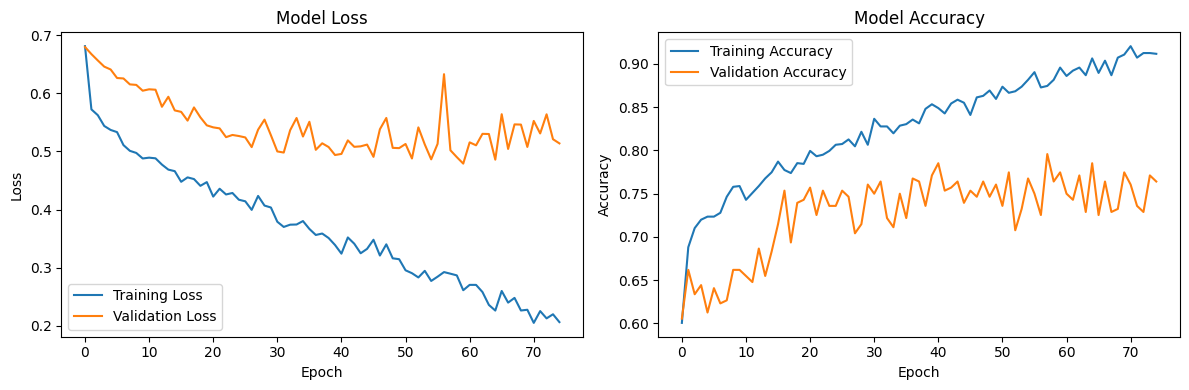


Final evaluation:
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7730 - auc: 0.8609 - loss: 0.4692 - precision: 0.7820 - recall: 0.8338
Metrics Dictionary: {'loss': 0.4699307382106781, 'compile_metrics': 0.780281662940979}
Manually calculated accuracy: 0.7803

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.70      0.73       149
           1       0.80      0.83      0.82       206

    accuracy                           0.78       355
   macro avg       0.78      0.77      0.77       355
weighted avg       0.78      0.78      0.78       355


Test Metrics Summary:
Test loss: 0.4699
Test compile_metrics: 0.7803
Test accuracy: 0.7803


In [8]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import os
# from tensorflow import keras


class EyebrowDeepfakeDetector:
    def __init__(self, model_type='lstm', input_shape=(56, 6), num_classes=1):
        self.model_type = model_type
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()
        self.scaler = StandardScaler()

    def _build_model(self):
        """Build and compile the model based on specified architecture type"""
        if self.model_type == 'lstm':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'gru':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'cnn':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling1D(2),
                tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.GlobalAveragePooling1D(),
                tf.keras.layers.Dense(64, activation='relu'),
                tf.keras.layers.Dropout(0.3),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'transformer':
            inputs = tf.keras.Input(shape=self.input_shape)
            pos_encoding = self._positional_encoding(self.input_shape[0], self.input_shape[1])
            x = inputs + pos_encoding[:, :self.input_shape[0], :]
            
            # Transformer block
            x = tf.keras.layers.MultiHeadAttention(
                num_heads=4, key_dim=self.input_shape[1])(x, x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Feed forward network
            x = tf.keras.layers.Dense(128, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Classification head
            x = tf.keras.layers.GlobalAveragePooling1D()(x)
            x = tf.keras.layers.Dense(64, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.2)(x)
            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
            
            model = tf.keras.Model(inputs=inputs, outputs=outputs)
            
        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
            
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss='binary_crossentropy',
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ]
        )
        return model

    def _positional_encoding(self, max_length=75, d_model=6):
        """Generate positional encoding for transformer"""
        positions = np.arange(max_length)[:, np.newaxis]
        depths = np.arange(d_model)[np.newaxis, :]/d_model
        
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.zeros(angle_rads.shape)
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        
        return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

    def load_data(self, csv_path):
        """Load and reshape eyebrow movement data"""
        df = pd.read_csv(csv_path, header=None)
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(np.int32)
        
        # Reshape to (samples, 75, 3)
        if X.shape[1] == 450:  # Verify input dimensions
            X = X.reshape(-1, 75, 6)
        return X, y

    def preprocess_data(self, X, y, test_size=0.2):
        """Standardize features and split data"""
        # Stratified train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=42)
        
        # Feature-wise standardization
        orig_shape = X_train.shape
        self.scaler.fit(X_train.reshape(-1, 6))
        X_train = self.scaler.transform(X_train.reshape(-1, 6)).reshape(orig_shape)
        X_test = self.scaler.transform(X_test.reshape(-1, 6)).reshape(X_test.shape)
        
        return X_train, X_test, y_train, y_test

    def train(self, X_train, y_train, X_val, y_val, epochs=100):
        """Train model with early stopping and checkpointing"""
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(
                f'best_{self.model_type}_model.keras', save_best_only=True)
        ]
        
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=64,
            callbacks=callbacks,
            verbose=2
        )

        # Print final training metrics
        print("\nFinal Training Metrics:")
        for metric in history.history:
            if not metric.startswith('val_'):
                print(f"Training {metric}: {history.history[metric][-1]:.4f}")
        
        # Print final validation metrics
        print("\nFinal Validation Metrics:")
        for metric in history.history:
            if metric.startswith('val_'):
                print(f"{metric}: {history.history[metric][-1]:.4f}")

                # Analyze stopping reason
        best_epoch = np.argmin(history.history['val_loss']) + 1
        print(f"Best model found at epoch {best_epoch}")

        # Plot validation metrics trajectory
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.axvline(x=best_epoch-1, color='r', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
        plt.title('Validation Loss Trajectory')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        return history

    def evaluate(self, X_test, y_test):
        """Comprehensive model evaluation"""
        # Quantitative metrics
        results = self.model.evaluate(X_test, y_test, verbose=1)
        metrics = dict(zip(self.model.metrics_names, results))
        
        # Debug: Print the metrics dictionary
        print("Metrics Dictionary:", metrics)
        
        # Qualitative analysis
        y_pred_prob = self.model.predict(X_test,verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        # Calculate and print accuracy directly
        from sklearn.metrics import accuracy_score
        calc_accuracy = accuracy_score(y_test, y_pred)
        print(f"Manually calculated accuracy: {calc_accuracy:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        plt.xticks([0, 1], ['Real', 'Fake'])
        plt.yticks([0, 1], ['Real', 'Fake'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(f'{self.model_type}_confusion_matrix.png')
        plt.close()
        
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.savefig(f'{self.model_type}_roc_curve.png')
        plt.close()
        
        # Ensure accuracy is in the metrics dictionary
        if 'accuracy' not in metrics:
            metrics['accuracy'] = calc_accuracy
        
        return metrics


# Usage example
if __name__ == "__main__":
    # Initialize detector - choose model type
    detector = EyebrowDeepfakeDetector(model_type='cnn', input_shape=(75, 6))
    
    # Load and preprocess data
    X, y = detector.load_data(os.path.join("","eyeblink_dataset-DeepFakeDetection.csv"))
    X_train, X_test, y_train, y_test = detector.preprocess_data(X, y)
    
    # Split validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # Train model
    print("Model architecture:")
    detector.model.summary()
    history = detector.train(X_train, y_train, X_val, y_val)
    
        # Plot training history
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{detector.model_type}_training_history.png')
    plt.show()
    plt.close('all')

    # Evaluate
    print("\nFinal evaluation:")
    test_metrics = detector.evaluate(X_test, y_test)

        # Print all metrics in a formatted way
    print("\nTest Metrics Summary:")
    for metric_name, metric_value in test_metrics.items():
        print(f"Test {metric_name}: {metric_value:.4f}")

    # Save final model
    detector.model.save(f'final_{detector.model_type}_model.keras')


Model architecture:


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_23 (Conv1D)              │ (None, 75, 64)         │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 75, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_15 (MaxPooling1D) │ (None, 37, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_24 (Conv1D)              │ (None, 37, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 37, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_8      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,009 (136.75 KB)

 Trainable params: 34,625 (135.25 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
15/15 - 3s - 214ms/step - accuracy: 0.4847 - auc: 0.4930 - loss: 0.7694 - precision: 0.4853 - recall: 0.4863 - val_accuracy: 0.5504 - val_auc: 0.5658 - val_loss: 0.6890 - val_precision: 0.7308 - val_recall: 0.1597
Epoch 2/100
15/15 - 0s - 23ms/step - accuracy: 0.5753 - auc: 0.6085 - loss: 0.6920 - precision: 0.5669 - recall: 0.6421 - val_accuracy: 0.5672 - val_auc: 0.5829 - val_loss: 0.6888 - val_precision: 0.7222 - val_recall: 0.2185
Epoch 3/100
15/15 - 0s - 24ms/step - accuracy: 0.5827 - auc: 0.6112 - loss: 0.6824 - precision: 0.5801 - recall: 0.6021 - val_accuracy: 0.5546 - val_auc: 0.5876 - val_loss: 0.6848 - val_precision: 0.5890 - val_recall: 0.3613
Epoch 4/100
15/15 - 0s - 20ms/step - accuracy: 0.5880 - auc: 0.6115 - loss: 0.6793 - precision: 0.5871 - recall: 0.5958 - val_accuracy: 0.5462 - val_auc: 0.5763 - val_loss: 0.6873 - val_precision: 0.5579 - val_recall: 0.4454
Epoch 5/100
15/15 - 0s - 23ms/step - accuracy: 0.5996 - auc: 0.6419 - loss: 0.6619 - precision: 0.5

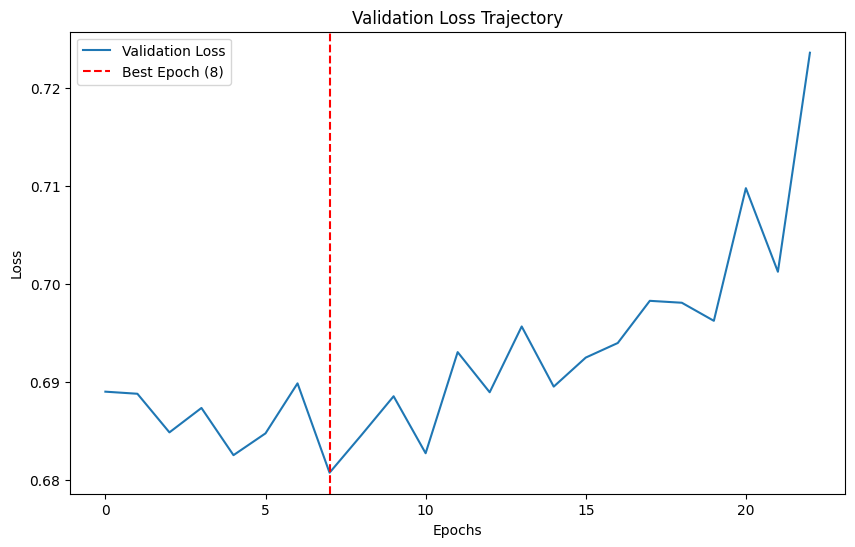

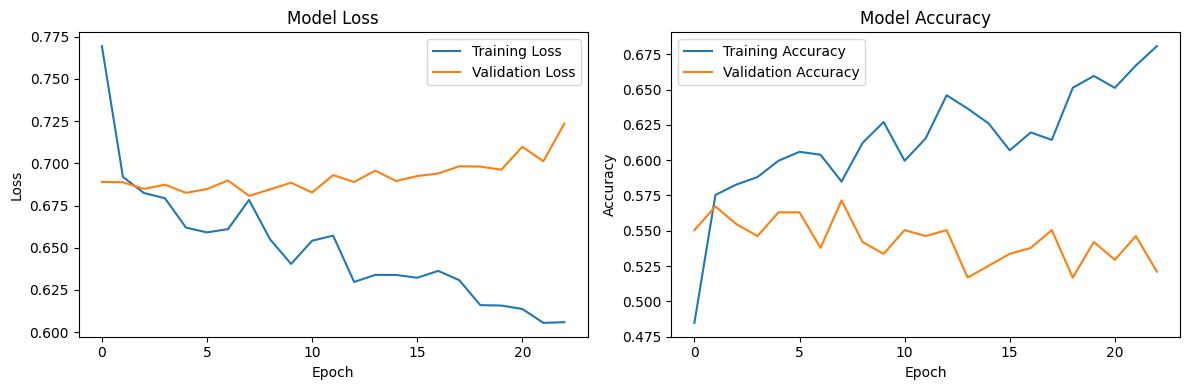


Final evaluation:
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5272 - auc: 0.5529 - loss: 0.6827 - precision: 0.4858 - recall: 0.5589 
Metrics Dictionary: {'loss': 0.6804852485656738, 'compile_metrics': 0.5353535413742065}
Manually calculated accuracy: 0.5354

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.52      0.53       149
           1       0.53      0.55      0.54       148

    accuracy                           0.54       297
   macro avg       0.54      0.54      0.54       297
weighted avg       0.54      0.54      0.54       297


Test Metrics Summary:
Test loss: 0.6805
Test compile_metrics: 0.5354
Test accuracy: 0.5354


In [21]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import os
from tensorflow import keras


class EyebrowDeepfakeDetector:
    def __init__(self, model_type='lstm', input_shape=(75, 6), num_classes=1):
        self.model_type = model_type
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()
        self.scaler = StandardScaler()

    def _build_model(self):
        """Build and compile the model based on specified architecture type"""
        if self.model_type == 'lstm':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'gru':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'cnn':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling1D(2),
                tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.GlobalAveragePooling1D(),
                tf.keras.layers.Dense(64, activation='relu'),
                tf.keras.layers.Dropout(0.3),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'transformer':
            inputs = tf.keras.Input(shape=self.input_shape)
            pos_encoding = self._positional_encoding(self.input_shape[0], self.input_shape[1])
            x = inputs + pos_encoding[:, :self.input_shape[0], :]
            
            # Transformer block
            x = tf.keras.layers.MultiHeadAttention(
                num_heads=4, key_dim=self.input_shape[1])(x, x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Feed forward network
            x = tf.keras.layers.Dense(128, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Classification head
            x = tf.keras.layers.GlobalAveragePooling1D()(x)
            x = tf.keras.layers.Dense(64, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.2)(x)
            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
            
            model = tf.keras.Model(inputs=inputs, outputs=outputs)
        elif self.model_type=="model-1":
            inputs = tf.keras.Input(shape=(75,6,1))
    
            # Spatial Feature Extraction
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'))(inputs)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)
            
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)
            
            # Temporal Processing
            x = tf.keras.layers.LSTM(256, return_sequences=True)(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.LSTM(128)(x)
            x = tf.keras.layers.Dropout(0.2)(x)
            
            # Classification
            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
            
            model = tf.keras.models.Model(inputs=inputs, outputs=outputs)
        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
            
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss='binary_crossentropy',
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ]
        )
        return model

    def _positional_encoding(self, max_length=75, d_model=6):
        """Generate positional encoding for transformer"""
        positions = np.arange(max_length)[:, np.newaxis]
        depths = np.arange(d_model)[np.newaxis, :]/d_model
        
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.zeros(angle_rads.shape)
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        
        return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

    def load_data(self, csv_path):
        """Load and reshape eyebrow movement data"""
        df = pd.read_csv(csv_path, header=None)
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(np.int32)
        
        # Reshape to (samples, 75, 3)
        if X.shape[1] == 450:  # Verify input dimensions
            X = X.reshape(-1, 75, 6)
        return X, y

    def preprocess_data(self, X, y, test_size=0.2):
        """Standardize features and split data"""
        # Stratified train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=42)
        
        # Feature-wise standardization
        orig_shape = X_train.shape
        self.scaler.fit(X_train.reshape(-1, 6))
        X_train = self.scaler.transform(X_train.reshape(-1, 6)).reshape(orig_shape)
        X_test = self.scaler.transform(X_test.reshape(-1, 6)).reshape(X_test.shape)
        
        return X_train, X_test, y_train, y_test

    def train(self, X_train, y_train, X_val, y_val, epochs=100):
        """Train model with early stopping and checkpointing"""
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(
                f'best_{self.model_type}_model.keras', save_best_only=True)
        ]
        
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=64,
            callbacks=callbacks,
            verbose=2
        )

        # Print final training metrics
        print("\nFinal Training Metrics:")
        for metric in history.history:
            if not metric.startswith('val_'):
                print(f"Training {metric}: {history.history[metric][-1]:.4f}")
        
        # Print final validation metrics
        print("\nFinal Validation Metrics:")
        for metric in history.history:
            if metric.startswith('val_'):
                print(f"{metric}: {history.history[metric][-1]:.4f}")

                # Analyze stopping reason
        best_epoch = np.argmin(history.history['val_loss']) + 1
        print(f"Best model found at epoch {best_epoch}")

        # Plot validation metrics trajectory
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.axvline(x=best_epoch-1, color='r', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
        plt.title('Validation Loss Trajectory')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        return history

    def evaluate(self, X_test, y_test):
        """Comprehensive model evaluation"""
        # Quantitative metrics
        results = self.model.evaluate(X_test, y_test, verbose=1)
        metrics = dict(zip(self.model.metrics_names, results))
        
        # Debug: Print the metrics dictionary
        print("Metrics Dictionary:", metrics)
        
        # Qualitative analysis
        y_pred_prob = self.model.predict(X_test,verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        # Calculate and print accuracy directly
        from sklearn.metrics import accuracy_score
        calc_accuracy = accuracy_score(y_test, y_pred)
        print(f"Manually calculated accuracy: {calc_accuracy:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        plt.xticks([0, 1], ['Real', 'Fake'])
        plt.yticks([0, 1], ['Real', 'Fake'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(f'{self.model_type}_confusion_matrix.png')
        plt.close()
        
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.savefig(f'{self.model_type}_roc_curve.png')
        plt.close()
        
        # Ensure accuracy is in the metrics dictionary
        if 'accuracy' not in metrics:
            metrics['accuracy'] = calc_accuracy
        
        return metrics


# Usage example
if __name__ == "__main__":
    # Initialize detector - choose model type
    detector = EyebrowDeepfakeDetector(model_type='cnn', input_shape=(75, 6))
    
    # Load and preprocess data
    X, y = detector.load_data(os.path.join("","eyeblink_dataset-Face2Face.csv"))
    X_train, X_test, y_train, y_test = detector.preprocess_data(X, y)
    
    # Split validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # Train model
    print("Model architecture:")
    detector.model.summary()
    history = detector.train(X_train, y_train, X_val, y_val)
    
        # Plot training history
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{detector.model_type}_training_history.png')
    plt.show()
    plt.close('all')

    # Evaluate
    print("\nFinal evaluation:")
    test_metrics = detector.evaluate(X_test, y_test)

        # Print all metrics in a formatted way
    print("\nTest Metrics Summary:")
    for metric_name, metric_value in test_metrics.items():
        print(f"Test {metric_name}: {metric_value:.4f}")

    # Save final model
    detector.model.save(f'final_{detector.model_type}_model.keras')


Model architecture:


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_25 (Conv1D)              │ (None, 75, 64)         │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 75, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_16 (MaxPooling1D) │ (None, 37, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_26 (Conv1D)              │ (None, 37, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_49          │ (None, 37, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_9      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,009 (136.75 KB)

 Trainable params: 34,625 (135.25 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
14/14 - 8s - 580ms/step - accuracy: 0.5287 - auc: 0.5259 - loss: 0.7482 - precision: 0.4698 - recall: 0.4723 - val_accuracy: 0.5561 - val_auc: 0.5050 - val_loss: 0.6868 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/100
14/14 - 1s - 65ms/step - accuracy: 0.5569 - auc: 0.5771 - loss: 0.6942 - precision: 0.5013 - recall: 0.4960 - val_accuracy: 0.5654 - val_auc: 0.5462 - val_loss: 0.6850 - val_precision: 1.0000 - val_recall: 0.0211
Epoch 3/100
14/14 - 1s - 65ms/step - accuracy: 0.5885 - auc: 0.6194 - loss: 0.6737 - precision: 0.5398 - recall: 0.5013 - val_accuracy: 0.5561 - val_auc: 0.5600 - val_loss: 0.6836 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/100
14/14 - 1s - 66ms/step - accuracy: 0.5979 - auc: 0.6289 - loss: 0.6628 - precision: 0.5536 - recall: 0.4908 - val_accuracy: 0.5514 - val_auc: 0.5857 - val_loss: 0.6803 - val_precision: 0.4884 - val_recall: 0.2211
Epoch 5/100
14/14 - 1s - 57ms/step - accuracy: 0.5862 - auc: 0.6173 - loss: 0.6713 

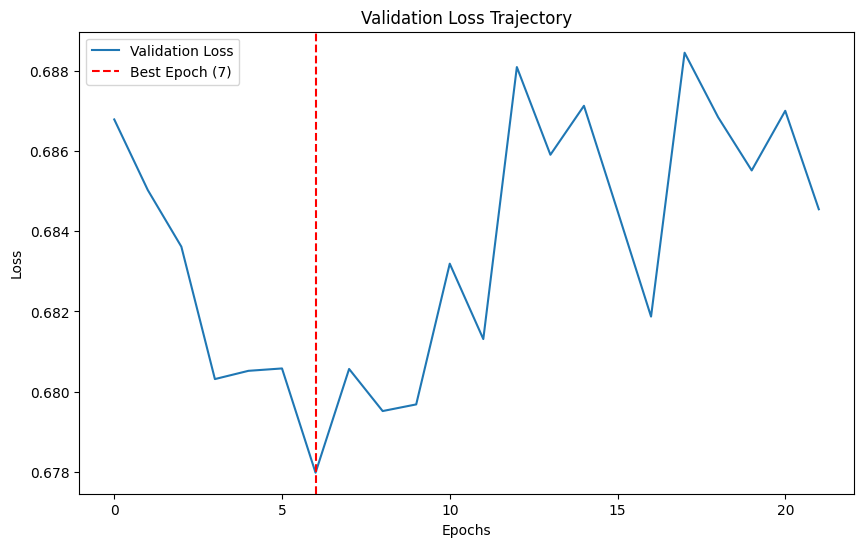

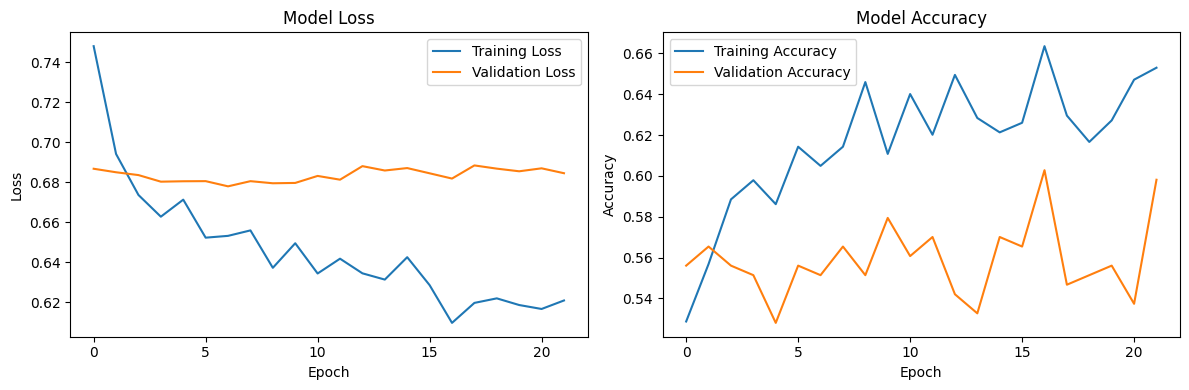


Final evaluation:
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5799 - auc: 0.5970 - loss: 0.6756 - precision: 0.5029 - recall: 0.3459
Metrics Dictionary: {'loss': 0.682365894317627, 'compile_metrics': 0.5393258333206177}
Manually calculated accuracy: 0.5393

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.73      0.64       149
           1       0.47      0.30      0.36       118

    accuracy                           0.54       267
   macro avg       0.52      0.51      0.50       267
weighted avg       0.52      0.54      0.52       267


Test Metrics Summary:
Test loss: 0.6824
Test compile_metrics: 0.5393
Test accuracy: 0.5393


In [23]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import os
from tensorflow import keras


class EyebrowDeepfakeDetector:
    def __init__(self, model_type='lstm', input_shape=(75, 6), num_classes=1):
        self.model_type = model_type
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()
        self.scaler = StandardScaler()

    def _build_model(self):
        """Build and compile the model based on specified architecture type"""
        if self.model_type == 'lstm':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'gru':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'cnn':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling1D(2),
                tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.GlobalAveragePooling1D(),
                tf.keras.layers.Dense(64, activation='relu'),
                tf.keras.layers.Dropout(0.3),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'transformer':
            inputs = tf.keras.Input(shape=self.input_shape)
            pos_encoding = self._positional_encoding(self.input_shape[0], self.input_shape[1])
            x = inputs + pos_encoding[:, :self.input_shape[0], :]
            
            # Transformer block
            x = tf.keras.layers.MultiHeadAttention(
                num_heads=4, key_dim=self.input_shape[1])(x, x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Feed forward network
            x = tf.keras.layers.Dense(128, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Classification head
            x = tf.keras.layers.GlobalAveragePooling1D()(x)
            x = tf.keras.layers.Dense(64, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.2)(x)
            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
            
            model = tf.keras.Model(inputs=inputs, outputs=outputs)
        elif self.model_type=="model-1":
            inputs = tf.keras.Input(shape=(75,6,1))
    
            # Spatial Feature Extraction
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'))(inputs)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)
            
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)
            
            # Temporal Processing
            x = tf.keras.layers.LSTM(256, return_sequences=True)(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.LSTM(128)(x)
            x = tf.keras.layers.Dropout(0.2)(x)
            
            # Classification
            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
            
            model = tf.keras.models.Model(inputs=inputs, outputs=outputs)
        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
            
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss='binary_crossentropy',
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ]
        )
        return model

    def _positional_encoding(self, max_length=75, d_model=6):
        """Generate positional encoding for transformer"""
        positions = np.arange(max_length)[:, np.newaxis]
        depths = np.arange(d_model)[np.newaxis, :]/d_model
        
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.zeros(angle_rads.shape)
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        
        return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

    def load_data(self, csv_path):
        """Load and reshape eyebrow movement data"""
        df = pd.read_csv(csv_path, header=None)
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(np.int32)
        
        # Reshape to (samples, 75, 3)
        if X.shape[1] == 450:  # Verify input dimensions
            X = X.reshape(-1, 75, 6)
        return X, y

    def preprocess_data(self, X, y, test_size=0.2):
        """Standardize features and split data"""
        # Stratified train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=42)
        
        # Feature-wise standardization
        orig_shape = X_train.shape
        self.scaler.fit(X_train.reshape(-1, 6))
        X_train = self.scaler.transform(X_train.reshape(-1, 6)).reshape(orig_shape)
        X_test = self.scaler.transform(X_test.reshape(-1, 6)).reshape(X_test.shape)
        
        return X_train, X_test, y_train, y_test

    def train(self, X_train, y_train, X_val, y_val, epochs=100):
        """Train model with early stopping and checkpointing"""
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(
                f'best_{self.model_type}_model.keras', save_best_only=True)
        ]
        
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=64,
            callbacks=callbacks,
            verbose=2
        )

        # Print final training metrics
        print("\nFinal Training Metrics:")
        for metric in history.history:
            if not metric.startswith('val_'):
                print(f"Training {metric}: {history.history[metric][-1]:.4f}")
        
        # Print final validation metrics
        print("\nFinal Validation Metrics:")
        for metric in history.history:
            if metric.startswith('val_'):
                print(f"{metric}: {history.history[metric][-1]:.4f}")

                # Analyze stopping reason
        best_epoch = np.argmin(history.history['val_loss']) + 1
        print(f"Best model found at epoch {best_epoch}")

        # Plot validation metrics trajectory
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.axvline(x=best_epoch-1, color='r', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
        plt.title('Validation Loss Trajectory')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        return history

    def evaluate(self, X_test, y_test):
        """Comprehensive model evaluation"""
        # Quantitative metrics
        results = self.model.evaluate(X_test, y_test, verbose=1)
        metrics = dict(zip(self.model.metrics_names, results))
        
        # Debug: Print the metrics dictionary
        print("Metrics Dictionary:", metrics)
        
        # Qualitative analysis
        y_pred_prob = self.model.predict(X_test,verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        # Calculate and print accuracy directly
        from sklearn.metrics import accuracy_score
        calc_accuracy = accuracy_score(y_test, y_pred)
        print(f"Manually calculated accuracy: {calc_accuracy:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        plt.xticks([0, 1], ['Real', 'Fake'])
        plt.yticks([0, 1], ['Real', 'Fake'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(f'{self.model_type}_confusion_matrix.png')
        plt.close()
        
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.savefig(f'{self.model_type}_roc_curve.png')
        plt.close()
        
        # Ensure accuracy is in the metrics dictionary
        if 'accuracy' not in metrics:
            metrics['accuracy'] = calc_accuracy
        
        return metrics


# Usage example
if __name__ == "__main__":
    # Initialize detector - choose model type
    detector = EyebrowDeepfakeDetector(model_type='cnn', input_shape=(75, 6))
    
    # Load and preprocess data
    X, y = detector.load_data(os.path.join("","eyeblink_dataset-FaceSwap.csv"))
    X_train, X_test, y_train, y_test = detector.preprocess_data(X, y)
    
    # Split validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # Train model
    print("Model architecture:")
    detector.model.summary()
    history = detector.train(X_train, y_train, X_val, y_val)
    
        # Plot training history
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{detector.model_type}_training_history.png')
    plt.show()
    plt.close('all')

    # Evaluate
    print("\nFinal evaluation:")
    test_metrics = detector.evaluate(X_test, y_test)

        # Print all metrics in a formatted way
    print("\nTest Metrics Summary:")
    for metric_name, metric_value in test_metrics.items():
        print(f"Test {metric_name}: {metric_value:.4f}")

    # Save final model
    detector.model.save(f'final_{detector.model_type}_model.keras')



Model architecture:


Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_28      │ (None, 75, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 75, 6, 1)  │          0 │ input_layer_28[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_60 │ (None, 75, 6, 64) │        256 │ lambda[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_61 │ (None, 75, 6, 64) │        256 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_62 │ (None, 75, 3, 64) │          0 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_63 │ (None, 75, 3,     │     24,704 │ time_distributed… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_64 │ (None, 75, 3,     │        512 │ time_distributed… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_65 │ (None, 75, 1,     │          0 │ time_distributed… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_66 │ (None, 75, 128)   │          0 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 75, 128)   │        256 │ time_distributed… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 75, 128)   │    131,968 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_24          │ (None, 75, 128)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 75, 128)   │          0 │ dropout_24[0][0], │
│                     │                   │            │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 75, 128)   │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_40 (Dense)    │ (None, 75, 128)   │     16,512 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_25          │ (None, 75, 128)   │          0 │ dense_40[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_41 (Dense)    │ (None, 75, 128)   │     16,512 │ dropout_25[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 75, 128)   │          0 │ dense_41[0][0], 

 Total params: 381,569 (1.46 MB)

 Trainable params: 381,185 (1.45 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
18/18 - 87s - 5s/step - accuracy: 0.5477 - auc: 0.5509 - loss: 2.7476 - precision: 0.5981 - recall: 0.6763 - val_accuracy: 0.5704 - val_auc: 0.6527 - val_loss: 2.4931 - val_precision: 0.6287 - val_recall: 0.6364
Epoch 2/100
18/18 - 32s - 2s/step - accuracy: 0.6034 - auc: 0.6247 - loss: 2.3960 - precision: 0.6359 - recall: 0.7432 - val_accuracy: 0.6514 - val_auc: 0.6951 - val_loss: 2.2155 - val_precision: 0.6854 - val_recall: 0.7394
Epoch 3/100
18/18 - 14s - 787ms/step - accuracy: 0.5928 - auc: 0.6350 - loss: 2.1320 - precision: 0.6298 - recall: 0.7264 - val_accuracy: 0.6655 - val_auc: 0.6911 - val_loss: 1.9879 - val_precision: 0.6842 - val_recall: 0.7879
Epoch 4/100
18/18 - 14s - 804ms/step - accuracy: 0.6466 - auc: 0.6968 - loss: 1.8892 - precision: 0.6762 - recall: 0.7523 - val_accuracy: 0.6585 - val_auc: 0.7254 - val_loss: 1.7648 - val_precision: 0.6809 - val_recall: 0.7758
Epoch 5/100
18/18 - 15s - 825ms/step - accuracy: 0.6413 - auc: 0.7095 - loss: 1.6887 - precision: 

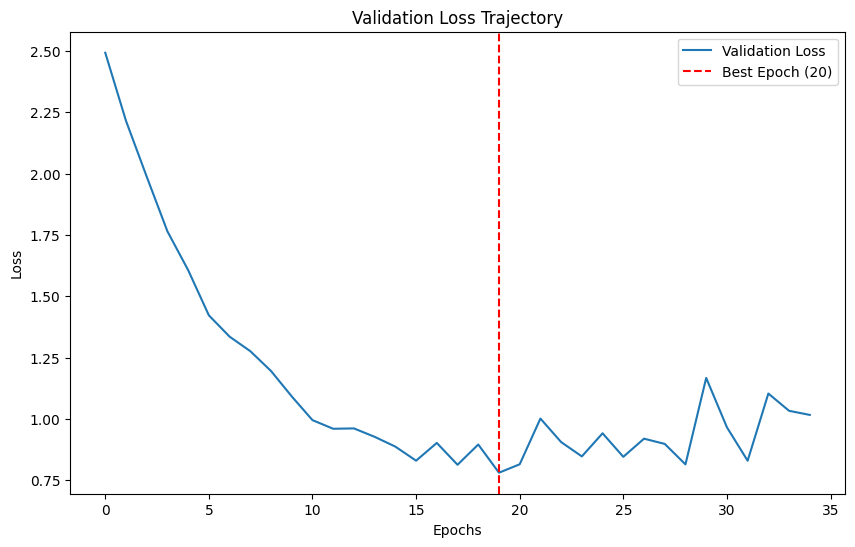

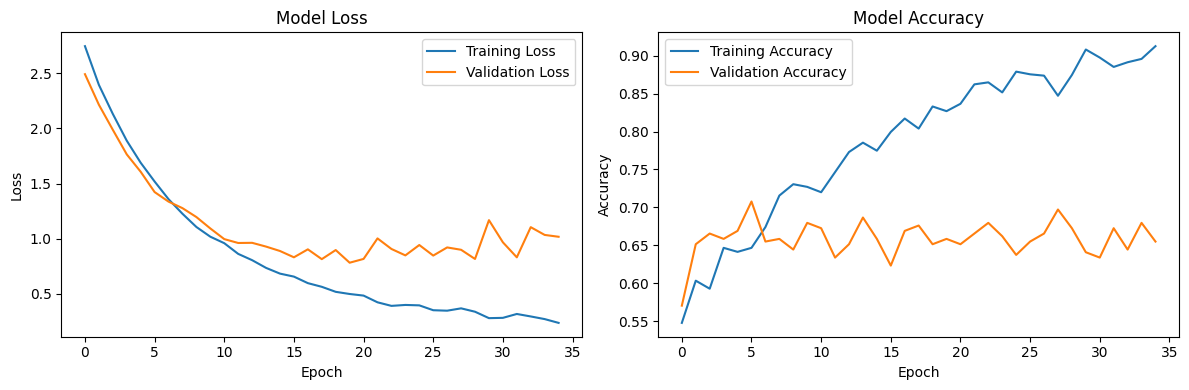


Final evaluation:
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.6742 - auc: 0.7397 - loss: 0.8605 - precision: 0.7415 - recall: 0.6555
Metrics Dictionary: {'loss': 0.81276535987854, 'compile_metrics': 0.6845070719718933}
Manually calculated accuracy: 0.6845

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.68      0.64       149
           1       0.75      0.69      0.72       206

    accuracy                           0.68       355
   macro avg       0.68      0.68      0.68       355
weighted avg       0.69      0.68      0.69       355


Test Metrics Summary:
Test loss: 0.8128
Test compile_metrics: 0.6845
Test accuracy: 0.6845


In [29]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import os
from tensorflow import keras


class EyebrowDeepfakeDetector:
    def __init__(self, model_type='lstm', input_shape=(75, 6), num_classes=1):
        self.model_type = model_type
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()
        self.scaler = StandardScaler()

    def _build_model(self):
        """Build and compile the model based on specified architecture type"""
        if self.model_type == 'lstm':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'gru':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'cnn':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling1D(2),
                tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.GlobalAveragePooling1D(),
                tf.keras.layers.Dense(64, activation='relu'),
                tf.keras.layers.Dropout(0.3),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'transformer':
            inputs = tf.keras.Input(shape=self.input_shape)
            pos_encoding = self._positional_encoding(self.input_shape[0], self.input_shape[1])
            x = inputs + pos_encoding[:, :self.input_shape[0], :]
            
            # Transformer block
            x = tf.keras.layers.MultiHeadAttention(
                num_heads=4, key_dim=self.input_shape[1])(x, x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Feed forward network
            x = tf.keras.layers.Dense(128, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Classification head
            x = tf.keras.layers.GlobalAveragePooling1D()(x)
            x = tf.keras.layers.Dense(64, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.2)(x)
            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
            
            model = tf.keras.Model(inputs=inputs, outputs=outputs)
        elif self.model_type=="model-1":
            inputs = tf.keras.Input(shape=(75,6,1))
    
            # Spatial Feature Extraction
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'))(inputs)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)
            
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)
            
            # Temporal Processing
            x = tf.keras.layers.LSTM(256, return_sequences=True)(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.LSTM(128)(x)
            x = tf.keras.layers.Dropout(0.2)(x)
            
            # Classification
            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
            
            model = tf.keras.models.Model(inputs=inputs, outputs=outputs)
        elif self.model_type=="model-2":
            inputs = tf.keras.Input(shape=self.input_shape)  # (75,6)

            # Expand dims if needed
            x = tf.keras.layers.Lambda(lambda x: tf.expand_dims(x, axis=-1))(inputs) # (75,6,1)

            # --- CNN Feature Extraction ---
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)

            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)

            # Flatten across spatial dimensions
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)  # shape: (75, features)

            # --- Transformer Encoder ---
            def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
                # Normalization and Attention
                x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(inputs)
                x = tf.keras.layers.MultiHeadAttention(
                    key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
                x = tf.keras.layers.Dropout(dropout)(x)
                res = x + inputs

                # Feed Forward
                x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(res)
                x = tf.keras.layers.Dense(ff_dim, activation='relu')(x)
                x = tf.keras.layers.Dropout(dropout)(x)
                x = tf.keras.layers.Dense(inputs.shape[-1])(x)
                return x + res

            # Apply Transformer Blocks
            x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)
            x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)

            x = tf.keras.layers.GlobalAveragePooling1D()(x)

            # --- Classification Head ---
            x = tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
            x = tf.keras.layers.Dropout(0.2)(x)

            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

            model = tf.keras.models.Model(inputs, outputs)

        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
            
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss='binary_crossentropy',
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ]
        )
        return model

    def _positional_encoding(self, max_length=75, d_model=6):
        """Generate positional encoding for transformer"""
        positions = np.arange(max_length)[:, np.newaxis]
        depths = np.arange(d_model)[np.newaxis, :]/d_model
        
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.zeros(angle_rads.shape)
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        
        return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

    def load_data(self, csv_path):
        """Load and reshape eyebrow movement data"""
        df = pd.read_csv(csv_path, header=None)
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(np.int32)
        
        # Reshape to (samples, 75, 3)
        if X.shape[1] == 450:  # Verify input dimensions
            X = X.reshape(-1, 75, 6)
        return X, y

    def preprocess_data(self, X, y, test_size=0.2):
        """Standardize features and split data"""
        # Stratified train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=42)
        
        # Feature-wise standardization
        orig_shape = X_train.shape
        self.scaler.fit(X_train.reshape(-1, 6))
        X_train = self.scaler.transform(X_train.reshape(-1, 6)).reshape(orig_shape)
        X_test = self.scaler.transform(X_test.reshape(-1, 6)).reshape(X_test.shape)
        
        return X_train, X_test, y_train, y_test

    def train(self, X_train, y_train, X_val, y_val, epochs=100):
        """Train model with early stopping and checkpointing"""
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(
                f'best_{self.model_type}_model.keras', save_best_only=True)
        ]
        
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=64,
            callbacks=callbacks,
            verbose=2
        )

        # Print final training metrics
        print("\nFinal Training Metrics:")
        for metric in history.history:
            if not metric.startswith('val_'):
                print(f"Training {metric}: {history.history[metric][-1]:.4f}")
        
        # Print final validation metrics
        print("\nFinal Validation Metrics:")
        for metric in history.history:
            if metric.startswith('val_'):
                print(f"{metric}: {history.history[metric][-1]:.4f}")

                # Analyze stopping reason
        best_epoch = np.argmin(history.history['val_loss']) + 1
        print(f"Best model found at epoch {best_epoch}")

        # Plot validation metrics trajectory
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.axvline(x=best_epoch-1, color='r', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
        plt.title('Validation Loss Trajectory')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        return history

    def evaluate(self, X_test, y_test):
        """Comprehensive model evaluation"""
        # Quantitative metrics
        results = self.model.evaluate(X_test, y_test, verbose=1)
        metrics = dict(zip(self.model.metrics_names, results))
        
        # Debug: Print the metrics dictionary
        print("Metrics Dictionary:", metrics)
        
        # Qualitative analysis
        y_pred_prob = self.model.predict(X_test,verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        # Calculate and print accuracy directly
        from sklearn.metrics import accuracy_score
        calc_accuracy = accuracy_score(y_test, y_pred)
        print(f"Manually calculated accuracy: {calc_accuracy:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        plt.xticks([0, 1], ['Real', 'Fake'])
        plt.yticks([0, 1], ['Real', 'Fake'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(f'{self.model_type}_confusion_matrix.png')
        plt.close()
        
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.savefig(f'{self.model_type}_roc_curve.png')
        plt.close()
        
        # Ensure accuracy is in the metrics dictionary
        if 'accuracy' not in metrics:
            metrics['accuracy'] = calc_accuracy
        
        return metrics


# Usage example
if __name__ == "__main__":
    # Initialize detector - choose model type
    detector = EyebrowDeepfakeDetector(model_type='model-2', input_shape=(75, 6))
    
    # Load and preprocess data
    X, y = detector.load_data(os.path.join("","eyeblink_dataset-DeepFakeDetection.csv"))
    X_train, X_test, y_train, y_test = detector.preprocess_data(X, y)
    
    # Split validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # Train model
    print("Model architecture:")
    detector.model.summary()
    history = detector.train(X_train, y_train, X_val, y_val)
    
        # Plot training history
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{detector.model_type}_training_history.png')
    plt.show()
    plt.close('all')

    # Evaluate
    print("\nFinal evaluation:")
    test_metrics = detector.evaluate(X_test, y_test)

        # Print all metrics in a formatted way
    print("\nTest Metrics Summary:")
    for metric_name, metric_value in test_metrics.items():
        print(f"Test {metric_name}: {metric_value:.4f}")

    # Save final model
    detector.model.save(f'final_{detector.model_type}_model.keras')


Model architecture:


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 56, 7)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 56, 7, 1)  │          0 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_21 │ (None, 56, 7, 64) │        256 │ lambda_2[0][0]    │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_22 │ (None, 56, 7, 64) │        256 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_23 │ (None, 56, 3, 64) │          0 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_24 │ (None, 56, 3,     │     24,704 │ time_distributed… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_25 │ (None, 56, 3,     │        512 │ time_distributed… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_26 │ (None, 56, 1,     │          0 │ time_distributed… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_27 │ (None, 56, 128)   │          0 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 56, 128)   │        256 │ time_distributed… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 56, 128)   │    131,968 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 56, 128)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 56, 128)   │          0 │ dropout_19[0][0], │
│                     │                   │            │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 56, 128)   │        256 │ add_8[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 56, 128)   │     16,512 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_20          │ (None, 56, 128)   │          0 │ dense_15[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 56, 128)   │     16,512 │ dropout_20[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 56, 128)   │          0 │ dense_16[0][0], 

 Total params: 381,569 (1.46 MB)

 Trainable params: 381,185 (1.45 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
23/23 - 40s - 2s/step - accuracy: 0.5352 - auc: 0.5590 - loss: 2.7645 - precision: 0.5341 - recall: 0.5511 - val_accuracy: 0.6226 - val_auc: 0.6742 - val_loss: 2.4797 - val_precision: 0.5856 - val_recall: 0.8462
Epoch 2/100
23/23 - 8s - 353ms/step - accuracy: 0.5891 - auc: 0.6252 - loss: 2.3676 - precision: 0.5882 - recall: 0.5939 - val_accuracy: 0.6253 - val_auc: 0.6880 - val_loss: 2.1923 - val_precision: 0.6186 - val_recall: 0.6593
Epoch 3/100
23/23 - 10s - 417ms/step - accuracy: 0.5891 - auc: 0.6207 - loss: 2.1108 - precision: 0.5895 - recall: 0.5870 - val_accuracy: 0.6556 - val_auc: 0.7110 - val_loss: 1.9300 - val_precision: 0.6364 - val_recall: 0.7308
Epoch 4/100
23/23 - 9s - 400ms/step - accuracy: 0.5981 - auc: 0.6464 - loss: 1.8623 - precision: 0.5917 - recall: 0.6326 - val_accuracy: 0.6226 - val_auc: 0.7098 - val_loss: 1.7341 - val_precision: 0.6037 - val_recall: 0.7198
Epoch 5/100
23/23 - 8s - 349ms/step - accuracy: 0.6326 - auc: 0.6808 - loss: 1.6500 - precision: 

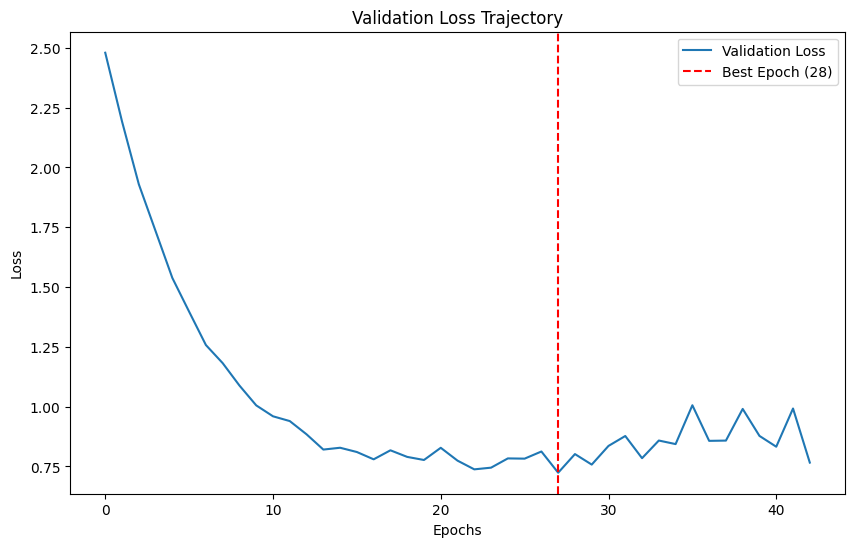

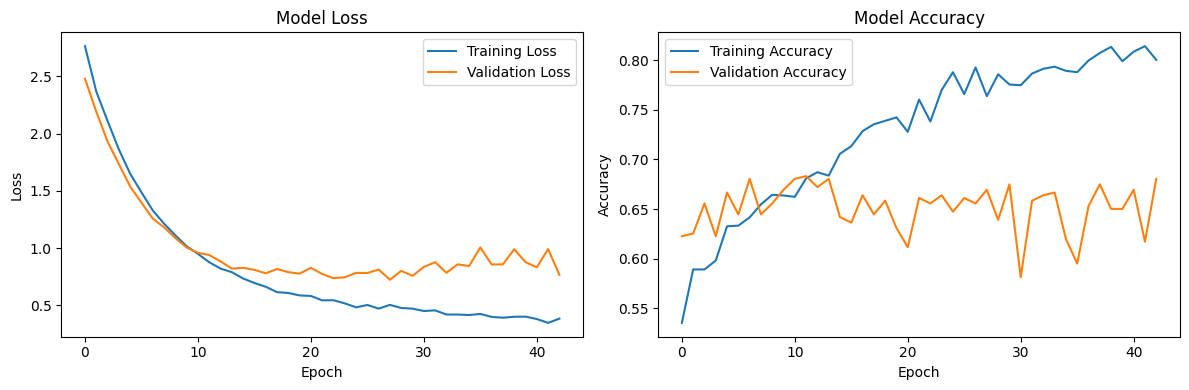


Final evaluation:
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6823 - auc: 0.7386 - loss: 0.7574 - precision: 0.6385 - recall: 0.8395
Metrics Dictionary: {'loss': 0.7751754522323608, 'compile_metrics': 0.6534216403961182}
Manually calculated accuracy: 0.6534

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.49      0.59       227
           1       0.62      0.81      0.70       226

    accuracy                           0.65       453
   macro avg       0.67      0.65      0.64       453
weighted avg       0.67      0.65      0.64       453


Test Metrics Summary:
Test loss: 0.7752
Test compile_metrics: 0.6534
Test accuracy: 0.6534


In [4]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import os
from tensorflow import keras


class EyebrowDeepfakeDetector:
    def __init__(self, model_type='lstm', input_shape=(56,7), num_classes=1):
        self.model_type = model_type
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()
        self.scaler = StandardScaler()

    def _build_model(self):
        """Build and compile the model based on specified architecture type"""
        if self.model_type == 'lstm':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'gru':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'cnn':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling1D(2),
                tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.GlobalAveragePooling1D(),
                tf.keras.layers.Dense(64, activation='relu'),
                tf.keras.layers.Dropout(0.3),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'transformer':
            inputs = tf.keras.Input(shape=self.input_shape)
            pos_encoding = self._positional_encoding(self.input_shape[0], self.input_shape[1])
            x = inputs + pos_encoding[:, :self.input_shape[0], :]
            
            # Transformer block
            x = tf.keras.layers.MultiHeadAttention(
                num_heads=4, key_dim=self.input_shape[1])(x, x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Feed forward network
            x = tf.keras.layers.Dense(128, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Classification head
            x = tf.keras.layers.GlobalAveragePooling1D()(x)
            x = tf.keras.layers.Dense(64, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.2)(x)
            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
            
            model = tf.keras.Model(inputs=inputs, outputs=outputs)
        elif self.model_type=="model-1":
            inputs = tf.keras.Input(shape=(56,7,1))
    
            # Spatial Feature Extraction
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'))(inputs)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)
            
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)
            
            # Temporal Processing
            x = tf.keras.layers.LSTM(256, return_sequences=True)(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.LSTM(128)(x)
            x = tf.keras.layers.Dropout(0.2)(x)
            
            # Classification
            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
            
            model = tf.keras.models.Model(inputs=inputs, outputs=outputs)
        elif self.model_type=="model-2":
            inputs = tf.keras.Input(shape=self.input_shape)  # (75,6)

            # Expand dims if needed
            x = tf.keras.layers.Lambda(lambda x: tf.expand_dims(x, axis=-1))(inputs) # (75,6,1)

            # --- CNN Feature Extraction ---
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)

            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)

            # Flatten across spatial dimensions
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)  # shape: (75, features)

            # --- Transformer Encoder ---
            def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
                # Normalization and Attention
                x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(inputs)
                x = tf.keras.layers.MultiHeadAttention(
                    key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
                x = tf.keras.layers.Dropout(dropout)(x)
                res = x + inputs

                # Feed Forward
                x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(res)
                x = tf.keras.layers.Dense(ff_dim, activation='relu')(x)
                x = tf.keras.layers.Dropout(dropout)(x)
                x = tf.keras.layers.Dense(inputs.shape[-1])(x)
                return x + res

            # Apply Transformer Blocks
            x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)
            x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)

            x = tf.keras.layers.GlobalAveragePooling1D()(x)

            # --- Classification Head ---
            x = tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
            x = tf.keras.layers.Dropout(0.2)(x)

            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

            model = tf.keras.models.Model(inputs, outputs)

        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
            
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss='binary_crossentropy',
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ]
        )
        return model

    def _positional_encoding(self, max_length=56, d_model=7):
        """Generate positional encoding for transformer"""
        positions = np.arange(max_length)[:, np.newaxis]
        depths = np.arange(d_model)[np.newaxis, :]/d_model
        
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.zeros(angle_rads.shape)
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        
        return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

    def load_data(self, csv_path):
        """Load and reshape eyebrow movement data"""
        df = pd.read_csv(csv_path, header=None)
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(np.int32)
        
        # Reshape to (samples, 75, 3)
        if X.shape[1] == 392:  # Verify input dimensions
            X = X.reshape(-1, 56, 7)
        return X, y

    def preprocess_data(self, X, y, test_size=0.2):
        """Standardize features and split data"""
        # Stratified train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=42)
        
        # Feature-wise standardization
        orig_shape = X_train.shape
        self.scaler.fit(X_train.reshape(-1, 7))
        X_train = self.scaler.transform(X_train.reshape(-1, 7)).reshape(orig_shape)
        X_test = self.scaler.transform(X_test.reshape(-1, 7)).reshape(X_test.shape)
        
        return X_train, X_test, y_train, y_test

    def train(self, X_train, y_train, X_val, y_val, epochs=100):
        """Train model with early stopping and checkpointing"""
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(
                f'best_{self.model_type}_model.keras', save_best_only=True)
        ]
        
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=64,
            callbacks=callbacks,
            verbose=2
        )

        # Print final training metrics
        print("\nFinal Training Metrics:")
        for metric in history.history:
            if not metric.startswith('val_'):
                print(f"Training {metric}: {history.history[metric][-1]:.4f}")
        
        # Print final validation metrics
        print("\nFinal Validation Metrics:")
        for metric in history.history:
            if metric.startswith('val_'):
                print(f"{metric}: {history.history[metric][-1]:.4f}")

                # Analyze stopping reason
        best_epoch = np.argmin(history.history['val_loss']) + 1
        print(f"Best model found at epoch {best_epoch}")

        # Plot validation metrics trajectory
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.axvline(x=best_epoch-1, color='r', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
        plt.title('Validation Loss Trajectory')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        return history

    def evaluate(self, X_test, y_test):
        """Comprehensive model evaluation"""
        # Quantitative metrics
        results = self.model.evaluate(X_test, y_test, verbose=1)
        metrics = dict(zip(self.model.metrics_names, results))
        
        # Debug: Print the metrics dictionary
        print("Metrics Dictionary:", metrics)
        
        # Qualitative analysis
        y_pred_prob = self.model.predict(X_test,verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        # Calculate and print accuracy directly
        from sklearn.metrics import accuracy_score
        calc_accuracy = accuracy_score(y_test, y_pred)
        print(f"Manually calculated accuracy: {calc_accuracy:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        plt.xticks([0, 1], ['Real', 'Fake'])
        plt.yticks([0, 1], ['Real', 'Fake'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(f'{self.model_type}_confusion_matrix.png')
        plt.close()
        
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.savefig(f'{self.model_type}_roc_curve.png')
        plt.close()
        
        # Ensure accuracy is in the metrics dictionary
        if 'accuracy' not in metrics:
            metrics['accuracy'] = calc_accuracy
        
        return metrics


# Usage example
if __name__ == "__main__":
    # Initialize detector - choose model type
    detector = EyebrowDeepfakeDetector(model_type='model-2', input_shape=(56, 7))
    
    # Load and preprocess data
    X, y = detector.load_data(os.path.join("","comprehensive_features-deepfake_new.csv"))
    X_train, X_test, y_train, y_test = detector.preprocess_data(X, y)
    
    # Split validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # Train model
    print("Model architecture:")
    detector.model.summary()
    history = detector.train(X_train, y_train, X_val, y_val)
    
        # Plot training history
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{detector.model_type}_training_history.png')
    plt.show()
    plt.close('all')

    # Evaluate
    print("\nFinal evaluation:")
    test_metrics = detector.evaluate(X_test, y_test)

        # Print all metrics in a formatted way
    print("\nTest Metrics Summary:")
    for metric_name, metric_value in test_metrics.items():
        print(f"Test {metric_name}: {metric_value:.4f}")

    # Save final model
    detector.model.save(f'final_{detector.model_type}_model.keras')


Model architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 56, 64)         │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 56, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 28, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 28, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 28, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,201 (137.50 KB)

 Trainable params: 34,817 (136.00 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
23/23 - 3s - 121ms/step - accuracy: 0.5559 - auc: 0.5849 - loss: 0.7261 - precision: 0.5524 - recall: 0.5898 - val_accuracy: 0.6226 - val_auc: 0.6686 - val_loss: 0.6731 - val_precision: 0.5926 - val_recall: 0.7912
Epoch 2/100
23/23 - 0s - 14ms/step - accuracy: 0.6091 - auc: 0.6601 - loss: 0.6647 - precision: 0.6082 - recall: 0.6133 - val_accuracy: 0.6198 - val_auc: 0.6741 - val_loss: 0.6758 - val_precision: 0.5809 - val_recall: 0.8681
Epoch 3/100
23/23 - 0s - 15ms/step - accuracy: 0.6195 - auc: 0.6503 - loss: 0.6735 - precision: 0.5982 - recall: 0.7279 - val_accuracy: 0.6584 - val_auc: 0.7189 - val_loss: 0.6701 - val_precision: 0.6593 - val_recall: 0.6593
Epoch 4/100
23/23 - 0s - 16ms/step - accuracy: 0.6153 - auc: 0.6645 - loss: 0.6511 - precision: 0.6097 - recall: 0.6409 - val_accuracy: 0.6474 - val_auc: 0.7132 - val_loss: 0.6672 - val_precision: 0.6063 - val_recall: 0.8462
Epoch 5/100
23/23 - 0s - 15ms/step - accuracy: 0.6236 - auc: 0.6842 - loss: 0.6366 - precision: 0.6

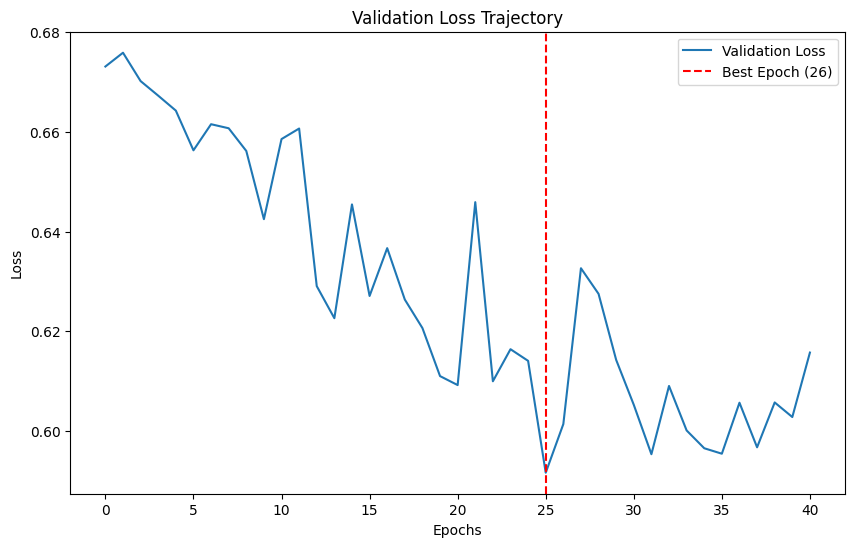

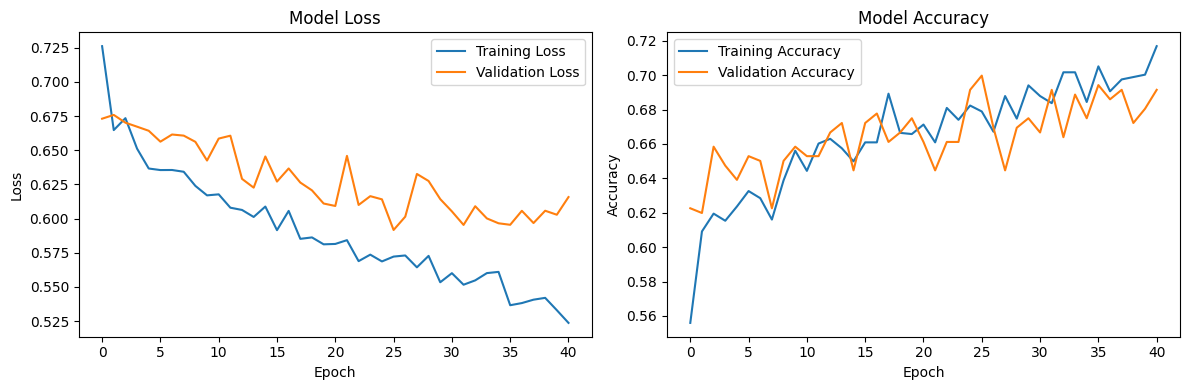


Final evaluation:
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6358 - auc: 0.7041 - loss: 0.6523 - precision: 0.6015 - recall: 0.8093
Metrics Dictionary: {'loss': 0.6588393449783325, 'compile_metrics': 0.6357616186141968}
Manually calculated accuracy: 0.6358

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.46      0.56       227
           1       0.60      0.81      0.69       226

    accuracy                           0.64       453
   macro avg       0.65      0.64      0.62       453
weighted avg       0.65      0.64      0.62       453


Test Metrics Summary:
Test loss: 0.6588
Test compile_metrics: 0.6358
Test accuracy: 0.6358


In [5]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import os
from tensorflow import keras


class EyebrowDeepfakeDetector:
    def __init__(self, model_type='lstm', input_shape=(56,7), num_classes=1):
        self.model_type = model_type
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()
        self.scaler = StandardScaler()

    def _build_model(self):
        """Build and compile the model based on specified architecture type"""
        if self.model_type == 'lstm':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'gru':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'cnn':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling1D(2),
                tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.GlobalAveragePooling1D(),
                tf.keras.layers.Dense(64, activation='relu'),
                tf.keras.layers.Dropout(0.3),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'transformer':
            inputs = tf.keras.Input(shape=self.input_shape)
            pos_encoding = self._positional_encoding(self.input_shape[0], self.input_shape[1])
            x = inputs + pos_encoding[:, :self.input_shape[0], :]
            
            # Transformer block
            x = tf.keras.layers.MultiHeadAttention(
                num_heads=4, key_dim=self.input_shape[1])(x, x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Feed forward network
            x = tf.keras.layers.Dense(128, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Classification head
            x = tf.keras.layers.GlobalAveragePooling1D()(x)
            x = tf.keras.layers.Dense(64, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.2)(x)
            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
            
            model = tf.keras.Model(inputs=inputs, outputs=outputs)
        elif self.model_type=="model-1":
            inputs = tf.keras.Input(shape=(56,7,1))
    
            # Spatial Feature Extraction
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'))(inputs)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)
            
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)
            
            # Temporal Processing
            x = tf.keras.layers.LSTM(256, return_sequences=True)(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.LSTM(128)(x)
            x = tf.keras.layers.Dropout(0.2)(x)
            
            # Classification
            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
            
            model = tf.keras.models.Model(inputs=inputs, outputs=outputs)
        elif self.model_type=="model-2":
            inputs = tf.keras.Input(shape=self.input_shape)  # (75,6)

            # Expand dims if needed
            x = tf.keras.layers.Lambda(lambda x: tf.expand_dims(x, axis=-1))(inputs) # (75,6,1)

            # --- CNN Feature Extraction ---
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)

            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)

            # Flatten across spatial dimensions
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)  # shape: (75, features)

            # --- Transformer Encoder ---
            def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
                # Normalization and Attention
                x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(inputs)
                x = tf.keras.layers.MultiHeadAttention(
                    key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
                x = tf.keras.layers.Dropout(dropout)(x)
                res = x + inputs

                # Feed Forward
                x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(res)
                x = tf.keras.layers.Dense(ff_dim, activation='relu')(x)
                x = tf.keras.layers.Dropout(dropout)(x)
                x = tf.keras.layers.Dense(inputs.shape[-1])(x)
                return x + res

            # Apply Transformer Blocks
            x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)
            x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)

            x = tf.keras.layers.GlobalAveragePooling1D()(x)

            # --- Classification Head ---
            x = tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
            x = tf.keras.layers.Dropout(0.2)(x)

            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

            model = tf.keras.models.Model(inputs, outputs)

        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
            
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss='binary_crossentropy',
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ]
        )
        return model

    def _positional_encoding(self, max_length=56, d_model=7):
        """Generate positional encoding for transformer"""
        positions = np.arange(max_length)[:, np.newaxis]
        depths = np.arange(d_model)[np.newaxis, :]/d_model
        
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.zeros(angle_rads.shape)
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        
        return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

    def load_data(self, csv_path):
        """Load and reshape eyebrow movement data"""
        df = pd.read_csv(csv_path, header=None)
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(np.int32)
        
        # Reshape to (samples, 75, 3)
        if X.shape[1] == 392:  # Verify input dimensions
            X = X.reshape(-1, 56, 7)
        return X, y

    def preprocess_data(self, X, y, test_size=0.2):
        """Standardize features and split data"""
        # Stratified train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=42)
        
        # Feature-wise standardization
        orig_shape = X_train.shape
        self.scaler.fit(X_train.reshape(-1, 7))
        X_train = self.scaler.transform(X_train.reshape(-1, 7)).reshape(orig_shape)
        X_test = self.scaler.transform(X_test.reshape(-1, 7)).reshape(X_test.shape)
        
        return X_train, X_test, y_train, y_test

    def train(self, X_train, y_train, X_val, y_val, epochs=100):
        """Train model with early stopping and checkpointing"""
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(
                f'best_{self.model_type}_model.keras', save_best_only=True)
        ]
        
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=64,
            callbacks=callbacks,
            verbose=2
        )

        # Print final training metrics
        print("\nFinal Training Metrics:")
        for metric in history.history:
            if not metric.startswith('val_'):
                print(f"Training {metric}: {history.history[metric][-1]:.4f}")
        
        # Print final validation metrics
        print("\nFinal Validation Metrics:")
        for metric in history.history:
            if metric.startswith('val_'):
                print(f"{metric}: {history.history[metric][-1]:.4f}")

                # Analyze stopping reason
        best_epoch = np.argmin(history.history['val_loss']) + 1
        print(f"Best model found at epoch {best_epoch}")

        # Plot validation metrics trajectory
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.axvline(x=best_epoch-1, color='r', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
        plt.title('Validation Loss Trajectory')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        return history

    def evaluate(self, X_test, y_test):
        """Comprehensive model evaluation"""
        # Quantitative metrics
        results = self.model.evaluate(X_test, y_test, verbose=1)
        metrics = dict(zip(self.model.metrics_names, results))
        
        # Debug: Print the metrics dictionary
        print("Metrics Dictionary:", metrics)
        
        # Qualitative analysis
        y_pred_prob = self.model.predict(X_test,verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        # Calculate and print accuracy directly
        from sklearn.metrics import accuracy_score
        calc_accuracy = accuracy_score(y_test, y_pred)
        print(f"Manually calculated accuracy: {calc_accuracy:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        plt.xticks([0, 1], ['Real', 'Fake'])
        plt.yticks([0, 1], ['Real', 'Fake'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(f'{self.model_type}_confusion_matrix.png')
        plt.close()
        
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.savefig(f'{self.model_type}_roc_curve.png')
        plt.close()
        
        # Ensure accuracy is in the metrics dictionary
        if 'accuracy' not in metrics:
            metrics['accuracy'] = calc_accuracy
        
        return metrics


# Usage example
if __name__ == "__main__":
    # Initialize detector - choose model type
    detector = EyebrowDeepfakeDetector(model_type='cnn', input_shape=(56, 7))
    
    # Load and preprocess data
    X, y = detector.load_data(os.path.join("","comprehensive_features-deepfake_new.csv"))
    X_train, X_test, y_train, y_test = detector.preprocess_data(X, y)
    
    # Split validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # Train model
    print("Model architecture:")
    detector.model.summary()
    history = detector.train(X_train, y_train, X_val, y_val)
    
        # Plot training history
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{detector.model_type}_training_history.png')
    plt.show()
    plt.close('all')

    # Evaluate
    print("\nFinal evaluation:")
    test_metrics = detector.evaluate(X_test, y_test)

        # Print all metrics in a formatted way
    print("\nTest Metrics Summary:")
    for metric_name, metric_value in test_metrics.items():
        print(f"Test {metric_name}: {metric_value:.4f}")

    # Save final model
    detector.model.save(f'final_{detector.model_type}_model.keras')


Model architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 56, 128)        │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 56, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 56, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,905 (312.13 KB)

 Trainable params: 79,521 (310.63 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
23/23 - 7s - 294ms/step - accuracy: 0.5366 - auc: 0.5492 - loss: 0.7908 - precision: 0.5393 - recall: 0.5028 - val_accuracy: 0.6253 - val_auc: 0.6861 - val_loss: 0.6730 - val_precision: 0.5913 - val_recall: 0.8187
Epoch 2/100
23/23 - 1s - 59ms/step - accuracy: 0.5635 - auc: 0.5789 - loss: 0.7309 - precision: 0.5749 - recall: 0.4876 - val_accuracy: 0.6198 - val_auc: 0.6647 - val_loss: 0.6727 - val_precision: 0.5948 - val_recall: 0.7582
Epoch 3/100
23/23 - 1s - 60ms/step - accuracy: 0.5912 - auc: 0.6076 - loss: 0.7082 - precision: 0.5957 - recall: 0.5677 - val_accuracy: 0.6143 - val_auc: 0.6567 - val_loss: 0.6696 - val_precision: 0.5890 - val_recall: 0.7637
Epoch 4/100
23/23 - 1s - 60ms/step - accuracy: 0.5856 - auc: 0.6245 - loss: 0.6880 - precision: 0.5845 - recall: 0.5925 - val_accuracy: 0.6116 - val_auc: 0.6518 - val_loss: 0.6651 - val_precision: 0.5919 - val_recall: 0.7253
Epoch 5/100
23/23 - 1s - 61ms/step - accuracy: 0.5891 - auc: 0.6290 - loss: 0.6758 - precision: 0.6

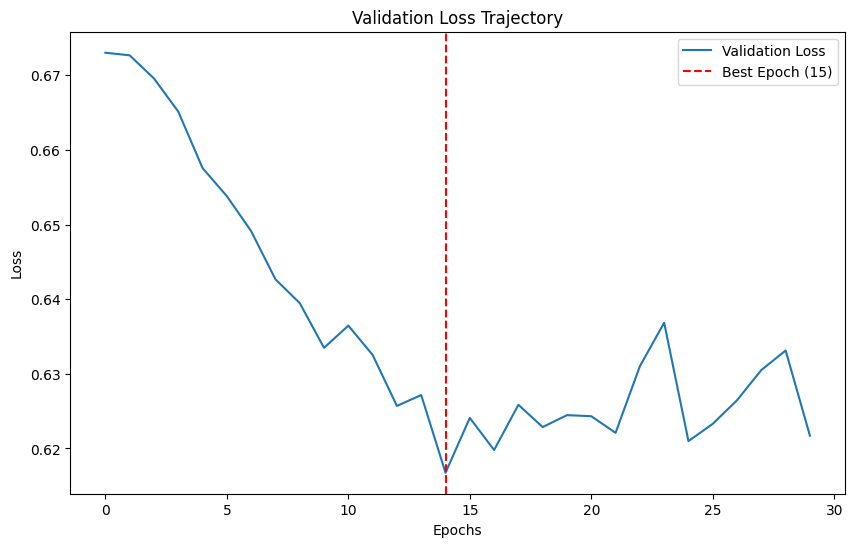

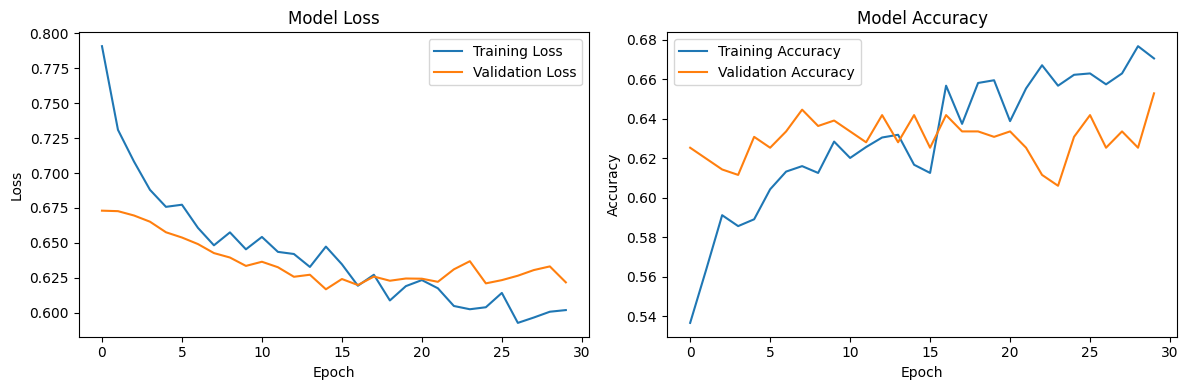


Final evaluation:
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6264 - auc: 0.6954 - loss: 0.6266 - precision: 0.5974 - recall: 0.7730
Metrics Dictionary: {'loss': 0.6412413716316223, 'compile_metrics': 0.6092715263366699}
Manually calculated accuracy: 0.6093

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.45      0.54       227
           1       0.58      0.77      0.66       226

    accuracy                           0.61       453
   macro avg       0.62      0.61      0.60       453
weighted avg       0.62      0.61      0.60       453


Test Metrics Summary:
Test loss: 0.6412
Test compile_metrics: 0.6093
Test accuracy: 0.6093


In [6]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import os
from tensorflow import keras


class EyebrowDeepfakeDetector:
    def __init__(self, model_type='lstm', input_shape=(56,7), num_classes=1):
        self.model_type = model_type
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()
        self.scaler = StandardScaler()

    def _build_model(self):
        """Build and compile the model based on specified architecture type"""
        if self.model_type == 'lstm':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'gru':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'cnn':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling1D(2),
                tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.GlobalAveragePooling1D(),
                tf.keras.layers.Dense(64, activation='relu'),
                tf.keras.layers.Dropout(0.3),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'transformer':
            inputs = tf.keras.Input(shape=self.input_shape)
            pos_encoding = self._positional_encoding(self.input_shape[0], self.input_shape[1])
            x = inputs + pos_encoding[:, :self.input_shape[0], :]
            
            # Transformer block
            x = tf.keras.layers.MultiHeadAttention(
                num_heads=4, key_dim=self.input_shape[1])(x, x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Feed forward network
            x = tf.keras.layers.Dense(128, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Classification head
            x = tf.keras.layers.GlobalAveragePooling1D()(x)
            x = tf.keras.layers.Dense(64, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.2)(x)
            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
            
            model = tf.keras.Model(inputs=inputs, outputs=outputs)
        elif self.model_type=="model-1":
            inputs = tf.keras.Input(shape=(56,7,1))
    
            # Spatial Feature Extraction
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'))(inputs)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)
            
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)
            
            # Temporal Processing
            x = tf.keras.layers.LSTM(256, return_sequences=True)(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.LSTM(128)(x)
            x = tf.keras.layers.Dropout(0.2)(x)
            
            # Classification
            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
            
            model = tf.keras.models.Model(inputs=inputs, outputs=outputs)
        elif self.model_type=="model-2":
            inputs = tf.keras.Input(shape=self.input_shape)  # (75,6)

            # Expand dims if needed
            x = tf.keras.layers.Lambda(lambda x: tf.expand_dims(x, axis=-1))(inputs) # (75,6,1)

            # --- CNN Feature Extraction ---
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)

            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)

            # Flatten across spatial dimensions
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)  # shape: (75, features)

            # --- Transformer Encoder ---
            def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
                # Normalization and Attention
                x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(inputs)
                x = tf.keras.layers.MultiHeadAttention(
                    key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
                x = tf.keras.layers.Dropout(dropout)(x)
                res = x + inputs

                # Feed Forward
                x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(res)
                x = tf.keras.layers.Dense(ff_dim, activation='relu')(x)
                x = tf.keras.layers.Dropout(dropout)(x)
                x = tf.keras.layers.Dense(inputs.shape[-1])(x)
                return x + res

            # Apply Transformer Blocks
            x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)
            x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)

            x = tf.keras.layers.GlobalAveragePooling1D()(x)

            # --- Classification Head ---
            x = tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
            x = tf.keras.layers.Dropout(0.2)(x)

            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

            model = tf.keras.models.Model(inputs, outputs)

        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
            
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss='binary_crossentropy',
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ]
        )
        return model

    def _positional_encoding(self, max_length=56, d_model=7):
        """Generate positional encoding for transformer"""
        positions = np.arange(max_length)[:, np.newaxis]
        depths = np.arange(d_model)[np.newaxis, :]/d_model
        
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.zeros(angle_rads.shape)
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        
        return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

    def load_data(self, csv_path):
        """Load and reshape eyebrow movement data"""
        df = pd.read_csv(csv_path, header=None)
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(np.int32)
        
        # Reshape to (samples, 75, 3)
        if X.shape[1] == 392:  # Verify input dimensions
            X = X.reshape(-1, 56, 7)
        return X, y

    def preprocess_data(self, X, y, test_size=0.2):
        """Standardize features and split data"""
        # Stratified train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=42)
        
        # Feature-wise standardization
        orig_shape = X_train.shape
        self.scaler.fit(X_train.reshape(-1, 7))
        X_train = self.scaler.transform(X_train.reshape(-1, 7)).reshape(orig_shape)
        X_test = self.scaler.transform(X_test.reshape(-1, 7)).reshape(X_test.shape)
        
        return X_train, X_test, y_train, y_test

    def train(self, X_train, y_train, X_val, y_val, epochs=100):
        """Train model with early stopping and checkpointing"""
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(
                f'best_{self.model_type}_model.keras', save_best_only=True)
        ]
        
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=64,
            callbacks=callbacks,
            verbose=2
        )

        # Print final training metrics
        print("\nFinal Training Metrics:")
        for metric in history.history:
            if not metric.startswith('val_'):
                print(f"Training {metric}: {history.history[metric][-1]:.4f}")
        
        # Print final validation metrics
        print("\nFinal Validation Metrics:")
        for metric in history.history:
            if metric.startswith('val_'):
                print(f"{metric}: {history.history[metric][-1]:.4f}")

                # Analyze stopping reason
        best_epoch = np.argmin(history.history['val_loss']) + 1
        print(f"Best model found at epoch {best_epoch}")

        # Plot validation metrics trajectory
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.axvline(x=best_epoch-1, color='r', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
        plt.title('Validation Loss Trajectory')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        return history

    def evaluate(self, X_test, y_test):
        """Comprehensive model evaluation"""
        # Quantitative metrics
        results = self.model.evaluate(X_test, y_test, verbose=1)
        metrics = dict(zip(self.model.metrics_names, results))
        
        # Debug: Print the metrics dictionary
        print("Metrics Dictionary:", metrics)
        
        # Qualitative analysis
        y_pred_prob = self.model.predict(X_test,verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        # Calculate and print accuracy directly
        from sklearn.metrics import accuracy_score
        calc_accuracy = accuracy_score(y_test, y_pred)
        print(f"Manually calculated accuracy: {calc_accuracy:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        plt.xticks([0, 1], ['Real', 'Fake'])
        plt.yticks([0, 1], ['Real', 'Fake'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(f'{self.model_type}_confusion_matrix.png')
        plt.close()
        
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.savefig(f'{self.model_type}_roc_curve.png')
        plt.close()
        
        # Ensure accuracy is in the metrics dictionary
        if 'accuracy' not in metrics:
            metrics['accuracy'] = calc_accuracy
        
        return metrics


# Usage example
if __name__ == "__main__":
    # Initialize detector - choose model type
    detector = EyebrowDeepfakeDetector(model_type='lstm', input_shape=(56, 7))
    
    # Load and preprocess data
    X, y = detector.load_data(os.path.join("","comprehensive_features-deepfake_new.csv"))
    X_train, X_test, y_train, y_test = detector.preprocess_data(X, y)
    
    # Split validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # Train model
    print("Model architecture:")
    detector.model.summary()
    history = detector.train(X_train, y_train, X_val, y_val)
    
        # Plot training history
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{detector.model_type}_training_history.png')
    plt.show()
    plt.close('all')

    # Evaluate
    print("\nFinal evaluation:")
    test_metrics = detector.evaluate(X_test, y_test)

        # Print all metrics in a formatted way
    print("\nTest Metrics Summary:")
    for metric_name, metric_value in test_metrics.items():
        print(f"Test {metric_name}: {metric_value:.4f}")

    # Save final model
    detector.model.save(f'final_{detector.model_type}_model.keras')


Model architecture:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_12 (Conv1D)              │ (None, 56, 64)         │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 56, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 28, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 28, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 28, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_5      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,201 (137.50 KB)

 Trainable params: 34,817 (136.00 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/200
27/27 - 3s - 115ms/step - accuracy: 0.6297 - auc: 0.6686 - loss: 0.6603 - precision: 0.6691 - recall: 0.6812 - val_accuracy: 0.6379 - val_auc: 0.6737 - val_loss: 0.6679 - val_precision: 0.6721 - val_recall: 0.7034
Epoch 2/200
27/27 - 1s - 19ms/step - accuracy: 0.6567 - auc: 0.7145 - loss: 0.6130 - precision: 0.6936 - recall: 0.7024 - val_accuracy: 0.6571 - val_auc: 0.7213 - val_loss: 0.6521 - val_precision: 0.7204 - val_recall: 0.6441
Epoch 3/200
27/27 - 0s - 18ms/step - accuracy: 0.6771 - auc: 0.7298 - loss: 0.6075 - precision: 0.7067 - recall: 0.7322 - val_accuracy: 0.6283 - val_auc: 0.7089 - val_loss: 0.6386 - val_precision: 0.6627 - val_recall: 0.6992
Epoch 4/200
27/27 - 1s - 20ms/step - accuracy: 0.6831 - auc: 0.7454 - loss: 0.5864 - precision: 0.7011 - recall: 0.7651 - val_accuracy: 0.6571 - val_auc: 0.7304 - val_loss: 0.6256 - val_precision: 0.6555 - val_recall: 0.8305
Epoch 5/200
27/27 - 1s - 20ms/step - accuracy: 0.6933 - auc: 0.7669 - loss: 0.5644 - precision: 0.7

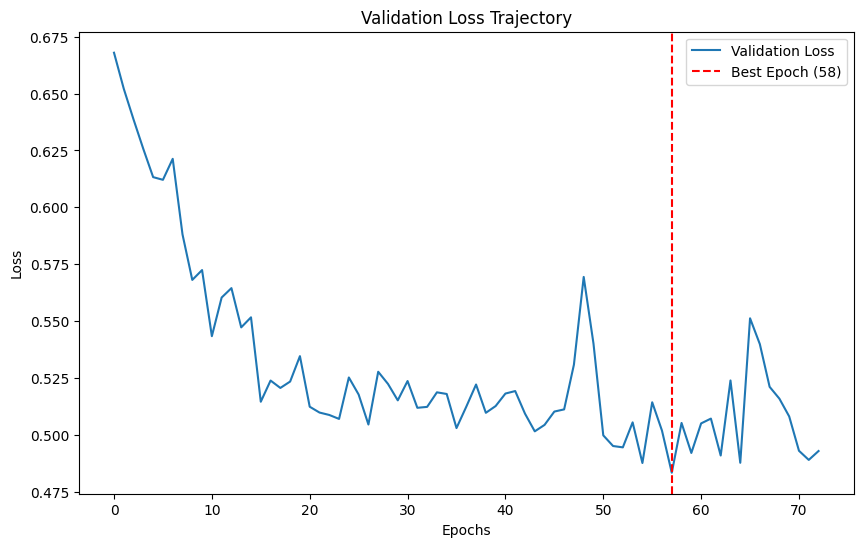

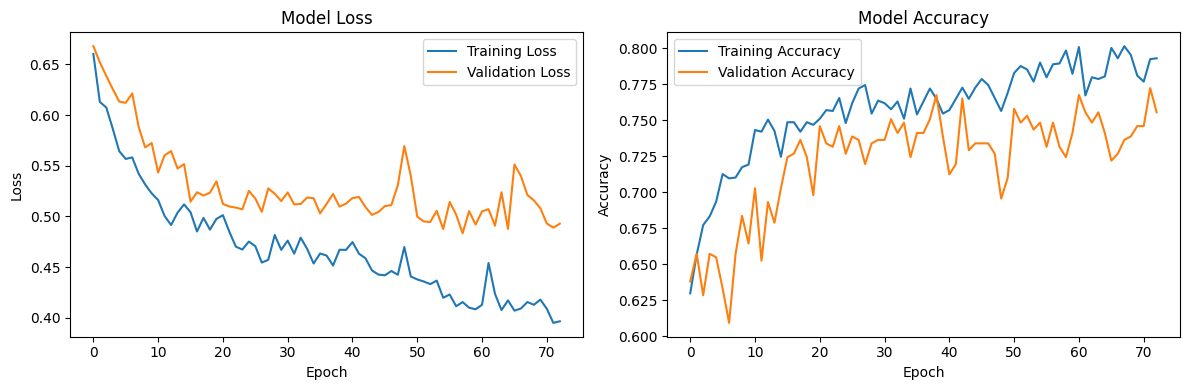


Final evaluation:
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7131 - auc: 0.8288 - loss: 0.4982 - precision: 0.7023 - recall: 0.8513
Metrics Dictionary: {'loss': 0.49385789036750793, 'compile_metrics': 0.7216890454292297}
Manually calculated accuracy: 0.7217

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.56      0.64       226
           1       0.72      0.84      0.77       295

    accuracy                           0.72       521
   macro avg       0.72      0.70      0.71       521
weighted avg       0.72      0.72      0.71       521


Test Metrics Summary:
Test loss: 0.4939
Test compile_metrics: 0.7217
Test accuracy: 0.7217


In [8]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import os
from tensorflow import keras


class EyebrowDeepfakeDetector:
    def __init__(self, model_type='lstm', input_shape=(56,7), num_classes=1):
        self.model_type = model_type
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()
        self.scaler = StandardScaler()

    def _build_model(self):
        """Build and compile the model based on specified architecture type"""
        if self.model_type == 'lstm':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'gru':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'cnn':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling1D(2),
                tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.GlobalAveragePooling1D(),
                tf.keras.layers.Dense(64, activation='relu'),
                tf.keras.layers.Dropout(0.3),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'transformer':
            inputs = tf.keras.Input(shape=self.input_shape)
            pos_encoding = self._positional_encoding(self.input_shape[0], self.input_shape[1])
            x = inputs + pos_encoding[:, :self.input_shape[0], :]
            
            # Transformer block
            x = tf.keras.layers.MultiHeadAttention(
                num_heads=4, key_dim=self.input_shape[1])(x, x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Feed forward network
            x = tf.keras.layers.Dense(128, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Classification head
            x = tf.keras.layers.GlobalAveragePooling1D()(x)
            x = tf.keras.layers.Dense(64, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.2)(x)
            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
            
            model = tf.keras.Model(inputs=inputs, outputs=outputs)
        elif self.model_type=="model-1":
            inputs = tf.keras.Input(shape=(56,7,1))
    
            # Spatial Feature Extraction
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'))(inputs)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)
            
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)
            
            # Temporal Processing
            x = tf.keras.layers.LSTM(256, return_sequences=True)(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.LSTM(128)(x)
            x = tf.keras.layers.Dropout(0.2)(x)
            
            # Classification
            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
            
            model = tf.keras.models.Model(inputs=inputs, outputs=outputs)
        elif self.model_type=="model-2":
            inputs = tf.keras.Input(shape=self.input_shape)  # (75,6)

            # Expand dims if needed
            x = tf.keras.layers.Lambda(lambda x: tf.expand_dims(x, axis=-1))(inputs) # (75,6,1)

            # --- CNN Feature Extraction ---
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)

            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)

            # Flatten across spatial dimensions
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)  # shape: (75, features)

            # --- Transformer Encoder ---
            def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
                # Normalization and Attention
                x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(inputs)
                x = tf.keras.layers.MultiHeadAttention(
                    key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
                x = tf.keras.layers.Dropout(dropout)(x)
                res = x + inputs

                # Feed Forward
                x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(res)
                x = tf.keras.layers.Dense(ff_dim, activation='relu')(x)
                x = tf.keras.layers.Dropout(dropout)(x)
                x = tf.keras.layers.Dense(inputs.shape[-1])(x)
                return x + res

            # Apply Transformer Blocks
            x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)
            x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)

            x = tf.keras.layers.GlobalAveragePooling1D()(x)

            # --- Classification Head ---
            x = tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
            x = tf.keras.layers.Dropout(0.2)(x)

            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

            model = tf.keras.models.Model(inputs, outputs)

        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
            
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss='binary_crossentropy',
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ]
        )
        return model

    def _positional_encoding(self, max_length=56, d_model=7):
        """Generate positional encoding for transformer"""
        positions = np.arange(max_length)[:, np.newaxis]
        depths = np.arange(d_model)[np.newaxis, :]/d_model
        
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.zeros(angle_rads.shape)
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        
        return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

    def load_data(self, csv_path):
        """Load and reshape eyebrow movement data"""
        df = pd.read_csv(csv_path, header=None)
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(np.int32)
        
        # Reshape to (samples, 75, 3)
        if X.shape[1] == 392:  # Verify input dimensions
            X = X.reshape(-1, 56, 7)
        return X, y

    def preprocess_data(self, X, y, test_size=0.2):
        """Standardize features and split data"""
        # Stratified train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=42)
        
        # Feature-wise standardization
        orig_shape = X_train.shape
        self.scaler.fit(X_train.reshape(-1, 7))
        X_train = self.scaler.transform(X_train.reshape(-1, 7)).reshape(orig_shape)
        X_test = self.scaler.transform(X_test.reshape(-1, 7)).reshape(X_test.shape)
        
        return X_train, X_test, y_train, y_test

    def train(self, X_train, y_train, X_val, y_val, epochs=200):
        """Train model with early stopping and checkpointing"""
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(
                f'best_{self.model_type}_model.keras', save_best_only=True)
        ]
        
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=64,
            callbacks=callbacks,
            verbose=2
        )

        # Print final training metrics
        print("\nFinal Training Metrics:")
        for metric in history.history:
            if not metric.startswith('val_'):
                print(f"Training {metric}: {history.history[metric][-1]:.4f}")
        
        # Print final validation metrics
        print("\nFinal Validation Metrics:")
        for metric in history.history:
            if metric.startswith('val_'):
                print(f"{metric}: {history.history[metric][-1]:.4f}")

                # Analyze stopping reason
        best_epoch = np.argmin(history.history['val_loss']) + 1
        print(f"Best model found at epoch {best_epoch}")

        # Plot validation metrics trajectory
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.axvline(x=best_epoch-1, color='r', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
        plt.title('Validation Loss Trajectory')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        return history

    def evaluate(self, X_test, y_test):
        """Comprehensive model evaluation"""
        # Quantitative metrics
        results = self.model.evaluate(X_test, y_test, verbose=1)
        metrics = dict(zip(self.model.metrics_names, results))
        
        # Debug: Print the metrics dictionary
        print("Metrics Dictionary:", metrics)
        
        # Qualitative analysis
        y_pred_prob = self.model.predict(X_test,verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        # Calculate and print accuracy directly
        from sklearn.metrics import accuracy_score
        calc_accuracy = accuracy_score(y_test, y_pred)
        print(f"Manually calculated accuracy: {calc_accuracy:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        plt.xticks([0, 1], ['Real', 'Fake'])
        plt.yticks([0, 1], ['Real', 'Fake'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(f'{self.model_type}_confusion_matrix.png')
        plt.close()
        
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.savefig(f'{self.model_type}_roc_curve.png')
        plt.close()
        
        # Ensure accuracy is in the metrics dictionary
        if 'accuracy' not in metrics:
            metrics['accuracy'] = calc_accuracy
        
        return metrics


# Usage example
if __name__ == "__main__":
    # Initialize detector - choose model type
    detector = EyebrowDeepfakeDetector(model_type='cnn', input_shape=(56, 7))
    
    # Load and preprocess data
    X, y = detector.load_data(os.path.join("","comprehensive_features-DeepFakeDetection_new.csv"))
    X_train, X_test, y_train, y_test = detector.preprocess_data(X, y)
    
    # Split validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # Train model
    print("Model architecture:")
    detector.model.summary()
    history = detector.train(X_train, y_train, X_val, y_val)
    
        # Plot training history
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{detector.model_type}_training_history.png')
    plt.show()
    plt.close('all')

    # Evaluate
    print("\nFinal evaluation:")
    test_metrics = detector.evaluate(X_test, y_test)

        # Print all metrics in a formatted way
    print("\nTest Metrics Summary:")
    for metric_name, metric_value in test_metrics.items():
        print(f"Test {metric_name}: {metric_value:.4f}")

    # Save final model
    detector.model.save(f'final_{detector.model_type}_model.keras')


Model architecture:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ (None, 56, 128)        │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 56, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 56, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,905 (312.13 KB)

 Trainable params: 79,521 (310.63 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
27/27 - 8s - 294ms/step - accuracy: 0.5510 - auc: 0.5663 - loss: 0.7472 - precision: 0.5960 - recall: 0.6366 - val_accuracy: 0.6187 - val_auc: 0.6587 - val_loss: 0.6734 - val_precision: 0.7127 - val_recall: 0.5466
Epoch 2/100
27/27 - 2s - 86ms/step - accuracy: 0.6086 - auc: 0.6428 - loss: 0.6716 - precision: 0.6510 - recall: 0.6621 - val_accuracy: 0.6283 - val_auc: 0.6805 - val_loss: 0.6661 - val_precision: 0.7098 - val_recall: 0.5805
Epoch 3/100
27/27 - 2s - 83ms/step - accuracy: 0.6134 - auc: 0.6600 - loss: 0.6540 - precision: 0.6571 - recall: 0.6599 - val_accuracy: 0.6355 - val_auc: 0.6836 - val_loss: 0.6550 - val_precision: 0.6944 - val_recall: 0.6356
Epoch 4/100
27/27 - 2s - 85ms/step - accuracy: 0.6291 - auc: 0.6747 - loss: 0.6434 - precision: 0.6653 - recall: 0.6908 - val_accuracy: 0.6547 - val_auc: 0.7079 - val_loss: 0.6451 - val_precision: 0.7255 - val_recall: 0.6271
Epoch 5/100
27/27 - 2s - 84ms/step - accuracy: 0.6363 - auc: 0.6831 - loss: 0.6364 - precision: 0.6

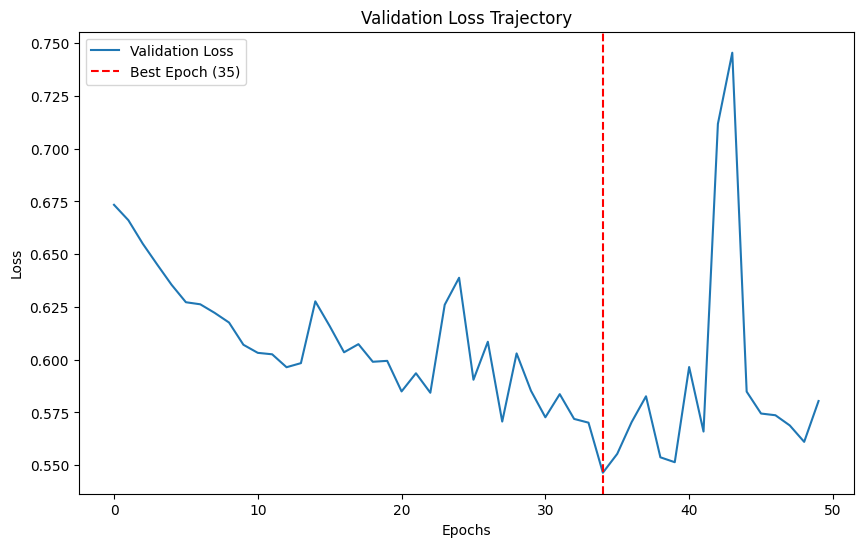

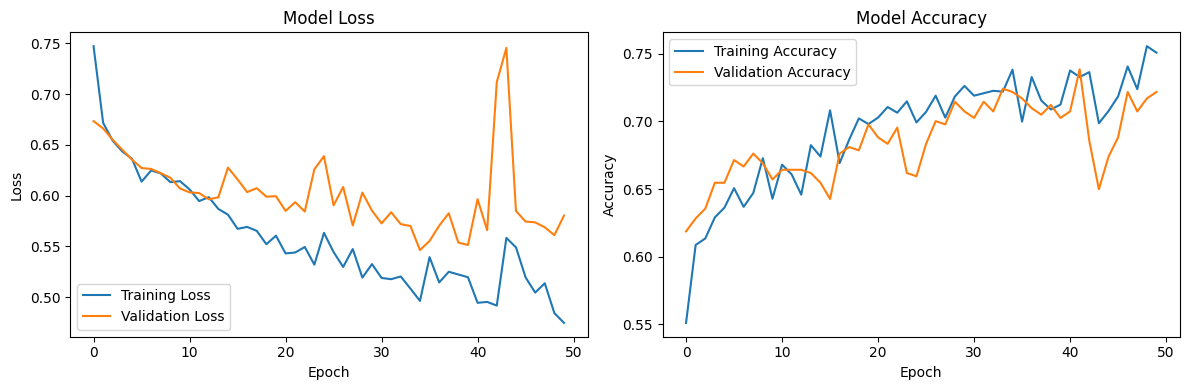


Final evaluation:
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7042 - auc: 0.7842 - loss: 0.5723 - precision: 0.7114 - recall: 0.7988
Metrics Dictionary: {'loss': 0.5640639066696167, 'compile_metrics': 0.6890594959259033}
Manually calculated accuracy: 0.6891

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.56      0.61       226
           1       0.70      0.79      0.74       295

    accuracy                           0.69       521
   macro avg       0.68      0.67      0.68       521
weighted avg       0.69      0.69      0.68       521


Test Metrics Summary:
Test loss: 0.5641
Test compile_metrics: 0.6891
Test accuracy: 0.6891


In [9]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import os
from tensorflow import keras


class EyebrowDeepfakeDetector:
    def __init__(self, model_type='lstm', input_shape=(56,7), num_classes=1):
        self.model_type = model_type
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()
        self.scaler = StandardScaler()

    def _build_model(self):
        """Build and compile the model based on specified architecture type"""
        if self.model_type == 'lstm':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'gru':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'cnn':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling1D(2),
                tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.GlobalAveragePooling1D(),
                tf.keras.layers.Dense(64, activation='relu'),
                tf.keras.layers.Dropout(0.3),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'transformer':
            inputs = tf.keras.Input(shape=self.input_shape)
            pos_encoding = self._positional_encoding(self.input_shape[0], self.input_shape[1])
            x = inputs + pos_encoding[:, :self.input_shape[0], :]
            
            # Transformer block
            x = tf.keras.layers.MultiHeadAttention(
                num_heads=4, key_dim=self.input_shape[1])(x, x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Feed forward network
            x = tf.keras.layers.Dense(128, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Classification head
            x = tf.keras.layers.GlobalAveragePooling1D()(x)
            x = tf.keras.layers.Dense(64, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.2)(x)
            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
            
            model = tf.keras.Model(inputs=inputs, outputs=outputs)
        elif self.model_type=="model-1":
            inputs = tf.keras.Input(shape=(56,7,1))
    
            # Spatial Feature Extraction
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'))(inputs)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)
            
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)
            
            # Temporal Processing
            x = tf.keras.layers.LSTM(256, return_sequences=True)(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.LSTM(128)(x)
            x = tf.keras.layers.Dropout(0.2)(x)
            
            # Classification
            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
            
            model = tf.keras.models.Model(inputs=inputs, outputs=outputs)
        elif self.model_type=="model-2":
            inputs = tf.keras.Input(shape=self.input_shape)  # (75,6)

            # Expand dims if needed
            x = tf.keras.layers.Lambda(lambda x: tf.expand_dims(x, axis=-1))(inputs) # (75,6,1)

            # --- CNN Feature Extraction ---
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)

            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)

            # Flatten across spatial dimensions
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)  # shape: (75, features)

            # --- Transformer Encoder ---
            def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
                # Normalization and Attention
                x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(inputs)
                x = tf.keras.layers.MultiHeadAttention(
                    key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
                x = tf.keras.layers.Dropout(dropout)(x)
                res = x + inputs

                # Feed Forward
                x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(res)
                x = tf.keras.layers.Dense(ff_dim, activation='relu')(x)
                x = tf.keras.layers.Dropout(dropout)(x)
                x = tf.keras.layers.Dense(inputs.shape[-1])(x)
                return x + res

            # Apply Transformer Blocks
            x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)
            x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)

            x = tf.keras.layers.GlobalAveragePooling1D()(x)

            # --- Classification Head ---
            x = tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
            x = tf.keras.layers.Dropout(0.2)(x)

            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

            model = tf.keras.models.Model(inputs, outputs)

        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
            
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss='binary_crossentropy',
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ]
        )
        return model

    def _positional_encoding(self, max_length=56, d_model=7):
        """Generate positional encoding for transformer"""
        positions = np.arange(max_length)[:, np.newaxis]
        depths = np.arange(d_model)[np.newaxis, :]/d_model
        
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.zeros(angle_rads.shape)
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        
        return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

    def load_data(self, csv_path):
        """Load and reshape eyebrow movement data"""
        df = pd.read_csv(csv_path, header=None)
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(np.int32)
        
        # Reshape to (samples, 75, 3)
        if X.shape[1] == 392:  # Verify input dimensions
            X = X.reshape(-1, 56, 7)
        return X, y

    def preprocess_data(self, X, y, test_size=0.2):
        """Standardize features and split data"""
        # Stratified train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=42)
        
        # Feature-wise standardization
        orig_shape = X_train.shape
        self.scaler.fit(X_train.reshape(-1, 7))
        X_train = self.scaler.transform(X_train.reshape(-1, 7)).reshape(orig_shape)
        X_test = self.scaler.transform(X_test.reshape(-1, 7)).reshape(X_test.shape)
        
        return X_train, X_test, y_train, y_test

    def train(self, X_train, y_train, X_val, y_val, epochs=100):
        """Train model with early stopping and checkpointing"""
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(
                f'best_{self.model_type}_model.keras', save_best_only=True)
        ]
        
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=64,
            callbacks=callbacks,
            verbose=2
        )

        # Print final training metrics
        print("\nFinal Training Metrics:")
        for metric in history.history:
            if not metric.startswith('val_'):
                print(f"Training {metric}: {history.history[metric][-1]:.4f}")
        
        # Print final validation metrics
        print("\nFinal Validation Metrics:")
        for metric in history.history:
            if metric.startswith('val_'):
                print(f"{metric}: {history.history[metric][-1]:.4f}")

                # Analyze stopping reason
        best_epoch = np.argmin(history.history['val_loss']) + 1
        print(f"Best model found at epoch {best_epoch}")

        # Plot validation metrics trajectory
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.axvline(x=best_epoch-1, color='r', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
        plt.title('Validation Loss Trajectory')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        return history

    def evaluate(self, X_test, y_test):
        """Comprehensive model evaluation"""
        # Quantitative metrics
        results = self.model.evaluate(X_test, y_test, verbose=1)
        metrics = dict(zip(self.model.metrics_names, results))
        
        # Debug: Print the metrics dictionary
        print("Metrics Dictionary:", metrics)
        
        # Qualitative analysis
        y_pred_prob = self.model.predict(X_test,verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        # Calculate and print accuracy directly
        from sklearn.metrics import accuracy_score
        calc_accuracy = accuracy_score(y_test, y_pred)
        print(f"Manually calculated accuracy: {calc_accuracy:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        plt.xticks([0, 1], ['Real', 'Fake'])
        plt.yticks([0, 1], ['Real', 'Fake'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(f'{self.model_type}_confusion_matrix.png')
        plt.close()
        
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.savefig(f'{self.model_type}_roc_curve.png')
        plt.close()
        
        # Ensure accuracy is in the metrics dictionary
        if 'accuracy' not in metrics:
            metrics['accuracy'] = calc_accuracy
        
        return metrics


# Usage example
if __name__ == "__main__":
    # Initialize detector - choose model type
    detector = EyebrowDeepfakeDetector(model_type='lstm', input_shape=(56, 7))
    
    # Load and preprocess data
    X, y = detector.load_data(os.path.join("","comprehensive_features-DeepFakeDetection_new.csv"))
    X_train, X_test, y_train, y_test = detector.preprocess_data(X, y)
    
    # Split validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # Train model
    print("Model architecture:")
    detector.model.summary()
    history = detector.train(X_train, y_train, X_val, y_val)
    
        # Plot training history
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{detector.model_type}_training_history.png')
    plt.show()
    plt.close('all')

    # Evaluate
    print("\nFinal evaluation:")
    test_metrics = detector.evaluate(X_test, y_test)

        # Print all metrics in a formatted way
    print("\nTest Metrics Summary:")
    for metric_name, metric_value in test_metrics.items():
        print(f"Test {metric_name}: {metric_value:.4f}")

    # Save final model
    detector.model.save(f'final_{detector.model_type}_model.keras')


Model architecture:


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_14 (Conv1D)              │ (None, 56, 64)         │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 56, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 28, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_15 (Conv1D)              │ (None, 28, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 28, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_6      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,201 (137.50 KB)

 Trainable params: 34,817 (136.00 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/200
23/23 - 3s - 109ms/step - accuracy: 0.5290 - auc: 0.5258 - loss: 0.7635 - precision: 0.5286 - recall: 0.5359 - val_accuracy: 0.4959 - val_auc: 0.5154 - val_loss: 0.6940 - val_precision: 0.4966 - val_recall: 0.4011
Epoch 2/200
23/23 - 0s - 19ms/step - accuracy: 0.5380 - auc: 0.5529 - loss: 0.7279 - precision: 0.5356 - recall: 0.5718 - val_accuracy: 0.5179 - val_auc: 0.5414 - val_loss: 0.6905 - val_precision: 0.5354 - val_recall: 0.2912
Epoch 3/200
23/23 - 0s - 16ms/step - accuracy: 0.5518 - auc: 0.5844 - loss: 0.7002 - precision: 0.5519 - recall: 0.5511 - val_accuracy: 0.4848 - val_auc: 0.5132 - val_loss: 0.6911 - val_precision: 0.4874 - val_recall: 0.5330
Epoch 4/200
23/23 - 0s - 19ms/step - accuracy: 0.5663 - auc: 0.5899 - loss: 0.6967 - precision: 0.5614 - recall: 0.6064 - val_accuracy: 0.5647 - val_auc: 0.5665 - val_loss: 0.6880 - val_precision: 0.5522 - val_recall: 0.6978
Epoch 5/200
23/23 - 0s - 18ms/step - accuracy: 0.5546 - auc: 0.5809 - loss: 0.6920 - precision: 0.5

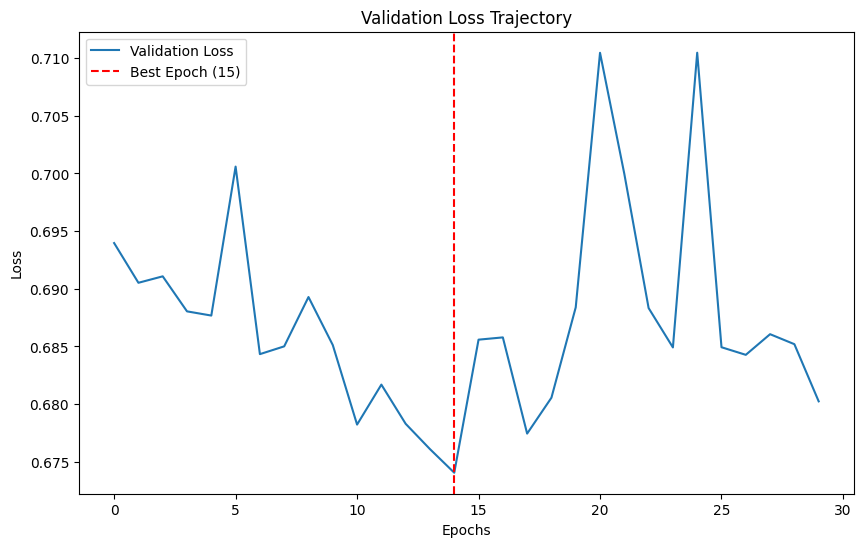

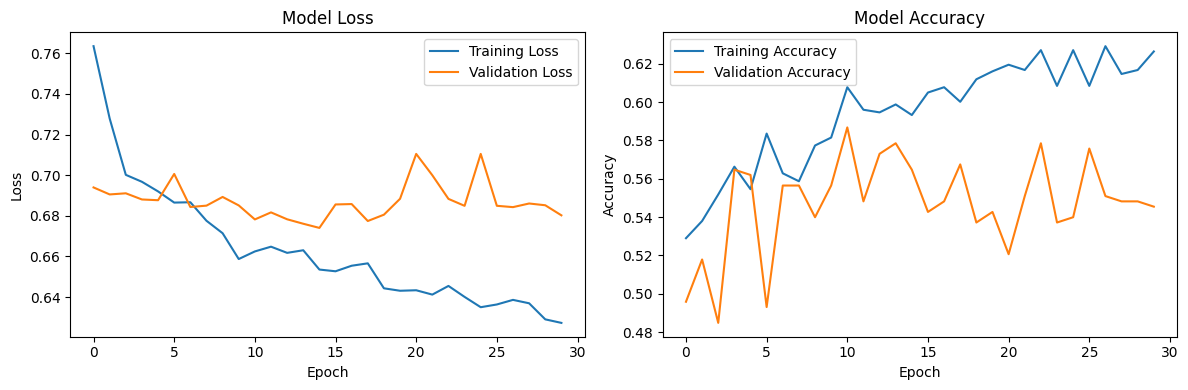


Final evaluation:
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5767 - auc: 0.6210 - loss: 0.6679 - precision: 0.5724 - recall: 0.6223
Metrics Dictionary: {'loss': 0.6649669408798218, 'compile_metrics': 0.5938189625740051}
Manually calculated accuracy: 0.5938

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.56      0.58       227
           1       0.59      0.62      0.61       226

    accuracy                           0.59       453
   macro avg       0.59      0.59      0.59       453
weighted avg       0.59      0.59      0.59       453


Test Metrics Summary:
Test loss: 0.6650
Test compile_metrics: 0.5938
Test accuracy: 0.5938


In [10]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import os
from tensorflow import keras


class EyebrowDeepfakeDetector:
    def __init__(self, model_type='lstm', input_shape=(56,7), num_classes=1):
        self.model_type = model_type
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()
        self.scaler = StandardScaler()

    def _build_model(self):
        """Build and compile the model based on specified architecture type"""
        if self.model_type == 'lstm':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'gru':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'cnn':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling1D(2),
                tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.GlobalAveragePooling1D(),
                tf.keras.layers.Dense(64, activation='relu'),
                tf.keras.layers.Dropout(0.3),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'transformer':
            inputs = tf.keras.Input(shape=self.input_shape)
            pos_encoding = self._positional_encoding(self.input_shape[0], self.input_shape[1])
            x = inputs + pos_encoding[:, :self.input_shape[0], :]
            
            # Transformer block
            x = tf.keras.layers.MultiHeadAttention(
                num_heads=4, key_dim=self.input_shape[1])(x, x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Feed forward network
            x = tf.keras.layers.Dense(128, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Classification head
            x = tf.keras.layers.GlobalAveragePooling1D()(x)
            x = tf.keras.layers.Dense(64, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.2)(x)
            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
            
            model = tf.keras.Model(inputs=inputs, outputs=outputs)
        elif self.model_type=="model-1":
            inputs = tf.keras.Input(shape=(56,7,1))
    
            # Spatial Feature Extraction
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'))(inputs)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)
            
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)
            
            # Temporal Processing
            x = tf.keras.layers.LSTM(256, return_sequences=True)(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.LSTM(128)(x)
            x = tf.keras.layers.Dropout(0.2)(x)
            
            # Classification
            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
            
            model = tf.keras.models.Model(inputs=inputs, outputs=outputs)
        elif self.model_type=="model-2":
            inputs = tf.keras.Input(shape=self.input_shape)  # (75,6)

            # Expand dims if needed
            x = tf.keras.layers.Lambda(lambda x: tf.expand_dims(x, axis=-1))(inputs) # (75,6,1)

            # --- CNN Feature Extraction ---
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)

            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)

            # Flatten across spatial dimensions
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)  # shape: (75, features)

            # --- Transformer Encoder ---
            def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
                # Normalization and Attention
                x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(inputs)
                x = tf.keras.layers.MultiHeadAttention(
                    key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
                x = tf.keras.layers.Dropout(dropout)(x)
                res = x + inputs

                # Feed Forward
                x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(res)
                x = tf.keras.layers.Dense(ff_dim, activation='relu')(x)
                x = tf.keras.layers.Dropout(dropout)(x)
                x = tf.keras.layers.Dense(inputs.shape[-1])(x)
                return x + res

            # Apply Transformer Blocks
            x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)
            x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)

            x = tf.keras.layers.GlobalAveragePooling1D()(x)

            # --- Classification Head ---
            x = tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
            x = tf.keras.layers.Dropout(0.2)(x)

            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

            model = tf.keras.models.Model(inputs, outputs)

        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
            
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss='binary_crossentropy',
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ]
        )
        return model

    def _positional_encoding(self, max_length=56, d_model=7):
        """Generate positional encoding for transformer"""
        positions = np.arange(max_length)[:, np.newaxis]
        depths = np.arange(d_model)[np.newaxis, :]/d_model
        
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.zeros(angle_rads.shape)
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        
        return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

    def load_data(self, csv_path):
        """Load and reshape eyebrow movement data"""
        df = pd.read_csv(csv_path, header=None)
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(np.int32)
        
        # Reshape to (samples, 75, 3)
        if X.shape[1] == 392:  # Verify input dimensions
            X = X.reshape(-1, 56, 7)
        return X, y

    def preprocess_data(self, X, y, test_size=0.2):
        """Standardize features and split data"""
        # Stratified train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=42)
        
        # Feature-wise standardization
        orig_shape = X_train.shape
        self.scaler.fit(X_train.reshape(-1, 7))
        X_train = self.scaler.transform(X_train.reshape(-1, 7)).reshape(orig_shape)
        X_test = self.scaler.transform(X_test.reshape(-1, 7)).reshape(X_test.shape)
        
        return X_train, X_test, y_train, y_test

    def train(self, X_train, y_train, X_val, y_val, epochs=200):
        """Train model with early stopping and checkpointing"""
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(
                f'best_{self.model_type}_model.keras', save_best_only=True)
        ]
        
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=64,
            callbacks=callbacks,
            verbose=2
        )

        # Print final training metrics
        print("\nFinal Training Metrics:")
        for metric in history.history:
            if not metric.startswith('val_'):
                print(f"Training {metric}: {history.history[metric][-1]:.4f}")
        
        # Print final validation metrics
        print("\nFinal Validation Metrics:")
        for metric in history.history:
            if metric.startswith('val_'):
                print(f"{metric}: {history.history[metric][-1]:.4f}")

                # Analyze stopping reason
        best_epoch = np.argmin(history.history['val_loss']) + 1
        print(f"Best model found at epoch {best_epoch}")

        # Plot validation metrics trajectory
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.axvline(x=best_epoch-1, color='r', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
        plt.title('Validation Loss Trajectory')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        return history

    def evaluate(self, X_test, y_test):
        """Comprehensive model evaluation"""
        # Quantitative metrics
        results = self.model.evaluate(X_test, y_test, verbose=1)
        metrics = dict(zip(self.model.metrics_names, results))
        
        # Debug: Print the metrics dictionary
        print("Metrics Dictionary:", metrics)
        
        # Qualitative analysis
        y_pred_prob = self.model.predict(X_test,verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        # Calculate and print accuracy directly
        from sklearn.metrics import accuracy_score
        calc_accuracy = accuracy_score(y_test, y_pred)
        print(f"Manually calculated accuracy: {calc_accuracy:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        plt.xticks([0, 1], ['Real', 'Fake'])
        plt.yticks([0, 1], ['Real', 'Fake'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(f'{self.model_type}_confusion_matrix.png')
        plt.close()
        
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.savefig(f'{self.model_type}_roc_curve.png')
        plt.close()
        
        # Ensure accuracy is in the metrics dictionary
        if 'accuracy' not in metrics:
            metrics['accuracy'] = calc_accuracy
        
        return metrics


# Usage example
if __name__ == "__main__":
    # Initialize detector - choose model type
    detector = EyebrowDeepfakeDetector(model_type='cnn', input_shape=(56, 7))
    
    # Load and preprocess data
    X, y = detector.load_data(os.path.join("","comprehensive_features-Face2Face_new.csv"))
    X_train, X_test, y_train, y_test = detector.preprocess_data(X, y)
    
    # Split validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # Train model
    print("Model architecture:")
    detector.model.summary()
    history = detector.train(X_train, y_train, X_val, y_val)
    
        # Plot training history
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{detector.model_type}_training_history.png')
    plt.show()
    plt.close('all')

    # Evaluate
    print("\nFinal evaluation:")
    test_metrics = detector.evaluate(X_test, y_test)

        # Print all metrics in a formatted way
    print("\nTest Metrics Summary:")
    for metric_name, metric_value in test_metrics.items():
        print(f"Test {metric_name}: {metric_value:.4f}")

    # Save final model
    detector.model.save(f'final_{detector.model_type}_model.keras')


Model architecture:


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_4 (Bidirectional) │ (None, 56, 128)        │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 56, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 56, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,905 (312.13 KB)

 Trainable params: 79,521 (310.63 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/200
23/23 - 8s - 350ms/step - accuracy: 0.5145 - auc: 0.5136 - loss: 0.8026 - precision: 0.5146 - recall: 0.5110 - val_accuracy: 0.4876 - val_auc: 0.5097 - val_loss: 0.6929 - val_precision: 0.4899 - val_recall: 0.5330
Epoch 2/200
23/23 - 2s - 85ms/step - accuracy: 0.5221 - auc: 0.5243 - loss: 0.7590 - precision: 0.5218 - recall: 0.5290 - val_accuracy: 0.5124 - val_auc: 0.5306 - val_loss: 0.6900 - val_precision: 0.5116 - val_recall: 0.6044
Epoch 3/200
23/23 - 2s - 82ms/step - accuracy: 0.5117 - auc: 0.5301 - loss: 0.7330 - precision: 0.5119 - recall: 0.5041 - val_accuracy: 0.5262 - val_auc: 0.5184 - val_loss: 0.6928 - val_precision: 0.5170 - val_recall: 0.8352
Epoch 4/200
23/23 - 2s - 82ms/step - accuracy: 0.5186 - auc: 0.5359 - loss: 0.7237 - precision: 0.5174 - recall: 0.5552 - val_accuracy: 0.5124 - val_auc: 0.4923 - val_loss: 0.6932 - val_precision: 0.5082 - val_recall: 0.8516
Epoch 5/200
23/23 - 2s - 84ms/step - accuracy: 0.5207 - auc: 0.5342 - loss: 0.7176 - precision: 0.5

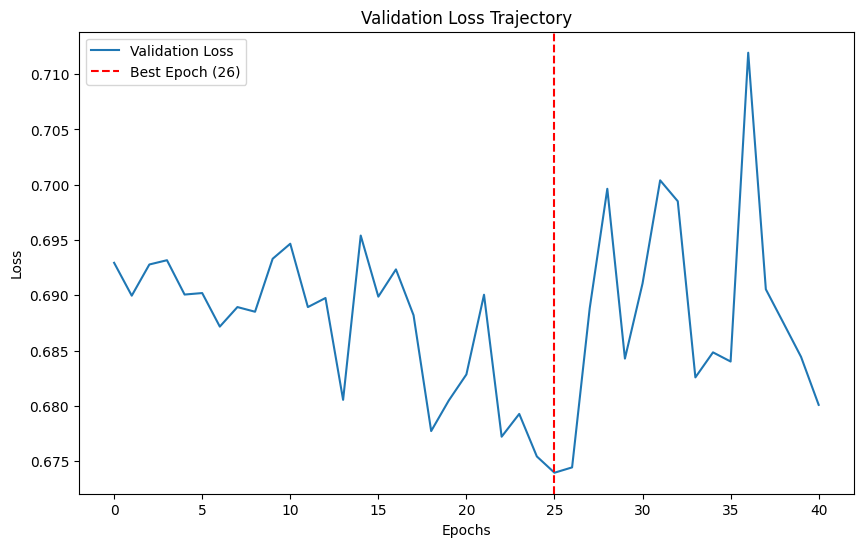

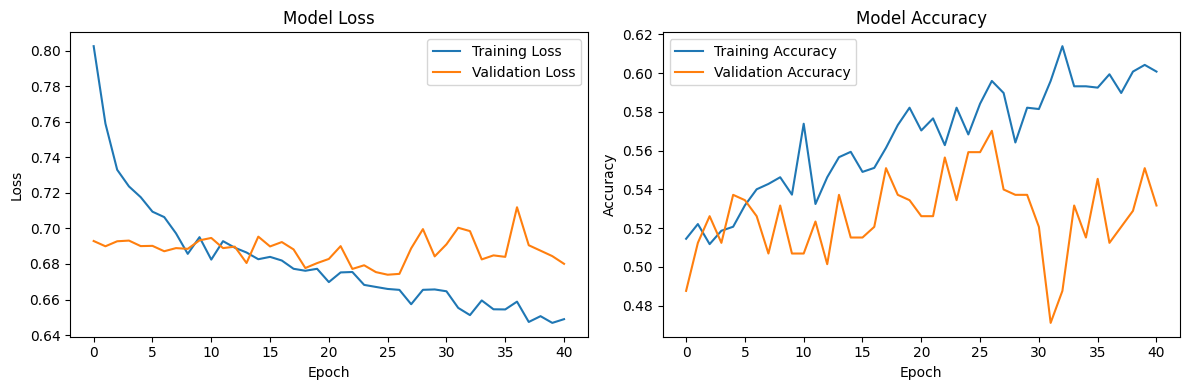


Final evaluation:
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.5526 - auc: 0.5431 - loss: 0.7014 - precision: 0.5410 - recall: 0.6921
Metrics Dictionary: {'loss': 0.69219571352005, 'compile_metrics': 0.5474613904953003}
Manually calculated accuracy: 0.5475

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.40      0.47       227
           1       0.54      0.70      0.61       226

    accuracy                           0.55       453
   macro avg       0.55      0.55      0.54       453
weighted avg       0.55      0.55      0.54       453


Test Metrics Summary:
Test loss: 0.6922
Test compile_metrics: 0.5475
Test accuracy: 0.5475


In [11]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import os
from tensorflow import keras


class EyebrowDeepfakeDetector:
    def __init__(self, model_type='lstm', input_shape=(56,7), num_classes=1):
        self.model_type = model_type
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()
        self.scaler = StandardScaler()

    def _build_model(self):
        """Build and compile the model based on specified architecture type"""
        if self.model_type == 'lstm':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'gru':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'cnn':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling1D(2),
                tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.GlobalAveragePooling1D(),
                tf.keras.layers.Dense(64, activation='relu'),
                tf.keras.layers.Dropout(0.3),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'transformer':
            inputs = tf.keras.Input(shape=self.input_shape)
            pos_encoding = self._positional_encoding(self.input_shape[0], self.input_shape[1])
            x = inputs + pos_encoding[:, :self.input_shape[0], :]
            
            # Transformer block
            x = tf.keras.layers.MultiHeadAttention(
                num_heads=4, key_dim=self.input_shape[1])(x, x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Feed forward network
            x = tf.keras.layers.Dense(128, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Classification head
            x = tf.keras.layers.GlobalAveragePooling1D()(x)
            x = tf.keras.layers.Dense(64, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.2)(x)
            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
            
            model = tf.keras.Model(inputs=inputs, outputs=outputs)
        elif self.model_type=="model-1":
            inputs = tf.keras.Input(shape=(56,7,1))
    
            # Spatial Feature Extraction
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'))(inputs)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)
            
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)
            
            # Temporal Processing
            x = tf.keras.layers.LSTM(256, return_sequences=True)(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.LSTM(128)(x)
            x = tf.keras.layers.Dropout(0.2)(x)
            
            # Classification
            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
            
            model = tf.keras.models.Model(inputs=inputs, outputs=outputs)
        elif self.model_type=="model-2":
            inputs = tf.keras.Input(shape=self.input_shape)  # (75,6)

            # Expand dims if needed
            x = tf.keras.layers.Lambda(lambda x: tf.expand_dims(x, axis=-1))(inputs) # (75,6,1)

            # --- CNN Feature Extraction ---
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)

            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)

            # Flatten across spatial dimensions
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)  # shape: (75, features)

            # --- Transformer Encoder ---
            def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
                # Normalization and Attention
                x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(inputs)
                x = tf.keras.layers.MultiHeadAttention(
                    key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
                x = tf.keras.layers.Dropout(dropout)(x)
                res = x + inputs

                # Feed Forward
                x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(res)
                x = tf.keras.layers.Dense(ff_dim, activation='relu')(x)
                x = tf.keras.layers.Dropout(dropout)(x)
                x = tf.keras.layers.Dense(inputs.shape[-1])(x)
                return x + res

            # Apply Transformer Blocks
            x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)
            x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)

            x = tf.keras.layers.GlobalAveragePooling1D()(x)

            # --- Classification Head ---
            x = tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
            x = tf.keras.layers.Dropout(0.2)(x)

            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

            model = tf.keras.models.Model(inputs, outputs)

        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
            
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss='binary_crossentropy',
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ]
        )
        return model

    def _positional_encoding(self, max_length=56, d_model=7):
        """Generate positional encoding for transformer"""
        positions = np.arange(max_length)[:, np.newaxis]
        depths = np.arange(d_model)[np.newaxis, :]/d_model
        
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.zeros(angle_rads.shape)
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        
        return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

    def load_data(self, csv_path):
        """Load and reshape eyebrow movement data"""
        df = pd.read_csv(csv_path, header=None)
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(np.int32)
        
        # Reshape to (samples, 75, 3)
        if X.shape[1] == 392:  # Verify input dimensions
            X = X.reshape(-1, 56, 7)
        return X, y

    def preprocess_data(self, X, y, test_size=0.2):
        """Standardize features and split data"""
        # Stratified train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=42)
        
        # Feature-wise standardization
        orig_shape = X_train.shape
        self.scaler.fit(X_train.reshape(-1, 7))
        X_train = self.scaler.transform(X_train.reshape(-1, 7)).reshape(orig_shape)
        X_test = self.scaler.transform(X_test.reshape(-1, 7)).reshape(X_test.shape)
        
        return X_train, X_test, y_train, y_test

    def train(self, X_train, y_train, X_val, y_val, epochs=200):
        """Train model with early stopping and checkpointing"""
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(
                f'best_{self.model_type}_model.keras', save_best_only=True)
        ]
        
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=64,
            callbacks=callbacks,
            verbose=2
        )

        # Print final training metrics
        print("\nFinal Training Metrics:")
        for metric in history.history:
            if not metric.startswith('val_'):
                print(f"Training {metric}: {history.history[metric][-1]:.4f}")
        
        # Print final validation metrics
        print("\nFinal Validation Metrics:")
        for metric in history.history:
            if metric.startswith('val_'):
                print(f"{metric}: {history.history[metric][-1]:.4f}")

                # Analyze stopping reason
        best_epoch = np.argmin(history.history['val_loss']) + 1
        print(f"Best model found at epoch {best_epoch}")

        # Plot validation metrics trajectory
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.axvline(x=best_epoch-1, color='r', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
        plt.title('Validation Loss Trajectory')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        return history

    def evaluate(self, X_test, y_test):
        """Comprehensive model evaluation"""
        # Quantitative metrics
        results = self.model.evaluate(X_test, y_test, verbose=1)
        metrics = dict(zip(self.model.metrics_names, results))
        
        # Debug: Print the metrics dictionary
        print("Metrics Dictionary:", metrics)
        
        # Qualitative analysis
        y_pred_prob = self.model.predict(X_test,verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        # Calculate and print accuracy directly
        from sklearn.metrics import accuracy_score
        calc_accuracy = accuracy_score(y_test, y_pred)
        print(f"Manually calculated accuracy: {calc_accuracy:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        plt.xticks([0, 1], ['Real', 'Fake'])
        plt.yticks([0, 1], ['Real', 'Fake'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(f'{self.model_type}_confusion_matrix.png')
        plt.close()
        
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.savefig(f'{self.model_type}_roc_curve.png')
        plt.close()
        
        # Ensure accuracy is in the metrics dictionary
        if 'accuracy' not in metrics:
            metrics['accuracy'] = calc_accuracy
        
        return metrics


# Usage example
if __name__ == "__main__":
    # Initialize detector - choose model type
    detector = EyebrowDeepfakeDetector(model_type='lstm', input_shape=(56, 7))
    
    # Load and preprocess data
    X, y = detector.load_data(os.path.join("","comprehensive_features-Face2Face_new.csv"))
    X_train, X_test, y_train, y_test = detector.preprocess_data(X, y)
    
    # Split validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # Train model
    print("Model architecture:")
    detector.model.summary()
    history = detector.train(X_train, y_train, X_val, y_val)
    
        # Plot training history
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{detector.model_type}_training_history.png')
    plt.show()
    plt.close('all')

    # Evaluate
    print("\nFinal evaluation:")
    test_metrics = detector.evaluate(X_test, y_test)

        # Print all metrics in a formatted way
    print("\nTest Metrics Summary:")
    for metric_name, metric_value in test_metrics.items():
        print(f"Test {metric_name}: {metric_value:.4f}")

    # Save final model
    detector.model.save(f'final_{detector.model_type}_model.keras')


Model architecture:


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_6 (Bidirectional) │ (None, 56, 128)        │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 56, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ (None, 56, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,905 (312.13 KB)

 Trainable params: 79,521 (310.63 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/200
23/23 - 7s - 298ms/step - accuracy: 0.4910 - auc: 0.4749 - loss: 0.8478 - precision: 0.4888 - recall: 0.3909 - val_accuracy: 0.5041 - val_auc: 0.5024 - val_loss: 0.6941 - val_precision: 0.5040 - val_recall: 0.6868
Epoch 2/200
23/23 - 2s - 80ms/step - accuracy: 0.5104 - auc: 0.5204 - loss: 0.7613 - precision: 0.5117 - recall: 0.4530 - val_accuracy: 0.5041 - val_auc: 0.4874 - val_loss: 0.6957 - val_precision: 0.5033 - val_recall: 0.8407
Epoch 3/200
23/23 - 2s - 79ms/step - accuracy: 0.5221 - auc: 0.5413 - loss: 0.7359 - precision: 0.5232 - recall: 0.4986 - val_accuracy: 0.5179 - val_auc: 0.5075 - val_loss: 0.6965 - val_precision: 0.5113 - val_recall: 0.8736
Epoch 4/200
23/23 - 2s - 80ms/step - accuracy: 0.5276 - auc: 0.5276 - loss: 0.7327 - precision: 0.5284 - recall: 0.5138 - val_accuracy: 0.4986 - val_auc: 0.5003 - val_loss: 0.6954 - val_precision: 0.5000 - val_recall: 0.8242
Epoch 5/200
23/23 - 2s - 79ms/step - accuracy: 0.5318 - auc: 0.5425 - loss: 0.7210 - precision: 0.5

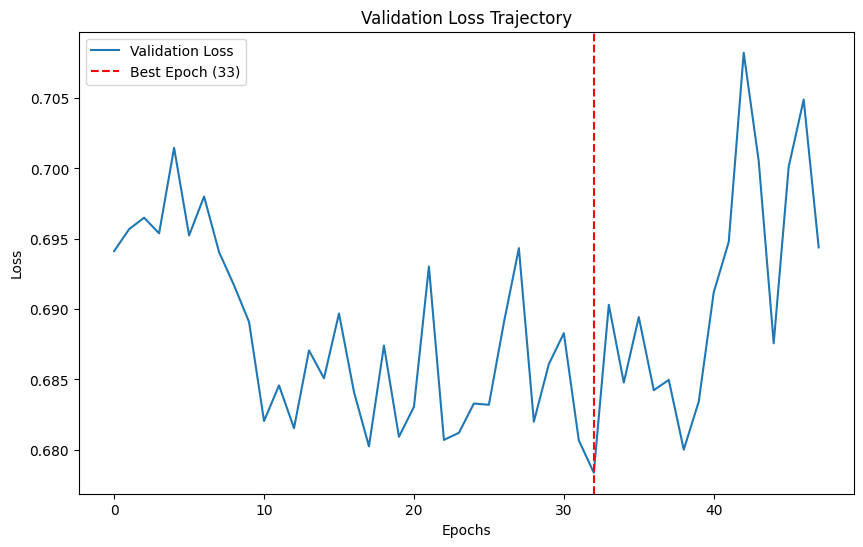

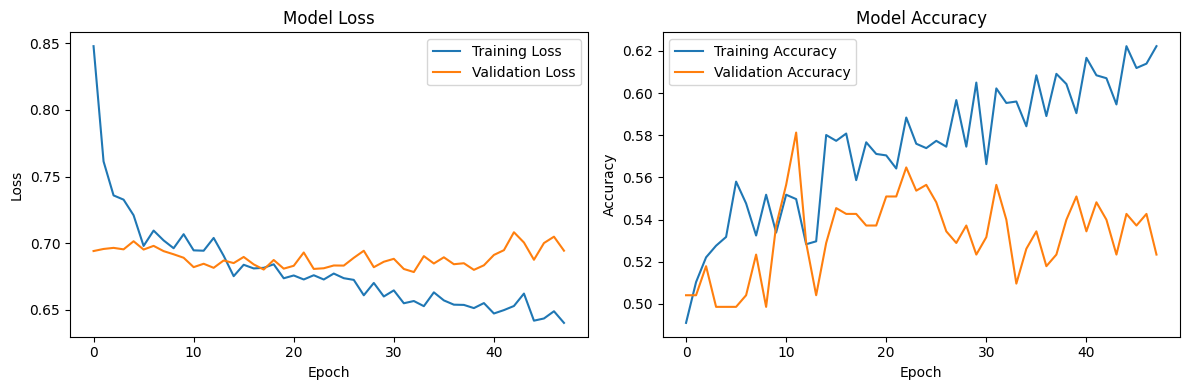


Final evaluation:
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.5340 - auc: 0.5738 - loss: 0.6940 - precision: 0.5282 - recall: 0.6287
Metrics Dictionary: {'loss': 0.6964237689971924, 'compile_metrics': 0.5275937914848328}
Manually calculated accuracy: 0.5276

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.42      0.47       227
           1       0.52      0.64      0.57       226

    accuracy                           0.53       453
   macro avg       0.53      0.53      0.52       453
weighted avg       0.53      0.53      0.52       453


Test Metrics Summary:
Test loss: 0.6964
Test compile_metrics: 0.5276
Test accuracy: 0.5276


In [12]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import os
from tensorflow import keras


class EyebrowDeepfakeDetector:
    def __init__(self, model_type='lstm', input_shape=(56,7), num_classes=1):
        self.model_type = model_type
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()
        self.scaler = StandardScaler()

    def _build_model(self):
        """Build and compile the model based on specified architecture type"""
        if self.model_type == 'lstm':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'gru':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'cnn':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling1D(2),
                tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.GlobalAveragePooling1D(),
                tf.keras.layers.Dense(64, activation='relu'),
                tf.keras.layers.Dropout(0.3),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'transformer':
            inputs = tf.keras.Input(shape=self.input_shape)
            pos_encoding = self._positional_encoding(self.input_shape[0], self.input_shape[1])
            x = inputs + pos_encoding[:, :self.input_shape[0], :]
            
            # Transformer block
            x = tf.keras.layers.MultiHeadAttention(
                num_heads=4, key_dim=self.input_shape[1])(x, x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Feed forward network
            x = tf.keras.layers.Dense(128, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Classification head
            x = tf.keras.layers.GlobalAveragePooling1D()(x)
            x = tf.keras.layers.Dense(64, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.2)(x)
            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
            
            model = tf.keras.Model(inputs=inputs, outputs=outputs)
        elif self.model_type=="model-1":
            inputs = tf.keras.Input(shape=(56,7,1))
    
            # Spatial Feature Extraction
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'))(inputs)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)
            
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)
            
            # Temporal Processing
            x = tf.keras.layers.LSTM(256, return_sequences=True)(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.LSTM(128)(x)
            x = tf.keras.layers.Dropout(0.2)(x)
            
            # Classification
            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
            
            model = tf.keras.models.Model(inputs=inputs, outputs=outputs)
        elif self.model_type=="model-2":
            inputs = tf.keras.Input(shape=self.input_shape)  # (75,6)

            # Expand dims if needed
            x = tf.keras.layers.Lambda(lambda x: tf.expand_dims(x, axis=-1))(inputs) # (75,6,1)

            # --- CNN Feature Extraction ---
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)

            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)

            # Flatten across spatial dimensions
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)  # shape: (75, features)

            # --- Transformer Encoder ---
            def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
                # Normalization and Attention
                x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(inputs)
                x = tf.keras.layers.MultiHeadAttention(
                    key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
                x = tf.keras.layers.Dropout(dropout)(x)
                res = x + inputs

                # Feed Forward
                x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(res)
                x = tf.keras.layers.Dense(ff_dim, activation='relu')(x)
                x = tf.keras.layers.Dropout(dropout)(x)
                x = tf.keras.layers.Dense(inputs.shape[-1])(x)
                return x + res

            # Apply Transformer Blocks
            x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)
            x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)

            x = tf.keras.layers.GlobalAveragePooling1D()(x)

            # --- Classification Head ---
            x = tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
            x = tf.keras.layers.Dropout(0.2)(x)

            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

            model = tf.keras.models.Model(inputs, outputs)

        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
            
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss='binary_crossentropy',
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ]
        )
        return model

    def _positional_encoding(self, max_length=56, d_model=7):
        """Generate positional encoding for transformer"""
        positions = np.arange(max_length)[:, np.newaxis]
        depths = np.arange(d_model)[np.newaxis, :]/d_model
        
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.zeros(angle_rads.shape)
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        
        return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

    def load_data(self, csv_path):
        """Load and reshape eyebrow movement data"""
        df = pd.read_csv(csv_path, header=None)
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(np.int32)
        
        # Reshape to (samples, 75, 3)
        if X.shape[1] == 392:  # Verify input dimensions
            X = X.reshape(-1, 56, 7)
        return X, y

    def preprocess_data(self, X, y, test_size=0.2):
        """Standardize features and split data"""
        # Stratified train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=42)
        
        # Feature-wise standardization
        orig_shape = X_train.shape
        self.scaler.fit(X_train.reshape(-1, 7))
        X_train = self.scaler.transform(X_train.reshape(-1, 7)).reshape(orig_shape)
        X_test = self.scaler.transform(X_test.reshape(-1, 7)).reshape(X_test.shape)
        
        return X_train, X_test, y_train, y_test

    def train(self, X_train, y_train, X_val, y_val, epochs=200):
        """Train model with early stopping and checkpointing"""
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(
                f'best_{self.model_type}_model.keras', save_best_only=True)
        ]
        
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=64,
            callbacks=callbacks,
            verbose=2
        )

        # Print final training metrics
        print("\nFinal Training Metrics:")
        for metric in history.history:
            if not metric.startswith('val_'):
                print(f"Training {metric}: {history.history[metric][-1]:.4f}")
        
        # Print final validation metrics
        print("\nFinal Validation Metrics:")
        for metric in history.history:
            if metric.startswith('val_'):
                print(f"{metric}: {history.history[metric][-1]:.4f}")

                # Analyze stopping reason
        best_epoch = np.argmin(history.history['val_loss']) + 1
        print(f"Best model found at epoch {best_epoch}")

        # Plot validation metrics trajectory
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.axvline(x=best_epoch-1, color='r', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
        plt.title('Validation Loss Trajectory')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        return history

    def evaluate(self, X_test, y_test):
        """Comprehensive model evaluation"""
        # Quantitative metrics
        results = self.model.evaluate(X_test, y_test, verbose=1)
        metrics = dict(zip(self.model.metrics_names, results))
        
        # Debug: Print the metrics dictionary
        print("Metrics Dictionary:", metrics)
        
        # Qualitative analysis
        y_pred_prob = self.model.predict(X_test,verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        # Calculate and print accuracy directly
        from sklearn.metrics import accuracy_score
        calc_accuracy = accuracy_score(y_test, y_pred)
        print(f"Manually calculated accuracy: {calc_accuracy:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        plt.xticks([0, 1], ['Real', 'Fake'])
        plt.yticks([0, 1], ['Real', 'Fake'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(f'{self.model_type}_confusion_matrix.png')
        plt.close()
        
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.savefig(f'{self.model_type}_roc_curve.png')
        plt.close()
        
        # Ensure accuracy is in the metrics dictionary
        if 'accuracy' not in metrics:
            metrics['accuracy'] = calc_accuracy
        
        return metrics


# Usage example
if __name__ == "__main__":
    # Initialize detector - choose model type
    detector = EyebrowDeepfakeDetector(model_type='lstm', input_shape=(56, 7))
    
    # Load and preprocess data
    X, y = detector.load_data(os.path.join("","comprehensive_features-Face2Face_new.csv"))
    X_train, X_test, y_train, y_test = detector.preprocess_data(X, y)
    
    # Split validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # Train model
    print("Model architecture:")
    detector.model.summary()
    history = detector.train(X_train, y_train, X_val, y_val)
    
        # Plot training history
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{detector.model_type}_training_history.png')
    plt.show()
    plt.close('all')

    # Evaluate
    print("\nFinal evaluation:")
    test_metrics = detector.evaluate(X_test, y_test)

        # Print all metrics in a formatted way
    print("\nTest Metrics Summary:")
    for metric_name, metric_value in test_metrics.items():
        print(f"Test {metric_name}: {metric_value:.4f}")

    # Save final model
    detector.model.save(f'final_{detector.model_type}_model.keras')


Model architecture:


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_16 (Conv1D)              │ (None, 56, 64)         │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 56, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_12 (MaxPooling1D) │ (None, 28, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_17 (Conv1D)              │ (None, 28, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 28, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_7      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,201 (137.50 KB)

 Trainable params: 34,817 (136.00 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/200
21/21 - 3s - 120ms/step - accuracy: 0.5160 - auc: 0.5238 - loss: 0.7433 - precision: 0.4521 - recall: 0.3776 - val_accuracy: 0.5502 - val_auc: 0.5735 - val_loss: 0.6933 - val_precision: 0.5000 - val_recall: 0.6824
Epoch 2/200
21/21 - 1s - 25ms/step - accuracy: 0.5640 - auc: 0.5845 - loss: 0.6970 - precision: 0.5153 - recall: 0.4575 - val_accuracy: 0.5623 - val_auc: 0.6183 - val_loss: 0.6794 - val_precision: 0.5286 - val_recall: 0.2500
Epoch 3/200
21/21 - 0s - 18ms/step - accuracy: 0.5602 - auc: 0.5848 - loss: 0.6967 - precision: 0.5090 - recall: 0.5272 - val_accuracy: 0.5532 - val_auc: 0.5963 - val_loss: 0.6744 - val_precision: 0.5088 - val_recall: 0.1959
Epoch 4/200
21/21 - 0s - 16ms/step - accuracy: 0.5823 - auc: 0.6141 - loss: 0.6789 - precision: 0.5394 - recall: 0.4660 - val_accuracy: 0.5441 - val_auc: 0.5956 - val_loss: 0.6793 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/200
21/21 - 0s - 23ms/step - accuracy: 0.5998 - auc: 0.6432 - loss: 0.6623 - precis

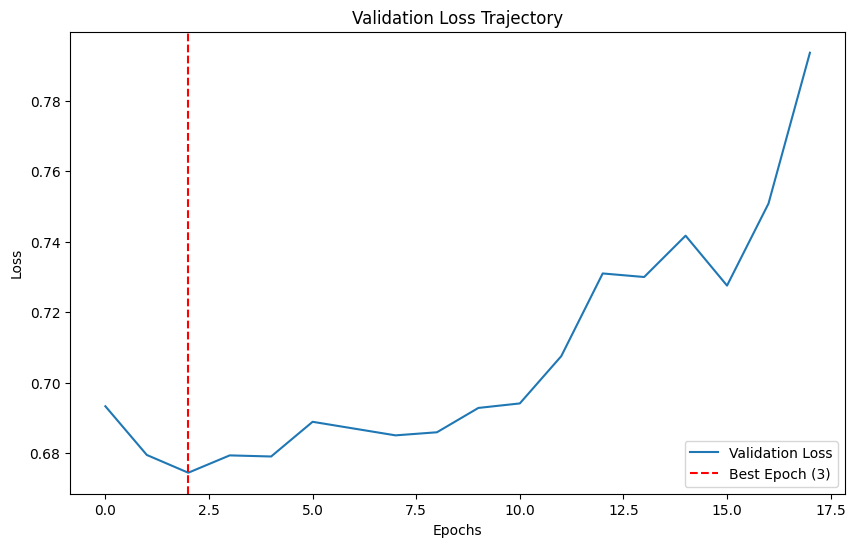

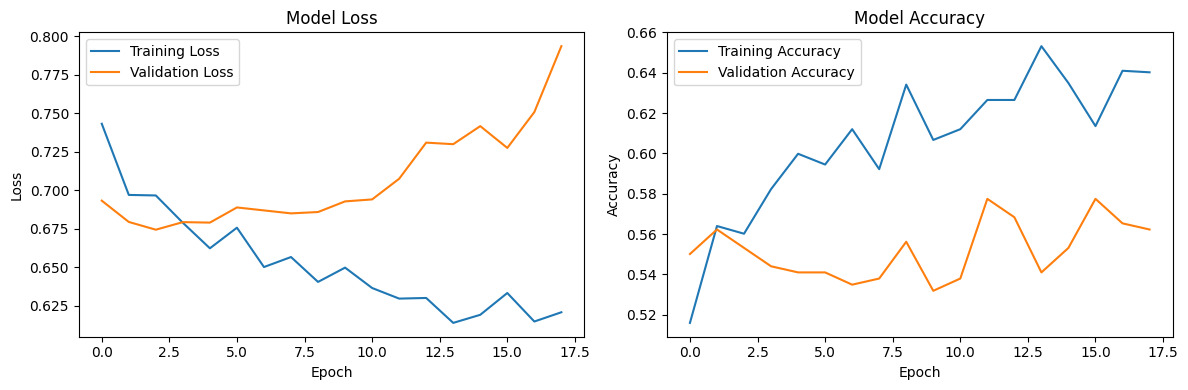


Final evaluation:
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5324 - auc: 0.5654 - loss: 0.6835 - precision: 0.5029 - recall: 0.2077
Metrics Dictionary: {'loss': 0.6816006898880005, 'compile_metrics': 0.5450121760368347}
Manually calculated accuracy: 0.5450

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.81      0.66       227
           1       0.48      0.22      0.30       184

    accuracy                           0.55       411
   macro avg       0.52      0.51      0.48       411
weighted avg       0.53      0.55      0.50       411


Test Metrics Summary:
Test loss: 0.6816
Test compile_metrics: 0.5450
Test accuracy: 0.5450


In [13]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import os
from tensorflow import keras


class EyebrowDeepfakeDetector:
    def __init__(self, model_type='lstm', input_shape=(56,7), num_classes=1):
        self.model_type = model_type
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()
        self.scaler = StandardScaler()

    def _build_model(self):
        """Build and compile the model based on specified architecture type"""
        if self.model_type == 'lstm':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'gru':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'cnn':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling1D(2),
                tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.GlobalAveragePooling1D(),
                tf.keras.layers.Dense(64, activation='relu'),
                tf.keras.layers.Dropout(0.3),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'transformer':
            inputs = tf.keras.Input(shape=self.input_shape)
            pos_encoding = self._positional_encoding(self.input_shape[0], self.input_shape[1])
            x = inputs + pos_encoding[:, :self.input_shape[0], :]
            
            # Transformer block
            x = tf.keras.layers.MultiHeadAttention(
                num_heads=4, key_dim=self.input_shape[1])(x, x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Feed forward network
            x = tf.keras.layers.Dense(128, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Classification head
            x = tf.keras.layers.GlobalAveragePooling1D()(x)
            x = tf.keras.layers.Dense(64, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.2)(x)
            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
            
            model = tf.keras.Model(inputs=inputs, outputs=outputs)
        elif self.model_type=="model-1":
            inputs = tf.keras.Input(shape=(56,7,1))
    
            # Spatial Feature Extraction
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'))(inputs)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)
            
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)
            
            # Temporal Processing
            x = tf.keras.layers.LSTM(256, return_sequences=True)(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.LSTM(128)(x)
            x = tf.keras.layers.Dropout(0.2)(x)
            
            # Classification
            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
            
            model = tf.keras.models.Model(inputs=inputs, outputs=outputs)
        elif self.model_type=="model-2":
            inputs = tf.keras.Input(shape=self.input_shape)  # (75,6)

            # Expand dims if needed
            x = tf.keras.layers.Lambda(lambda x: tf.expand_dims(x, axis=-1))(inputs) # (75,6,1)

            # --- CNN Feature Extraction ---
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)

            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)

            # Flatten across spatial dimensions
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)  # shape: (75, features)

            # --- Transformer Encoder ---
            def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
                # Normalization and Attention
                x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(inputs)
                x = tf.keras.layers.MultiHeadAttention(
                    key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
                x = tf.keras.layers.Dropout(dropout)(x)
                res = x + inputs

                # Feed Forward
                x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(res)
                x = tf.keras.layers.Dense(ff_dim, activation='relu')(x)
                x = tf.keras.layers.Dropout(dropout)(x)
                x = tf.keras.layers.Dense(inputs.shape[-1])(x)
                return x + res

            # Apply Transformer Blocks
            x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)
            x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)

            x = tf.keras.layers.GlobalAveragePooling1D()(x)

            # --- Classification Head ---
            x = tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
            x = tf.keras.layers.Dropout(0.2)(x)

            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

            model = tf.keras.models.Model(inputs, outputs)

        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
            
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss='binary_crossentropy',
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ]
        )
        return model

    def _positional_encoding(self, max_length=56, d_model=7):
        """Generate positional encoding for transformer"""
        positions = np.arange(max_length)[:, np.newaxis]
        depths = np.arange(d_model)[np.newaxis, :]/d_model
        
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.zeros(angle_rads.shape)
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        
        return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

    def load_data(self, csv_path):
        """Load and reshape eyebrow movement data"""
        df = pd.read_csv(csv_path, header=None)
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(np.int32)
        
        # Reshape to (samples, 75, 3)
        if X.shape[1] == 392:  # Verify input dimensions
            X = X.reshape(-1, 56, 7)
        return X, y

    def preprocess_data(self, X, y, test_size=0.2):
        """Standardize features and split data"""
        # Stratified train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=42)
        
        # Feature-wise standardization
        orig_shape = X_train.shape
        self.scaler.fit(X_train.reshape(-1, 7))
        X_train = self.scaler.transform(X_train.reshape(-1, 7)).reshape(orig_shape)
        X_test = self.scaler.transform(X_test.reshape(-1, 7)).reshape(X_test.shape)
        
        return X_train, X_test, y_train, y_test

    def train(self, X_train, y_train, X_val, y_val, epochs=200):
        """Train model with early stopping and checkpointing"""
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(
                f'best_{self.model_type}_model.keras', save_best_only=True)
        ]
        
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=64,
            callbacks=callbacks,
            verbose=2
        )

        # Print final training metrics
        print("\nFinal Training Metrics:")
        for metric in history.history:
            if not metric.startswith('val_'):
                print(f"Training {metric}: {history.history[metric][-1]:.4f}")
        
        # Print final validation metrics
        print("\nFinal Validation Metrics:")
        for metric in history.history:
            if metric.startswith('val_'):
                print(f"{metric}: {history.history[metric][-1]:.4f}")

                # Analyze stopping reason
        best_epoch = np.argmin(history.history['val_loss']) + 1
        print(f"Best model found at epoch {best_epoch}")

        # Plot validation metrics trajectory
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.axvline(x=best_epoch-1, color='r', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
        plt.title('Validation Loss Trajectory')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        return history

    def evaluate(self, X_test, y_test):
        """Comprehensive model evaluation"""
        # Quantitative metrics
        results = self.model.evaluate(X_test, y_test, verbose=1)
        metrics = dict(zip(self.model.metrics_names, results))
        
        # Debug: Print the metrics dictionary
        print("Metrics Dictionary:", metrics)
        
        # Qualitative analysis
        y_pred_prob = self.model.predict(X_test,verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        # Calculate and print accuracy directly
        from sklearn.metrics import accuracy_score
        calc_accuracy = accuracy_score(y_test, y_pred)
        print(f"Manually calculated accuracy: {calc_accuracy:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        plt.xticks([0, 1], ['Real', 'Fake'])
        plt.yticks([0, 1], ['Real', 'Fake'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(f'{self.model_type}_confusion_matrix.png')
        plt.close()
        
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.savefig(f'{self.model_type}_roc_curve.png')
        plt.close()
        
        # Ensure accuracy is in the metrics dictionary
        if 'accuracy' not in metrics:
            metrics['accuracy'] = calc_accuracy
        
        return metrics


# Usage example
if __name__ == "__main__":
    # Initialize detector - choose model type
    detector = EyebrowDeepfakeDetector(model_type='cnn', input_shape=(56, 7))
    
    # Load and preprocess data
    X, y = detector.load_data(os.path.join("","comprehensive_features-FaceSwap_new.csv"))
    X_train, X_test, y_train, y_test = detector.preprocess_data(X, y)
    
    # Split validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # Train model
    print("Model architecture:")
    detector.model.summary()
    history = detector.train(X_train, y_train, X_val, y_val)
    
        # Plot training history
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{detector.model_type}_training_history.png')
    plt.show()
    plt.close('all')

    # Evaluate
    print("\nFinal evaluation:")
    test_metrics = detector.evaluate(X_test, y_test)

        # Print all metrics in a formatted way
    print("\nTest Metrics Summary:")
    for metric_name, metric_value in test_metrics.items():
        print(f"Test {metric_name}: {metric_value:.4f}")

    # Save final model
    detector.model.save(f'final_{detector.model_type}_model.keras')


Model architecture:


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_8 (Bidirectional) │ (None, 56, 128)        │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 56, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_4             │ (None, 56, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_9 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,905 (312.13 KB)

 Trainable params: 79,521 (310.63 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/200
23/23 - 8s - 352ms/step - accuracy: 0.4910 - auc: 0.4664 - loss: 0.9583 - precision: 0.4950 - recall: 0.8964 - val_accuracy: 0.4821 - val_auc: 0.4718 - val_loss: 0.6957 - val_precision: 0.4865 - val_recall: 0.5934
Epoch 2/200
23/23 - 2s - 103ms/step - accuracy: 0.5290 - auc: 0.5553 - loss: 0.7421 - precision: 0.5193 - recall: 0.7790 - val_accuracy: 0.4986 - val_auc: 0.5288 - val_loss: 0.6935 - val_precision: 0.5000 - val_recall: 0.0549
Epoch 3/200
23/23 - 3s - 109ms/step - accuracy: 0.5207 - auc: 0.5291 - loss: 0.7275 - precision: 0.5189 - recall: 0.5677 - val_accuracy: 0.5234 - val_auc: 0.5453 - val_loss: 0.6940 - val_precision: 0.6452 - val_recall: 0.1099
Epoch 4/200
23/23 - 3s - 112ms/step - accuracy: 0.5055 - auc: 0.5163 - loss: 0.7302 - precision: 0.5050 - recall: 0.5608 - val_accuracy: 0.5289 - val_auc: 0.5583 - val_loss: 0.6929 - val_precision: 0.7619 - val_recall: 0.0879
Epoch 5/200
23/23 - 3s - 110ms/step - accuracy: 0.5262 - auc: 0.5354 - loss: 0.7165 - precision:

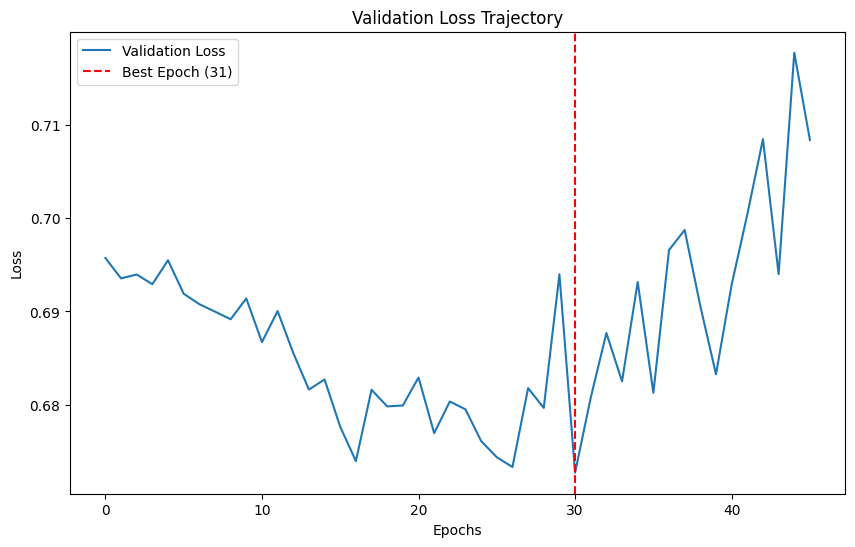

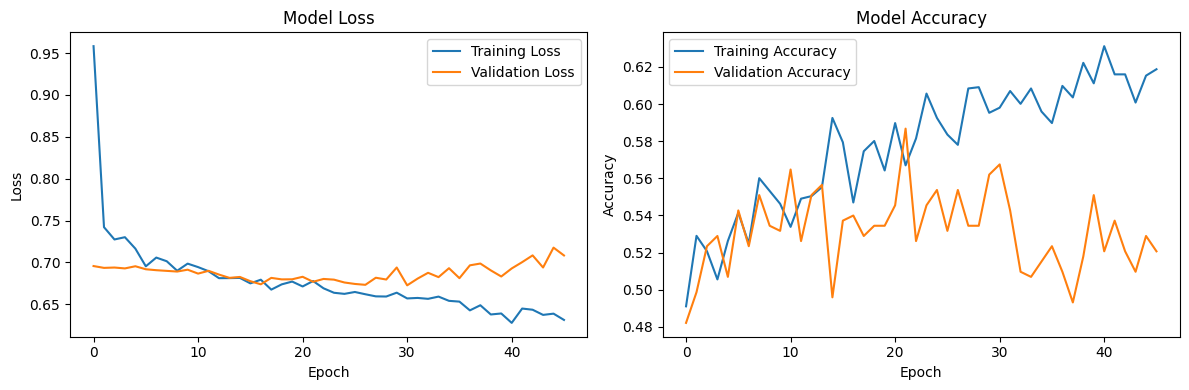


Final evaluation:
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.5302 - auc: 0.5539 - loss: 0.7021 - precision: 0.5353 - recall: 0.4660
Metrics Dictionary: {'loss': 0.7002929449081421, 'compile_metrics': 0.5320088267326355}
Manually calculated accuracy: 0.5320

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.58      0.55       227
           1       0.53      0.48      0.51       226

    accuracy                           0.53       453
   macro avg       0.53      0.53      0.53       453
weighted avg       0.53      0.53      0.53       453


Test Metrics Summary:
Test loss: 0.7003
Test compile_metrics: 0.5320
Test accuracy: 0.5320


In [14]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import os
from tensorflow import keras


class EyebrowDeepfakeDetector:
    def __init__(self, model_type='lstm', input_shape=(56,7), num_classes=1):
        self.model_type = model_type
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()
        self.scaler = StandardScaler()

    def _build_model(self):
        """Build and compile the model based on specified architecture type"""
        if self.model_type == 'lstm':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'gru':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'cnn':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling1D(2),
                tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.GlobalAveragePooling1D(),
                tf.keras.layers.Dense(64, activation='relu'),
                tf.keras.layers.Dropout(0.3),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'transformer':
            inputs = tf.keras.Input(shape=self.input_shape)
            pos_encoding = self._positional_encoding(self.input_shape[0], self.input_shape[1])
            x = inputs + pos_encoding[:, :self.input_shape[0], :]
            
            # Transformer block
            x = tf.keras.layers.MultiHeadAttention(
                num_heads=4, key_dim=self.input_shape[1])(x, x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Feed forward network
            x = tf.keras.layers.Dense(128, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Classification head
            x = tf.keras.layers.GlobalAveragePooling1D()(x)
            x = tf.keras.layers.Dense(64, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.2)(x)
            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
            
            model = tf.keras.Model(inputs=inputs, outputs=outputs)
        elif self.model_type=="model-1":
            inputs = tf.keras.Input(shape=(56,7,1))
    
            # Spatial Feature Extraction
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'))(inputs)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)
            
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)
            
            # Temporal Processing
            x = tf.keras.layers.LSTM(256, return_sequences=True)(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.LSTM(128)(x)
            x = tf.keras.layers.Dropout(0.2)(x)
            
            # Classification
            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
            
            model = tf.keras.models.Model(inputs=inputs, outputs=outputs)
        elif self.model_type=="model-2":
            inputs = tf.keras.Input(shape=self.input_shape)  # (75,6)

            # Expand dims if needed
            x = tf.keras.layers.Lambda(lambda x: tf.expand_dims(x, axis=-1))(inputs) # (75,6,1)

            # --- CNN Feature Extraction ---
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)

            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)

            # Flatten across spatial dimensions
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)  # shape: (75, features)

            # --- Transformer Encoder ---
            def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
                # Normalization and Attention
                x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(inputs)
                x = tf.keras.layers.MultiHeadAttention(
                    key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
                x = tf.keras.layers.Dropout(dropout)(x)
                res = x + inputs

                # Feed Forward
                x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(res)
                x = tf.keras.layers.Dense(ff_dim, activation='relu')(x)
                x = tf.keras.layers.Dropout(dropout)(x)
                x = tf.keras.layers.Dense(inputs.shape[-1])(x)
                return x + res

            # Apply Transformer Blocks
            x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)
            x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)

            x = tf.keras.layers.GlobalAveragePooling1D()(x)

            # --- Classification Head ---
            x = tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
            x = tf.keras.layers.Dropout(0.2)(x)

            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

            model = tf.keras.models.Model(inputs, outputs)

        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
            
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss='binary_crossentropy',
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ]
        )
        return model

    def _positional_encoding(self, max_length=56, d_model=7):
        """Generate positional encoding for transformer"""
        positions = np.arange(max_length)[:, np.newaxis]
        depths = np.arange(d_model)[np.newaxis, :]/d_model
        
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.zeros(angle_rads.shape)
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        
        return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

    def load_data(self, csv_path):
        """Load and reshape eyebrow movement data"""
        df = pd.read_csv(csv_path, header=None)
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(np.int32)
        
        # Reshape to (samples, 75, 3)
        if X.shape[1] == 392:  # Verify input dimensions
            X = X.reshape(-1, 56, 7)
        return X, y

    def preprocess_data(self, X, y, test_size=0.2):
        """Standardize features and split data"""
        # Stratified train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=42)
        
        # Feature-wise standardization
        orig_shape = X_train.shape
        self.scaler.fit(X_train.reshape(-1, 7))
        X_train = self.scaler.transform(X_train.reshape(-1, 7)).reshape(orig_shape)
        X_test = self.scaler.transform(X_test.reshape(-1, 7)).reshape(X_test.shape)
        
        return X_train, X_test, y_train, y_test

    def train(self, X_train, y_train, X_val, y_val, epochs=200):
        """Train model with early stopping and checkpointing"""
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(
                f'best_{self.model_type}_model.keras', save_best_only=True)
        ]
        
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=64,
            callbacks=callbacks,
            verbose=2
        )

        # Print final training metrics
        print("\nFinal Training Metrics:")
        for metric in history.history:
            if not metric.startswith('val_'):
                print(f"Training {metric}: {history.history[metric][-1]:.4f}")
        
        # Print final validation metrics
        print("\nFinal Validation Metrics:")
        for metric in history.history:
            if metric.startswith('val_'):
                print(f"{metric}: {history.history[metric][-1]:.4f}")

                # Analyze stopping reason
        best_epoch = np.argmin(history.history['val_loss']) + 1
        print(f"Best model found at epoch {best_epoch}")

        # Plot validation metrics trajectory
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.axvline(x=best_epoch-1, color='r', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
        plt.title('Validation Loss Trajectory')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        return history

    def evaluate(self, X_test, y_test):
        """Comprehensive model evaluation"""
        # Quantitative metrics
        results = self.model.evaluate(X_test, y_test, verbose=1)
        metrics = dict(zip(self.model.metrics_names, results))
        
        # Debug: Print the metrics dictionary
        print("Metrics Dictionary:", metrics)
        
        # Qualitative analysis
        y_pred_prob = self.model.predict(X_test,verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        # Calculate and print accuracy directly
        from sklearn.metrics import accuracy_score
        calc_accuracy = accuracy_score(y_test, y_pred)
        print(f"Manually calculated accuracy: {calc_accuracy:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        plt.xticks([0, 1], ['Real', 'Fake'])
        plt.yticks([0, 1], ['Real', 'Fake'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(f'{self.model_type}_confusion_matrix.png')
        plt.close()
        
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.savefig(f'{self.model_type}_roc_curve.png')
        plt.close()
        
        # Ensure accuracy is in the metrics dictionary
        if 'accuracy' not in metrics:
            metrics['accuracy'] = calc_accuracy
        
        return metrics


# Usage example
if __name__ == "__main__":
    # Initialize detector - choose model type
    detector = EyebrowDeepfakeDetector(model_type='lstm', input_shape=(56, 7))
    
    # Load and preprocess data
    X, y = detector.load_data(os.path.join("","comprehensive_features-Face2Face_new.csv"))
    X_train, X_test, y_train, y_test = detector.preprocess_data(X, y)
    
    # Split validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # Train model
    print("Model architecture:")
    detector.model.summary()
    history = detector.train(X_train, y_train, X_val, y_val)
    
        # Plot training history
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{detector.model_type}_training_history.png')
    plt.show()
    plt.close('all')

    # Evaluate
    print("\nFinal evaluation:")
    test_metrics = detector.evaluate(X_test, y_test)

        # Print all metrics in a formatted way
    print("\nTest Metrics Summary:")
    for metric_name, metric_value in test_metrics.items():
        print(f"Test {metric_name}: {metric_value:.4f}")

    # Save final model
    detector.model.save(f'final_{detector.model_type}_model.keras')


Model architecture:


Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 56, 7, 1)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_28             │ (None, 56, 7, 64)      │           256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_29             │ (None, 56, 7, 64)      │           256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_30             │ (None, 56, 3, 64)      │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_31             │ (None, 56, 3, 128)     │        24,704 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_32             │ (None, 56, 3, 128)     │           512 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_33             │ (None, 56, 1, 128)     │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_34             │ (None, 56, 128)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_12 (LSTM)                  │ (None, 56, 256)        │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 56, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 617,217 (2.35 MB)

 Trainable params: 616,833 (2.35 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/200
27/27 - 45s - 2s/step - accuracy: 0.5996 - auc: 0.6348 - loss: 0.6644 - precision: 0.6285 - recall: 0.7120 - val_accuracy: 0.6283 - val_auc: 0.6907 - val_loss: 0.6204 - val_precision: 0.6957 - val_recall: 0.6102
Epoch 2/200
27/27 - 16s - 585ms/step - accuracy: 0.6399 - auc: 0.6939 - loss: 0.6247 - precision: 0.6619 - recall: 0.7407 - val_accuracy: 0.6307 - val_auc: 0.6730 - val_loss: 0.6356 - val_precision: 0.6640 - val_recall: 0.7034
Epoch 3/200
27/27 - 16s - 589ms/step - accuracy: 0.6579 - auc: 0.7199 - loss: 0.6083 - precision: 0.6768 - recall: 0.7545 - val_accuracy: 0.6787 - val_auc: 0.7293 - val_loss: 0.6145 - val_precision: 0.7339 - val_recall: 0.6780
Epoch 4/200
27/27 - 16s - 583ms/step - accuracy: 0.6495 - auc: 0.7205 - loss: 0.6071 - precision: 0.6584 - recall: 0.7885 - val_accuracy: 0.6619 - val_auc: 0.7231 - val_loss: 0.6125 - val_precision: 0.7149 - val_recall: 0.6695
Epoch 5/200
27/27 - 16s - 586ms/step - accuracy: 0.6849 - auc: 0.7497 - loss: 0.5855 - precisio

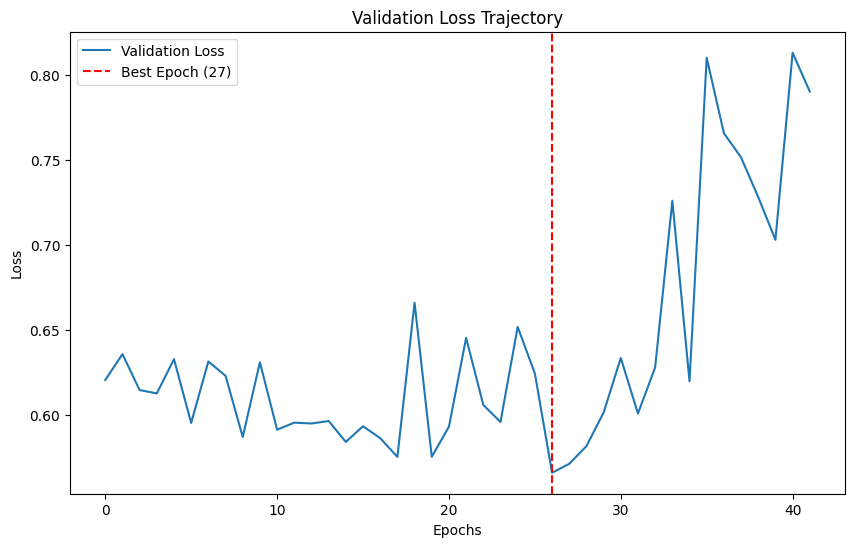

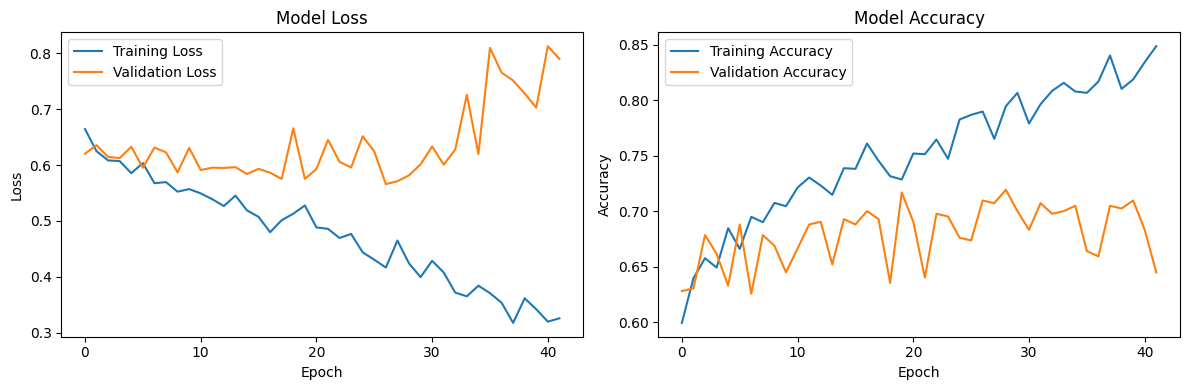


Final evaluation:
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.7358 - auc: 0.7773 - loss: 0.6107 - precision: 0.7605 - recall: 0.7739
Metrics Dictionary: {'loss': 0.5910130739212036, 'compile_metrics': 0.7428023219108582}
Manually calculated accuracy: 0.7428

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.68      0.70       226
           1       0.76      0.79      0.78       295

    accuracy                           0.74       521
   macro avg       0.74      0.74      0.74       521
weighted avg       0.74      0.74      0.74       521


Test Metrics Summary:
Test loss: 0.5910
Test compile_metrics: 0.7428
Test accuracy: 0.7428


In [15]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import os
from tensorflow import keras


class EyebrowDeepfakeDetector:
    def __init__(self, model_type='lstm', input_shape=(56,7), num_classes=1):
        self.model_type = model_type
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()
        self.scaler = StandardScaler()

    def _build_model(self):
        """Build and compile the model based on specified architecture type"""
        if self.model_type == 'lstm':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'gru':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'cnn':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling1D(2),
                tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.GlobalAveragePooling1D(),
                tf.keras.layers.Dense(64, activation='relu'),
                tf.keras.layers.Dropout(0.3),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'transformer':
            inputs = tf.keras.Input(shape=self.input_shape)
            pos_encoding = self._positional_encoding(self.input_shape[0], self.input_shape[1])
            x = inputs + pos_encoding[:, :self.input_shape[0], :]
            
            # Transformer block
            x = tf.keras.layers.MultiHeadAttention(
                num_heads=4, key_dim=self.input_shape[1])(x, x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Feed forward network
            x = tf.keras.layers.Dense(128, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Classification head
            x = tf.keras.layers.GlobalAveragePooling1D()(x)
            x = tf.keras.layers.Dense(64, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.2)(x)
            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
            
            model = tf.keras.Model(inputs=inputs, outputs=outputs)
        elif self.model_type=="model-1":
            inputs = tf.keras.Input(shape=(56,7,1))
    
            # Spatial Feature Extraction
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'))(inputs)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)
            
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)
            
            # Temporal Processing
            x = tf.keras.layers.LSTM(256, return_sequences=True)(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.LSTM(128)(x)
            x = tf.keras.layers.Dropout(0.2)(x)
            
            # Classification
            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
            
            model = tf.keras.models.Model(inputs=inputs, outputs=outputs)
        elif self.model_type=="model-2":
            inputs = tf.keras.Input(shape=self.input_shape)  # (75,6)

            # Expand dims if needed
            x = tf.keras.layers.Lambda(lambda x: tf.expand_dims(x, axis=-1))(inputs) # (75,6,1)

            # --- CNN Feature Extraction ---
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)

            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)

            # Flatten across spatial dimensions
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)  # shape: (75, features)

            # --- Transformer Encoder ---
            def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
                # Normalization and Attention
                x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(inputs)
                x = tf.keras.layers.MultiHeadAttention(
                    key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
                x = tf.keras.layers.Dropout(dropout)(x)
                res = x + inputs

                # Feed Forward
                x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(res)
                x = tf.keras.layers.Dense(ff_dim, activation='relu')(x)
                x = tf.keras.layers.Dropout(dropout)(x)
                x = tf.keras.layers.Dense(inputs.shape[-1])(x)
                return x + res

            # Apply Transformer Blocks
            x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)
            x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)

            x = tf.keras.layers.GlobalAveragePooling1D()(x)

            # --- Classification Head ---
            x = tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
            x = tf.keras.layers.Dropout(0.2)(x)

            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

            model = tf.keras.models.Model(inputs, outputs)

        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
            
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss='binary_crossentropy',
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ]
        )
        return model

    def _positional_encoding(self, max_length=56, d_model=7):
        """Generate positional encoding for transformer"""
        positions = np.arange(max_length)[:, np.newaxis]
        depths = np.arange(d_model)[np.newaxis, :]/d_model
        
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.zeros(angle_rads.shape)
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        
        return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

    def load_data(self, csv_path):
        """Load and reshape eyebrow movement data"""
        df = pd.read_csv(csv_path, header=None)
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(np.int32)
        
        # Reshape to (samples, 75, 3)
        if X.shape[1] == 392:  # Verify input dimensions
            X = X.reshape(-1, 56, 7)
        return X, y

    def preprocess_data(self, X, y, test_size=0.2):
        """Standardize features and split data"""
        # Stratified train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=42)
        
        # Feature-wise standardization
        orig_shape = X_train.shape
        self.scaler.fit(X_train.reshape(-1, 7))
        X_train = self.scaler.transform(X_train.reshape(-1, 7)).reshape(orig_shape)
        X_test = self.scaler.transform(X_test.reshape(-1, 7)).reshape(X_test.shape)
        
        return X_train, X_test, y_train, y_test

    def train(self, X_train, y_train, X_val, y_val, epochs=200):
        """Train model with early stopping and checkpointing"""
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(
                f'best_{self.model_type}_model.keras', save_best_only=True)
        ]
        
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=64,
            callbacks=callbacks,
            verbose=2
        )

        # Print final training metrics
        print("\nFinal Training Metrics:")
        for metric in history.history:
            if not metric.startswith('val_'):
                print(f"Training {metric}: {history.history[metric][-1]:.4f}")
        
        # Print final validation metrics
        print("\nFinal Validation Metrics:")
        for metric in history.history:
            if metric.startswith('val_'):
                print(f"{metric}: {history.history[metric][-1]:.4f}")

                # Analyze stopping reason
        best_epoch = np.argmin(history.history['val_loss']) + 1
        print(f"Best model found at epoch {best_epoch}")

        # Plot validation metrics trajectory
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.axvline(x=best_epoch-1, color='r', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
        plt.title('Validation Loss Trajectory')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        return history

    def evaluate(self, X_test, y_test):
        """Comprehensive model evaluation"""
        # Quantitative metrics
        results = self.model.evaluate(X_test, y_test, verbose=1)
        metrics = dict(zip(self.model.metrics_names, results))
        
        # Debug: Print the metrics dictionary
        print("Metrics Dictionary:", metrics)
        
        # Qualitative analysis
        y_pred_prob = self.model.predict(X_test,verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        # Calculate and print accuracy directly
        from sklearn.metrics import accuracy_score
        calc_accuracy = accuracy_score(y_test, y_pred)
        print(f"Manually calculated accuracy: {calc_accuracy:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        plt.xticks([0, 1], ['Real', 'Fake'])
        plt.yticks([0, 1], ['Real', 'Fake'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(f'{self.model_type}_confusion_matrix.png')
        plt.close()
        
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.savefig(f'{self.model_type}_roc_curve.png')
        plt.close()
        
        # Ensure accuracy is in the metrics dictionary
        if 'accuracy' not in metrics:
            metrics['accuracy'] = calc_accuracy
        
        return metrics


# Usage example
if __name__ == "__main__":
    # Initialize detector - choose model type
    detector = EyebrowDeepfakeDetector(model_type='model-1', input_shape=(56, 7))
    
    # Load and preprocess data
    X, y = detector.load_data(os.path.join("","comprehensive_features-DeepFakeDetection_new.csv"))
    X_train, X_test, y_train, y_test = detector.preprocess_data(X, y)
    
    # Split validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # Train model
    print("Model architecture:")
    detector.model.summary()
    history = detector.train(X_train, y_train, X_val, y_val)
    
        # Plot training history
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{detector.model_type}_training_history.png')
    plt.show()
    plt.close('all')

    # Evaluate
    print("\nFinal evaluation:")
    test_metrics = detector.evaluate(X_test, y_test)

        # Print all metrics in a formatted way
    print("\nTest Metrics Summary:")
    for metric_name, metric_value in test_metrics.items():
        print(f"Test {metric_name}: {metric_value:.4f}")

    # Save final model
    detector.model.save(f'final_{detector.model_type}_model.keras')


Model architecture:


Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 56, 7)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 56, 7, 1)  │          0 │ input_layer_15[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_35 │ (None, 56, 7, 64) │        256 │ lambda_3[0][0]    │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_36 │ (None, 56, 7, 64) │        256 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_37 │ (None, 56, 3, 64) │          0 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_38 │ (None, 56, 3,     │     24,704 │ time_distributed… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_39 │ (None, 56, 3,     │        512 │ time_distributed… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_40 │ (None, 56, 1,     │          0 │ time_distributed… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_41 │ (None, 56, 128)   │          0 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 56, 128)   │        256 │ time_distributed… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 56, 128)   │    131,968 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_39          │ (None, 56, 128)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 56, 128)   │          0 │ dropout_39[0][0], │
│                     │                   │            │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 56, 128)   │        256 │ add_12[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_43 (Dense)    │ (None, 56, 128)   │     16,512 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_40          │ (None, 56, 128)   │          0 │ dense_43[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_44 (Dense)    │ (None, 56, 128)   │     16,512 │ dropout_40[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_13 (Add)        │ (None, 56, 128)   │          0 │ dense_44[0][0], 

 Total params: 381,569 (1.46 MB)

 Trainable params: 381,185 (1.45 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/200
27/27 - 45s - 2s/step - accuracy: 0.5900 - auc: 0.6240 - loss: 2.6151 - precision: 0.6314 - recall: 0.6589 - val_accuracy: 0.6283 - val_auc: 0.6752 - val_loss: 2.3269 - val_precision: 0.6202 - val_recall: 0.8856
Epoch 2/200
27/27 - 14s - 515ms/step - accuracy: 0.6303 - auc: 0.6829 - loss: 2.1751 - precision: 0.6677 - recall: 0.6876 - val_accuracy: 0.6427 - val_auc: 0.7266 - val_loss: 1.9853 - val_precision: 0.6390 - val_recall: 0.8475
Epoch 3/200
27/27 - 14s - 509ms/step - accuracy: 0.6471 - auc: 0.6942 - loss: 1.8612 - precision: 0.6695 - recall: 0.7407 - val_accuracy: 0.6403 - val_auc: 0.7118 - val_loss: 1.7346 - val_precision: 0.6414 - val_recall: 0.8263
Epoch 4/200
27/27 - 14s - 522ms/step - accuracy: 0.6597 - auc: 0.7104 - loss: 1.6185 - precision: 0.6848 - recall: 0.7365 - val_accuracy: 0.6115 - val_auc: 0.7139 - val_loss: 1.5193 - val_precision: 0.6069 - val_recall: 0.8898
Epoch 5/200
27/27 - 14s - 523ms/step - accuracy: 0.6825 - auc: 0.7507 - loss: 1.3962 - precisio

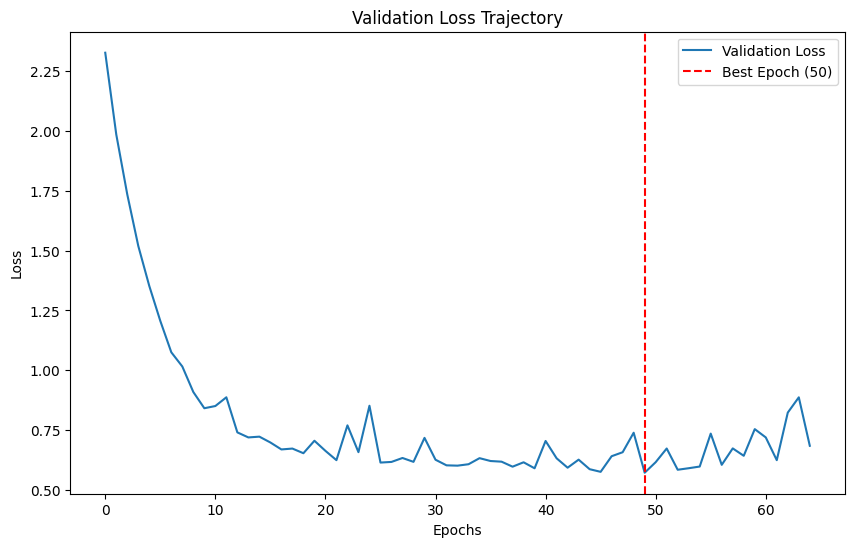

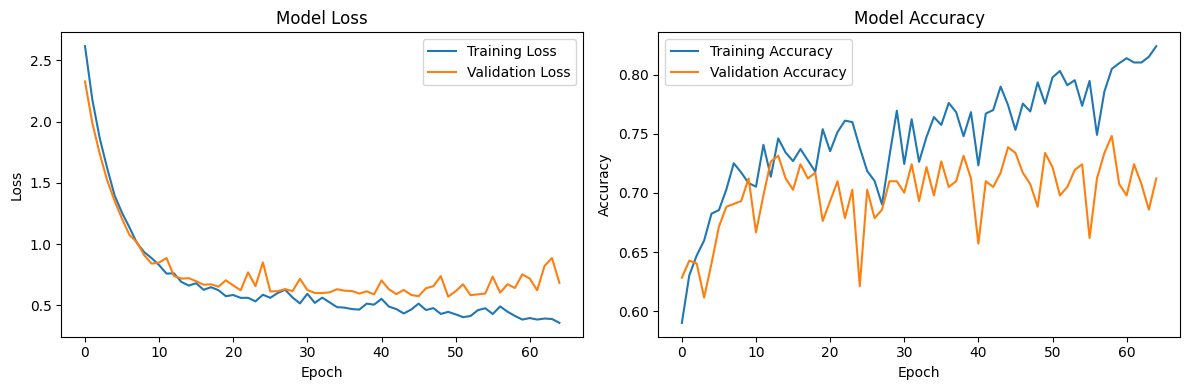


Final evaluation:
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.7004 - auc: 0.7725 - loss: 0.6495 - precision: 0.7076 - recall: 0.7945
Metrics Dictionary: {'loss': 0.6109488606452942, 'compile_metrics': 0.7024952173233032}
Manually calculated accuracy: 0.7025

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.58      0.63       226
           1       0.71      0.80      0.75       295

    accuracy                           0.70       521
   macro avg       0.70      0.69      0.69       521
weighted avg       0.70      0.70      0.70       521


Test Metrics Summary:
Test loss: 0.6109
Test compile_metrics: 0.7025
Test accuracy: 0.7025


In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import os
from tensorflow import keras


class EyebrowDeepfakeDetector:
    def __init__(self, model_type='lstm', input_shape=(56,7), num_classes=1):
        self.model_type = model_type
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()
        self.scaler = StandardScaler()

    def _build_model(self):
        """Build and compile the model based on specified architecture type"""
        if self.model_type == 'lstm':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'gru':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'cnn':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling1D(2),
                tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.GlobalAveragePooling1D(),
                tf.keras.layers.Dense(64, activation='relu'),
                tf.keras.layers.Dropout(0.3),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'transformer':
            inputs = tf.keras.Input(shape=self.input_shape)
            pos_encoding = self._positional_encoding(self.input_shape[0], self.input_shape[1])
            x = inputs + pos_encoding[:, :self.input_shape[0], :]
            
            # Transformer block
            x = tf.keras.layers.MultiHeadAttention(
                num_heads=4, key_dim=self.input_shape[1])(x, x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Feed forward network
            x = tf.keras.layers.Dense(128, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Classification head
            x = tf.keras.layers.GlobalAveragePooling1D()(x)
            x = tf.keras.layers.Dense(64, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.2)(x)
            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
            
            model = tf.keras.Model(inputs=inputs, outputs=outputs)
        elif self.model_type=="model-1":
            inputs = tf.keras.Input(shape=(56,7,1))
    
            # Spatial Feature Extraction
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'))(inputs)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)
            
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)
            
            # Temporal Processing
            x = tf.keras.layers.LSTM(256, return_sequences=True)(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.LSTM(128)(x)
            x = tf.keras.layers.Dropout(0.2)(x)
            
            # Classification
            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
            
            model = tf.keras.models.Model(inputs=inputs, outputs=outputs)
        elif self.model_type=="model-2":
            inputs = tf.keras.Input(shape=self.input_shape)  # (75,6)

            # Expand dims if needed
            x = tf.keras.layers.Lambda(lambda x: tf.expand_dims(x, axis=-1))(inputs) # (75,6,1)

            # --- CNN Feature Extraction ---
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)

            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)

            # Flatten across spatial dimensions
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)  # shape: (75, features)

            # --- Transformer Encoder ---
            def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
                # Normalization and Attention
                x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(inputs)
                x = tf.keras.layers.MultiHeadAttention(
                    key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
                x = tf.keras.layers.Dropout(dropout)(x)
                res = x + inputs

                # Feed Forward
                x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(res)
                x = tf.keras.layers.Dense(ff_dim, activation='relu')(x)
                x = tf.keras.layers.Dropout(dropout)(x)
                x = tf.keras.layers.Dense(inputs.shape[-1])(x)
                return x + res

            # Apply Transformer Blocks
            x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)
            x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)

            x = tf.keras.layers.GlobalAveragePooling1D()(x)

            # --- Classification Head ---
            x = tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
            x = tf.keras.layers.Dropout(0.2)(x)

            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

            model = tf.keras.models.Model(inputs, outputs)

        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
            
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss='binary_crossentropy',
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ]
        )
        return model

    def _positional_encoding(self, max_length=56, d_model=7):
        """Generate positional encoding for transformer"""
        positions = np.arange(max_length)[:, np.newaxis]
        depths = np.arange(d_model)[np.newaxis, :]/d_model
        
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.zeros(angle_rads.shape)
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        
        return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

    def load_data(self, csv_path):
        """Load and reshape eyebrow movement data"""
        df = pd.read_csv(csv_path, header=None)
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(np.int32)
        
        # Reshape to (samples, 75, 3)
        if X.shape[1] == 392:  # Verify input dimensions
            X = X.reshape(-1, 56, 7)
        return X, y

    def preprocess_data(self, X, y, test_size=0.2):
        """Standardize features and split data"""
        # Stratified train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=42)
        
        # Feature-wise standardization
        orig_shape = X_train.shape
        self.scaler.fit(X_train.reshape(-1, 7))
        X_train = self.scaler.transform(X_train.reshape(-1, 7)).reshape(orig_shape)
        X_test = self.scaler.transform(X_test.reshape(-1, 7)).reshape(X_test.shape)
        
        return X_train, X_test, y_train, y_test

    def train(self, X_train, y_train, X_val, y_val, epochs=200):
        """Train model with early stopping and checkpointing"""
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(
                f'best_{self.model_type}_model.keras', save_best_only=True)
        ]
        
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=64,
            callbacks=callbacks,
            verbose=2
        )

        # Print final training metrics
        print("\nFinal Training Metrics:")
        for metric in history.history:
            if not metric.startswith('val_'):
                print(f"Training {metric}: {history.history[metric][-1]:.4f}")
        
        # Print final validation metrics
        print("\nFinal Validation Metrics:")
        for metric in history.history:
            if metric.startswith('val_'):
                print(f"{metric}: {history.history[metric][-1]:.4f}")

                # Analyze stopping reason
        best_epoch = np.argmin(history.history['val_loss']) + 1
        print(f"Best model found at epoch {best_epoch}")

        # Plot validation metrics trajectory
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.axvline(x=best_epoch-1, color='r', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
        plt.title('Validation Loss Trajectory')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        return history

    def evaluate(self, X_test, y_test):
        """Comprehensive model evaluation"""
        # Quantitative metrics
        results = self.model.evaluate(X_test, y_test, verbose=1)
        metrics = dict(zip(self.model.metrics_names, results))
        
        # Debug: Print the metrics dictionary
        print("Metrics Dictionary:", metrics)
        
        # Qualitative analysis
        y_pred_prob = self.model.predict(X_test,verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        # Calculate and print accuracy directly
        from sklearn.metrics import accuracy_score
        calc_accuracy = accuracy_score(y_test, y_pred)
        print(f"Manually calculated accuracy: {calc_accuracy:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        plt.xticks([0, 1], ['Real', 'Fake'])
        plt.yticks([0, 1], ['Real', 'Fake'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(f'{self.model_type}_confusion_matrix.png')
        plt.close()
        
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.savefig(f'{self.model_type}_roc_curve.png')
        plt.close()
        
        # Ensure accuracy is in the metrics dictionary
        if 'accuracy' not in metrics:
            metrics['accuracy'] = calc_accuracy
        
        return metrics


# Usage example
if __name__ == "__main__":
    # Initialize detector - choose model type
    detector = EyebrowDeepfakeDetector(model_type='model-2', input_shape=(56, 7))
    
    # Load and preprocess data
    X, y = detector.load_data(os.path.join("","comprehensive_features-DeepFakeDetection_new.csv"))
    X_train, X_test, y_train, y_test = detector.preprocess_data(X, y)
    
    # Split validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # Train model
    print("Model architecture:")
    detector.model.summary()
    history = detector.train(X_train, y_train, X_val, y_val)
    
        # Plot training history
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{detector.model_type}_training_history.png')
    plt.show()
    plt.close('all')

    # Evaluate
    print("\nFinal evaluation:")
    test_metrics = detector.evaluate(X_test, y_test)

        # Print all metrics in a formatted way
    print("\nTest Metrics Summary:")
    for metric_name, metric_value in test_metrics.items():
        print(f"Test {metric_name}: {metric_value:.4f}")

    # Save final model
    detector.model.save(f'final_{detector.model_type}_model.keras')



Model architecture:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 56, 7)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 56, 7, 1)  │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 56, 7, 64) │        256 │ lambda[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 56, 7, 64) │        256 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_2  │ (None, 56, 3, 64) │          0 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_3  │ (None, 56, 3,     │     24,704 │ time_distributed… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_4  │ (None, 56, 3,     │        512 │ time_distributed… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_5  │ (None, 56, 1,     │          0 │ time_distributed… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_6  │ (None, 56, 128)   │          0 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 56, 128)   │        256 │ time_distributed… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 56, 128)   │    131,968 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 56, 128)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 128)   │          0 │ dropout_1[0][0],  │
│                     │                   │            │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 56, 128)   │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 56, 128)   │     16,512 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 56, 128)   │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 56, 128)   │     16,512 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 56, 128)   │          0 │ dense_1[0][0],    │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 381,569 (1.46 MB)

 Trainable params: 381,185 (1.45 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/200
14/14 - 47s - 3s/step - accuracy: 0.5888 - auc: 0.6025 - loss: 0.7548 - precision: 0.6290 - recall: 0.6631 - val_accuracy: 0.6211 - val_auc: 0.6807 - val_loss: 0.6464 - val_precision: 0.6266 - val_recall: 0.8178
Epoch 2/200
14/14 - 9s - 616ms/step - accuracy: 0.6236 - auc: 0.6556 - loss: 0.6857 - precision: 0.6507 - recall: 0.7205 - val_accuracy: 0.6547 - val_auc: 0.7117 - val_loss: 0.6349 - val_precision: 0.6729 - val_recall: 0.7585
Epoch 3/200
14/14 - 9s - 608ms/step - accuracy: 0.6429 - auc: 0.6888 - loss: 0.6636 - precision: 0.6787 - recall: 0.6982 - val_accuracy: 0.6283 - val_auc: 0.7143 - val_loss: 0.6744 - val_precision: 0.6110 - val_recall: 0.9449
Epoch 4/200
14/14 - 9s - 625ms/step - accuracy: 0.6134 - auc: 0.6618 - loss: 0.6724 - precision: 0.6571 - recall: 0.6599 - val_accuracy: 0.6307 - val_auc: 0.7220 - val_loss: 0.6355 - val_precision: 0.6235 - val_recall: 0.8771
Epoch 5/200
14/14 - 8s - 599ms/step - accuracy: 0.6423 - auc: 0.6786 - loss: 0.6657 - precision: 0

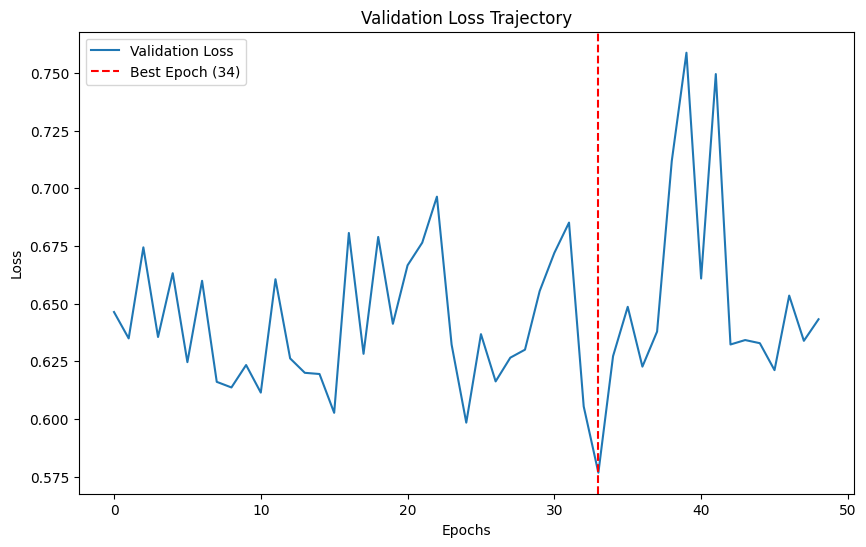

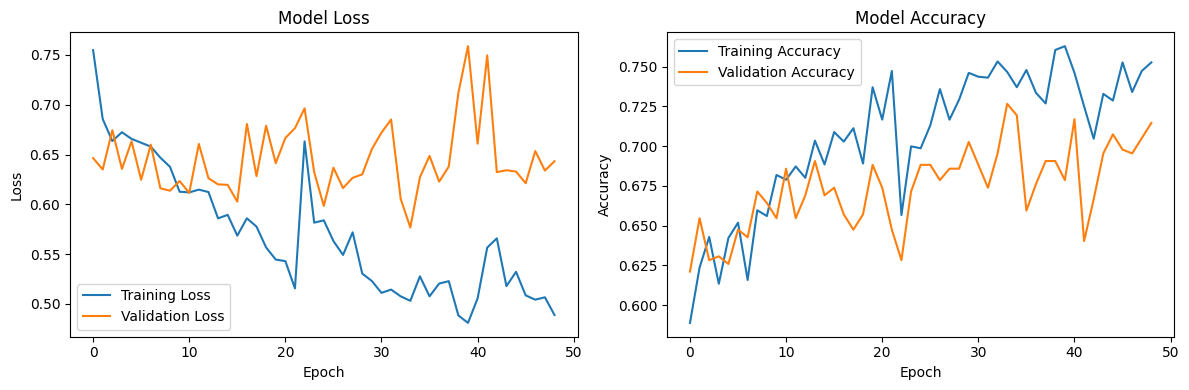


Final evaluation:
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7055 - auc: 0.8068 - loss: 0.5728 - precision: 0.7266 - recall: 0.7625
Metrics Dictionary: {'loss': 0.5782232284545898, 'compile_metrics': 0.6890594959259033}
Manually calculated accuracy: 0.6891

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.62      0.63       226
           1       0.72      0.74      0.73       295

    accuracy                           0.69       521
   macro avg       0.68      0.68      0.68       521
weighted avg       0.69      0.69      0.69       521


Test Metrics Summary:
Test loss: 0.5782
Test compile_metrics: 0.6891
Test accuracy: 0.6891


In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import os
from tensorflow import keras


class EyebrowDeepfakeDetector:
    def __init__(self, model_type='lstm', input_shape=(56,7), num_classes=1):
        self.model_type = model_type
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()
        self.scaler = StandardScaler()

    def _build_model(self):
        """Build and compile the model based on specified architecture type"""
        if self.model_type == 'lstm':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'gru':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'cnn':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling1D(2),
                tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.GlobalAveragePooling1D(),
                tf.keras.layers.Dense(64, activation='relu'),
                tf.keras.layers.Dropout(0.3),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'transformer':
            inputs = tf.keras.Input(shape=self.input_shape)
            pos_encoding = self._positional_encoding(self.input_shape[0], self.input_shape[1])
            x = inputs + pos_encoding[:, :self.input_shape[0], :]
            
            # Transformer block
            x = tf.keras.layers.MultiHeadAttention(
                num_heads=4, key_dim=self.input_shape[1])(x, x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Feed forward network
            x = tf.keras.layers.Dense(128, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Classification head
            x = tf.keras.layers.GlobalAveragePooling1D()(x)
            x = tf.keras.layers.Dense(64, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.2)(x)
            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
            
            model = tf.keras.Model(inputs=inputs, outputs=outputs)
        elif self.model_type=="model-1":
            inputs = tf.keras.Input(shape=(56,7,1))
    
            # Spatial Feature Extraction
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'))(inputs)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)
            
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)
            
            # Temporal Processing
            x = tf.keras.layers.LSTM(256, return_sequences=True)(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.LSTM(128)(x)
            x = tf.keras.layers.Dropout(0.2)(x)
            
            # Classification
            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
            
            model = tf.keras.models.Model(inputs=inputs, outputs=outputs)
        elif self.model_type=="model-2":
            inputs = tf.keras.Input(shape=self.input_shape)  # (75,6)

            # Expand dims if needed
            x = tf.keras.layers.Lambda(lambda x: tf.expand_dims(x, axis=-1))(inputs) # (75,6,1)

            # --- CNN Feature Extraction ---
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)

            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)

            # Flatten across spatial dimensions
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)  # shape: (75, features)

            # --- Transformer Encoder ---
            def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
                # Normalization and Attention
                x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(inputs)
                x = tf.keras.layers.MultiHeadAttention(
                    key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
                x = tf.keras.layers.Dropout(dropout)(x)
                res = x + inputs

                # Feed Forward
                x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(res)
                x = tf.keras.layers.Dense(ff_dim, activation='relu')(x)
                x = tf.keras.layers.Dropout(dropout)(x)
                x = tf.keras.layers.Dense(inputs.shape[-1])(x)
                return x + res

            # Apply Transformer Blocks
            x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)
            x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)

            x = tf.keras.layers.GlobalAveragePooling1D()(x)

            # --- Classification Head ---
            x = tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
            x = tf.keras.layers.Dropout(0.2)(x)

            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

            model = tf.keras.models.Model(inputs, outputs)

        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
            
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss='binary_crossentropy',
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ]
        )
        return model

    def _positional_encoding(self, max_length=56, d_model=7):
        """Generate positional encoding for transformer"""
        positions = np.arange(max_length)[:, np.newaxis]
        depths = np.arange(d_model)[np.newaxis, :]/d_model
        
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.zeros(angle_rads.shape)
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        
        return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

    def load_data(self, csv_path):
        """Load and reshape eyebrow movement data"""
        df = pd.read_csv(csv_path, header=None)
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(np.int32)
        
        # Reshape to (samples, 75, 3)
        if X.shape[1] == 392:  # Verify input dimensions
            X = X.reshape(-1, 56, 7)
        return X, y

    def preprocess_data(self, X, y, test_size=0.2):
        """Standardize features and split data"""
        # Stratified train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=42)
        
        # Feature-wise standardization
        orig_shape = X_train.shape
        self.scaler.fit(X_train.reshape(-1, 7))
        X_train = self.scaler.transform(X_train.reshape(-1, 7)).reshape(orig_shape)
        X_test = self.scaler.transform(X_test.reshape(-1, 7)).reshape(X_test.shape)
        
        return X_train, X_test, y_train, y_test

    def train(self, X_train, y_train, X_val, y_val, epochs=200):
        """Train model with early stopping and checkpointing"""
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(
                f'best_{self.model_type}_model.keras', save_best_only=True)
        ]
        
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=64,
            callbacks=callbacks,
            verbose=2
        )

        # Print final training metrics
        print("\nFinal Training Metrics:")
        for metric in history.history:
            if not metric.startswith('val_'):
                print(f"Training {metric}: {history.history[metric][-1]:.4f}")
        
        # Print final validation metrics
        print("\nFinal Validation Metrics:")
        for metric in history.history:
            if metric.startswith('val_'):
                print(f"{metric}: {history.history[metric][-1]:.4f}")

                # Analyze stopping reason
        best_epoch = np.argmin(history.history['val_loss']) + 1
        print(f"Best model found at epoch {best_epoch}")

        # Plot validation metrics trajectory
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.axvline(x=best_epoch-1, color='r', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
        plt.title('Validation Loss Trajectory')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        return history

    def evaluate(self, X_test, y_test):
        """Comprehensive model evaluation"""
        # Quantitative metrics
        results = self.model.evaluate(X_test, y_test, verbose=1)
        metrics = dict(zip(self.model.metrics_names, results))
        
        # Debug: Print the metrics dictionary
        print("Metrics Dictionary:", metrics)
        
        # Qualitative analysis
        y_pred_prob = self.model.predict(X_test,verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        # Calculate and print accuracy directly
        from sklearn.metrics import accuracy_score
        calc_accuracy = accuracy_score(y_test, y_pred)
        print(f"Manually calculated accuracy: {calc_accuracy:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        plt.xticks([0, 1], ['Real', 'Fake'])
        plt.yticks([0, 1], ['Real', 'Fake'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(f'{self.model_type}_confusion_matrix.png')
        plt.close()
        
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.savefig(f'{self.model_type}_roc_curve.png')
        plt.close()
        
        # Ensure accuracy is in the metrics dictionary
        if 'accuracy' not in metrics:
            metrics['accuracy'] = calc_accuracy
        
        return metrics


# Usage example
if __name__ == "__main__":
    # Initialize detector - choose model type
    detector = EyebrowDeepfakeDetector(model_type='model-2', input_shape=(56, 7))
    
    # Load and preprocess data
    X, y = detector.load_data(os.path.join("","comprehensive_features-DeepFakeDetection_new.csv"))
    X_train, X_test, y_train, y_test = detector.preprocess_data(X, y)
    
    # Split validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # Train model
    print("Model architecture:")
    detector.model.summary()
    history = detector.train(X_train, y_train, X_val, y_val)
    
        # Plot training history
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{detector.model_type}_training_history.png')
    plt.show()
    plt.close('all')

    # Evaluate
    print("\nFinal evaluation:")
    test_metrics = detector.evaluate(X_test, y_test)

        # Print all metrics in a formatted way
    print("\nTest Metrics Summary:")
    for metric_name, metric_value in test_metrics.items():
        print(f"Test {metric_name}: {metric_value:.4f}")

    # Save final model
    detector.model.save(f'final_{detector.model_type}_model.keras')


Model architecture:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 56, 7)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 56, 7, 1)  │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_9  │ (None, 56, 7, 64) │        256 │ lambda_2[0][0]    │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_10 │ (None, 56, 7, 64) │        256 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ time_distributed… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 64)  │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1, 1, 4)   │        256 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1, 1, 64)  │        256 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 56, 7, 64) │          0 │ time_distributed… │
│                     │                   │            │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_11 │ (None, 56, 3, 64) │          0 │ multiply[0][0]    │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_12 │ (None, 56, 3,     │     24,704 │ time_distributed… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_13 │ (None, 56, 3,     │        512 │ time_distributed… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ time_distributed… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 1, 128) │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1, 1, 8)   │      1,024 │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 1, 1, 128) │      1,024 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 56, 3,     │          0 │ time_distributed… │
│ (Multiply)          │ 128)              │            │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_14 │ (None, 56, 1,     │          0 │ multiply_1[0][0]  │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_15 │ (None, 56, 128)   │          0 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                 

 Total params: 1,051,009 (4.01 MB)

 Trainable params: 1,050,625 (4.01 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/200
27/27 - 47s - 2s/step - accuracy: 0.5798 - loss: 0.7592 - val_accuracy: 0.6211 - val_loss: 0.6917
Epoch 2/200
27/27 - 13s - 464ms/step - accuracy: 0.6182 - loss: 0.7280 - val_accuracy: 0.6307 - val_loss: 0.6820
Epoch 3/200
27/27 - 12s - 462ms/step - accuracy: 0.6218 - loss: 0.7008 - val_accuracy: 0.6595 - val_loss: 0.6762
Epoch 4/200
27/27 - 12s - 457ms/step - accuracy: 0.6303 - loss: 0.6981 - val_accuracy: 0.6499 - val_loss: 0.6806
Epoch 5/200
27/27 - 13s - 465ms/step - accuracy: 0.6573 - loss: 0.6853 - val_accuracy: 0.6547 - val_loss: 0.6759
Epoch 6/200
27/27 - 13s - 468ms/step - accuracy: 0.6573 - loss: 0.6744 - val_accuracy: 0.6571 - val_loss: 0.6720
Epoch 7/200
27/27 - 14s - 510ms/step - accuracy: 0.6525 - loss: 0.6734 - val_accuracy: 0.6475 - val_loss: 0.6717
Epoch 8/200
27/27 - 13s - 468ms/step - accuracy: 0.6597 - loss: 0.6802 - val_accuracy: 0.6475 - val_loss: 0.6679
Epoch 9/200
27/27 - 12s - 455ms/step - accuracy: 0.6705 - loss: 0.6685 - val_accuracy: 0.6547 - val

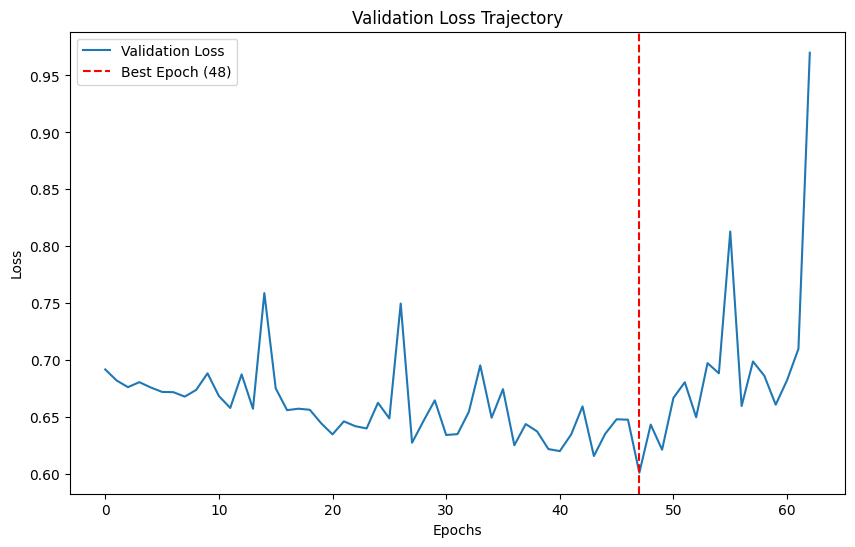

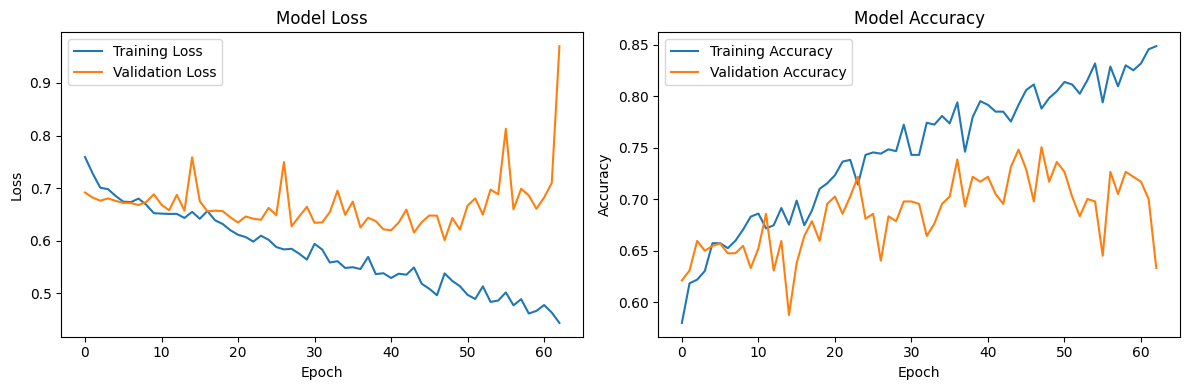


Final evaluation:
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.7185 - loss: 0.6596
Metrics Dictionary: {'loss': 0.6368509531021118, 'compile_metrics': 0.7370441555976868}
Manually calculated accuracy: 0.7370

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.78      0.72       226
           1       0.81      0.70      0.75       295

    accuracy                           0.74       521
   macro avg       0.74      0.74      0.74       521
weighted avg       0.75      0.74      0.74       521


Test Metrics Summary:
Test loss: 0.6369
Test compile_metrics: 0.7370
Test accuracy: 0.7370


In [3]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import os
from tensorflow import keras


class EyebrowDeepfakeDetector:
    def __init__(self, model_type='lstm', input_shape=(56,7), num_classes=1):
        self.model_type = model_type
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()
        self.scaler = StandardScaler()

    def _build_model(self):
        """Build and compile the model based on specified architecture type"""
        if self.model_type == 'lstm':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'gru':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'cnn':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling1D(2),
                tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.GlobalAveragePooling1D(),
                tf.keras.layers.Dense(64, activation='relu'),
                tf.keras.layers.Dropout(0.3),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'transformer':
            inputs = tf.keras.Input(shape=self.input_shape)
            pos_encoding = self._positional_encoding(self.input_shape[0], self.input_shape[1])
            x = inputs + pos_encoding[:, :self.input_shape[0], :]
            
            # Transformer block
            x = tf.keras.layers.MultiHeadAttention(
                num_heads=4, key_dim=self.input_shape[1])(x, x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Feed forward network
            x = tf.keras.layers.Dense(128, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Classification head
            x = tf.keras.layers.GlobalAveragePooling1D()(x)
            x = tf.keras.layers.Dense(64, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.2)(x)
            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
            
            model = tf.keras.Model(inputs=inputs, outputs=outputs)
        elif self.model_type=="model-1":
            inputs = tf.keras.Input(shape=(56,7,1))
    
            # Spatial Feature Extraction
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'))(inputs)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)
            
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)
            
            # Temporal Processing
            x = tf.keras.layers.LSTM(256, return_sequences=True)(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.LSTM(128)(x)
            x = tf.keras.layers.Dropout(0.2)(x)
            
            # Classification
            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
            
            model = tf.keras.models.Model(inputs=inputs, outputs=outputs)
        elif self.model_type=="model-2":
            inputs = tf.keras.Input(shape=self.input_shape)  # (75,6)

            # Expand dims if needed
            x = tf.keras.layers.Lambda(lambda x: tf.expand_dims(x, axis=-1))(inputs) # (75,6,1)

            # --- CNN Feature Extraction ---
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)

            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)

            # Flatten across spatial dimensions
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)  # shape: (75, features)

            # --- Transformer Encoder ---
            def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
                # Normalization and Attention
                x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(inputs)
                x = tf.keras.layers.MultiHeadAttention(
                    key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
                x = tf.keras.layers.Dropout(dropout)(x)
                res = x + inputs

                # Feed Forward
                x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(res)
                x = tf.keras.layers.Dense(ff_dim, activation='relu')(x)
                x = tf.keras.layers.Dropout(dropout)(x)
                x = tf.keras.layers.Dense(inputs.shape[-1])(x)
                return x + res

            # Apply Transformer Blocks
            x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)
            x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)

            x = tf.keras.layers.GlobalAveragePooling1D()(x)

            # --- Classification Head ---
            x = tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
            x = tf.keras.layers.Dropout(0.2)(x)

            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

            model = tf.keras.models.Model(inputs, outputs)

        elif self.model_type=="model-3":
            from keras import layers,models,regularizers
            inputs = tf.keras.Input(shape=self.input_shape)

            def squeeze_excite_block(inputs, ratio=16):
                filters = inputs.shape[-1]
                
                se = layers.GlobalAveragePooling2D()(inputs)  # 🛠 2D pooling for 4D input
                se = layers.Reshape((1, 1, filters))(se)
                se = layers.Dense(filters // ratio, activation='relu', kernel_initializer='he_normal', use_bias=False)(se)
                se = layers.Dense(filters, activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(se)
                x = layers.Multiply()([inputs, se])
                return x

            # Expand dims
            x = layers.Lambda(lambda x: tf.expand_dims(x, axis=-1))(inputs)

            # --- CNN Feature Extractor ---
            x = layers.TimeDistributed(layers.Conv1D(64, 3, activation='relu', padding='same'))(x)
            x = layers.TimeDistributed(layers.BatchNormalization())(x)
            x = squeeze_excite_block(x)
            x = layers.TimeDistributed(layers.MaxPooling1D(2))(x)

            x = layers.TimeDistributed(layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = layers.TimeDistributed(layers.BatchNormalization())(x)
            x = squeeze_excite_block(x)
            x = layers.TimeDistributed(layers.MaxPooling1D(2))(x)

            x = layers.TimeDistributed(layers.Flatten())(x)  # (75, features)

            # --- BiLSTM ---
            x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
            x = layers.LayerNormalization()(x)

            # --- Transformer Block ---
            def transformer_block(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1):
                attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(x, x)
                attn_output = layers.Dropout(dropout)(attn_output)
                x = layers.Add()([x, attn_output])
                x = layers.LayerNormalization()(x)

                ff_output = layers.Dense(ff_dim, activation='relu')(x)
                ff_output = layers.Dense(x.shape[-1])(ff_output)
                ff_output = layers.Dropout(dropout)(ff_output)
                x = layers.Add()([x, ff_output])
                x = layers.LayerNormalization()(x)
                return x

            x = transformer_block(x)
            x = transformer_block(x)

            x = layers.GlobalAveragePooling1D()(x)

            # --- Head ---
            x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
            x = layers.Dropout(0.5)(x)
            x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
            x = layers.Dropout(0.3)(x)

            outputs = layers.Dense(1, activation='sigmoid')(x)

            model = models.Model(inputs, outputs)

            # --- Compile ---
            optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-5)
            model.compile(
                optimizer=optimizer,
                loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
                metrics=['accuracy']
            )

            return model

        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
            
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss='binary_crossentropy',
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ]
        )
        return model

    def _positional_encoding(self, max_length=56, d_model=7):
        """Generate positional encoding for transformer"""
        positions = np.arange(max_length)[:, np.newaxis]
        depths = np.arange(d_model)[np.newaxis, :]/d_model
        
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.zeros(angle_rads.shape)
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        
        return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

    def load_data(self, csv_path):
        """Load and reshape eyebrow movement data"""
        df = pd.read_csv(csv_path, header=None)
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(np.int32)
        
        # Reshape to (samples, 75, 3)
        if X.shape[1] == 392:  # Verify input dimensions
            X = X.reshape(-1, 56, 7)
        return X, y

    def preprocess_data(self, X, y, test_size=0.2):
        """Standardize features and split data"""
        # Stratified train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=42)
        
        # Feature-wise standardization
        orig_shape = X_train.shape
        self.scaler.fit(X_train.reshape(-1, 7))
        X_train = self.scaler.transform(X_train.reshape(-1, 7)).reshape(orig_shape)
        X_test = self.scaler.transform(X_test.reshape(-1, 7)).reshape(X_test.shape)
        
        return X_train, X_test, y_train, y_test

    def train(self, X_train, y_train, X_val, y_val, epochs=200):
        """Train model with early stopping and checkpointing"""
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(
                f'best_{self.model_type}_model.keras', save_best_only=True)
        ]
        
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=64,
            callbacks=callbacks,
            verbose=2
        )

        # Print final training metrics
        print("\nFinal Training Metrics:")
        for metric in history.history:
            if not metric.startswith('val_'):
                print(f"Training {metric}: {history.history[metric][-1]:.4f}")
        
        # Print final validation metrics
        print("\nFinal Validation Metrics:")
        for metric in history.history:
            if metric.startswith('val_'):
                print(f"{metric}: {history.history[metric][-1]:.4f}")

                # Analyze stopping reason
        best_epoch = np.argmin(history.history['val_loss']) + 1
        print(f"Best model found at epoch {best_epoch}")

        # Plot validation metrics trajectory
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.axvline(x=best_epoch-1, color='r', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
        plt.title('Validation Loss Trajectory')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        return history

    def evaluate(self, X_test, y_test):
        """Comprehensive model evaluation"""
        # Quantitative metrics
        results = self.model.evaluate(X_test, y_test, verbose=1)
        metrics = dict(zip(self.model.metrics_names, results))
        
        # Debug: Print the metrics dictionary
        print("Metrics Dictionary:", metrics)
        
        # Qualitative analysis
        y_pred_prob = self.model.predict(X_test,verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        # Calculate and print accuracy directly
        from sklearn.metrics import accuracy_score
        calc_accuracy = accuracy_score(y_test, y_pred)
        print(f"Manually calculated accuracy: {calc_accuracy:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        plt.xticks([0, 1], ['Real', 'Fake'])
        plt.yticks([0, 1], ['Real', 'Fake'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(f'{self.model_type}_confusion_matrix.png')
        plt.close()
        
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.savefig(f'{self.model_type}_roc_curve.png')
        plt.close()
        
        # Ensure accuracy is in the metrics dictionary
        if 'accuracy' not in metrics:
            metrics['accuracy'] = calc_accuracy
        
        return metrics


# Usage example
if __name__ == "__main__":
    # Initialize detector - choose model type
    detector = EyebrowDeepfakeDetector(model_type='model-3', input_shape=(56, 7))
    
    # Load and preprocess data
    X, y = detector.load_data(os.path.join("","comprehensive_features-DeepFakeDetection_new.csv"))
    X_train, X_test, y_train, y_test = detector.preprocess_data(X, y)
    
    # Split validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # Train model
    print("Model architecture:")
    detector.model.summary()
    history = detector.train(X_train, y_train, X_val, y_val)
    
        # Plot training history
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{detector.model_type}_training_history.png')
    plt.show()
    plt.close('all')

    # Evaluate
    print("\nFinal evaluation:")
    test_metrics = detector.evaluate(X_test, y_test)

        # Print all metrics in a formatted way
    print("\nTest Metrics Summary:")
    for metric_name, metric_value in test_metrics.items():
        print(f"Test {metric_name}: {metric_value:.4f}")

    # Save final model
    detector.model.save(f'final_{detector.model_type}_model.keras')


Model architecture:


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 56, 7)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_5 (Lambda)   │ (None, 56, 7, 1)  │          0 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_36 │ (None, 56, 7, 64) │        256 │ lambda_5[0][0]    │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_37 │ (None, 56, 7, 64) │        256 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ time_distributed… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_6 (Reshape) │ (None, 1, 1, 64)  │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_41 (Dense)    │ (None, 1, 1, 4)   │        256 │ reshape_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_42 (Dense)    │ (None, 1, 1, 64)  │        256 │ dense_41[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_6          │ (None, 56, 7, 64) │          0 │ time_distributed… │
│ (Multiply)          │                   │            │ dense_42[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_38 │ (None, 56, 3, 64) │          0 │ multiply_6[0][0]  │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_39 │ (None, 56, 3,     │     24,704 │ time_distributed… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_40 │ (None, 56, 3,     │        512 │ time_distributed… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ time_distributed… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_7 (Reshape) │ (None, 1, 1, 128) │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_43 (Dense)    │ (None, 1, 1, 8)   │      1,024 │ reshape_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_44 (Dense)    │ (None, 1, 1, 128) │      1,024 │ dense_43[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_7          │ (None, 56, 3,     │          0 │ time_distributed… │
│ (Multiply)          │ 128)              │            │ dense_44[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_41 │ (None, 56, 1,     │          0 │ multiply_7[0][0]  │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_42 │ (None, 56, 128)   │          0 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                 

 Total params: 1,051,009 (4.01 MB)

 Trainable params: 1,050,625 (4.01 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/200
23/23 - 77s - 3s/step - accuracy: 0.5373 - auc: 0.5420 - loss: 0.8105 - precision: 0.5352 - recall: 0.5663 - val_accuracy: 0.6556 - val_auc: 0.7028 - val_loss: 0.6891 - val_precision: 0.6301 - val_recall: 0.7582
Epoch 2/200
23/23 - 40s - 2s/step - accuracy: 0.5905 - auc: 0.6292 - loss: 0.7368 - precision: 0.5865 - recall: 0.6133 - val_accuracy: 0.6281 - val_auc: 0.6807 - val_loss: 0.7051 - val_precision: 0.7117 - val_recall: 0.4341
Epoch 3/200
23/23 - 18s - 804ms/step - accuracy: 0.5808 - auc: 0.6191 - loss: 0.7295 - precision: 0.5787 - recall: 0.5939 - val_accuracy: 0.6391 - val_auc: 0.7047 - val_loss: 0.6840 - val_precision: 0.6058 - val_recall: 0.8022
Epoch 4/200
23/23 - 34s - 1s/step - accuracy: 0.6008 - auc: 0.6465 - loss: 0.7176 - precision: 0.5955 - recall: 0.6285 - val_accuracy: 0.6281 - val_auc: 0.7170 - val_loss: 0.6793 - val_precision: 0.6478 - val_recall: 0.5659
Epoch 5/200
23/23 - 19s - 847ms/step - accuracy: 0.6008 - auc: 0.6560 - loss: 0.7093 - precision: 0.6

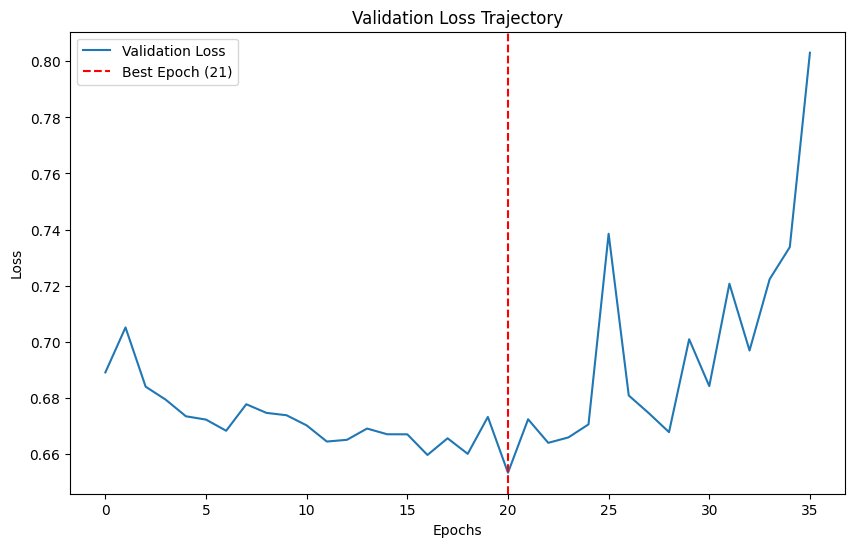

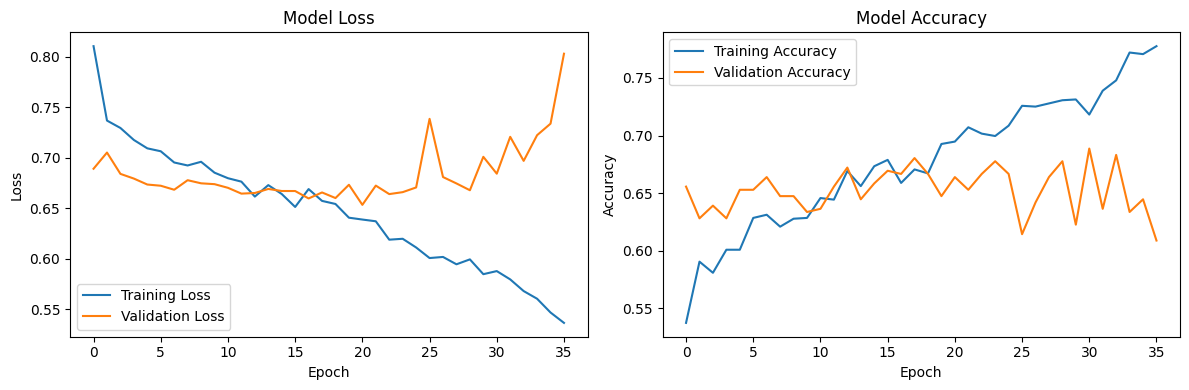


Final evaluation:
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accuracy: 0.6473 - auc: 0.7186 - loss: 0.6809 - precision: 0.6722 - recall: 0.5757
Metrics Dictionary: {'loss': 0.6790948510169983, 'compile_metrics': 0.6600441336631775}
Manually calculated accuracy: 0.6600

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.71      0.68       227
           1       0.68      0.61      0.64       226

    accuracy                           0.66       453
   macro avg       0.66      0.66      0.66       453
weighted avg       0.66      0.66      0.66       453


Test Metrics Summary:
Test loss: 0.6791
Test compile_metrics: 0.6600
Test accuracy: 0.6600


In [8]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import os
from tensorflow import keras


class EyebrowDeepfakeDetector:
    def __init__(self, model_type='lstm', input_shape=(56,7), num_classes=1):
        self.model_type = model_type
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()
        self.scaler = StandardScaler()

    def _build_model(self):
        """Build and compile the model based on specified architecture type"""
        if self.model_type == 'lstm':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'gru':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.GRU(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'cnn':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling1D(2),
                tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.GlobalAveragePooling1D(),
                tf.keras.layers.Dense(64, activation='relu'),
                tf.keras.layers.Dropout(0.3),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
        elif self.model_type == 'transformer':
            inputs = tf.keras.Input(shape=self.input_shape)
            pos_encoding = self._positional_encoding(self.input_shape[0], self.input_shape[1])
            x = inputs + pos_encoding[:, :self.input_shape[0], :]
            
            # Transformer block
            x = tf.keras.layers.MultiHeadAttention(
                num_heads=4, key_dim=self.input_shape[1])(x, x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Feed forward network
            x = tf.keras.layers.Dense(128, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
            
            # Classification head
            x = tf.keras.layers.GlobalAveragePooling1D()(x)
            x = tf.keras.layers.Dense(64, activation='relu')(x)
            x = tf.keras.layers.Dropout(0.2)(x)
            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
            
            model = tf.keras.Model(inputs=inputs, outputs=outputs)
        elif self.model_type=="model-1":
            inputs = tf.keras.Input(shape=(56,7,1))
    
            # Spatial Feature Extraction
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'))(inputs)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)
            
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)
            
            # Temporal Processing
            x = tf.keras.layers.LSTM(256, return_sequences=True)(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.LSTM(128)(x)
            x = tf.keras.layers.Dropout(0.2)(x)
            
            # Classification
            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
            
            model = tf.keras.models.Model(inputs=inputs, outputs=outputs)
        elif self.model_type=="model-2":
            inputs = tf.keras.Input(shape=self.input_shape)  # (75,6)

            # Expand dims if needed
            x = tf.keras.layers.Lambda(lambda x: tf.expand_dims(x, axis=-1))(inputs) # (75,6,1)

            # --- CNN Feature Extraction ---
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)

            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling1D(2))(x)

            # Flatten across spatial dimensions
            x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)  # shape: (75, features)

            # --- Transformer Encoder ---
            def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
                # Normalization and Attention
                x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(inputs)
                x = tf.keras.layers.MultiHeadAttention(
                    key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
                x = tf.keras.layers.Dropout(dropout)(x)
                res = x + inputs

                # Feed Forward
                x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(res)
                x = tf.keras.layers.Dense(ff_dim, activation='relu')(x)
                x = tf.keras.layers.Dropout(dropout)(x)
                x = tf.keras.layers.Dense(inputs.shape[-1])(x)
                return x + res

            # Apply Transformer Blocks
            x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)
            x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)

            x = tf.keras.layers.GlobalAveragePooling1D()(x)

            # --- Classification Head ---
            x = tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
            x = tf.keras.layers.Dropout(0.2)(x)

            outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

            model = tf.keras.models.Model(inputs, outputs)

        elif self.model_type=="model-3":
            from keras import layers,models,regularizers
            inputs = tf.keras.Input(shape=self.input_shape)

            def squeeze_excite_block(inputs, ratio=16):
                filters = inputs.shape[-1]
                
                se = layers.GlobalAveragePooling2D()(inputs)  # 🛠 2D pooling for 4D input
                se = layers.Reshape((1, 1, filters))(se)
                se = layers.Dense(filters // ratio, activation='relu', kernel_initializer='he_normal', use_bias=False)(se)
                se = layers.Dense(filters, activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(se)
                x = layers.Multiply()([inputs, se])
                return x

            # Expand dims
            x = layers.Lambda(lambda x: tf.expand_dims(x, axis=-1))(inputs)

            # --- CNN Feature Extractor ---
            x = layers.TimeDistributed(layers.Conv1D(64, 3, activation='relu', padding='same'))(x)
            x = layers.TimeDistributed(layers.BatchNormalization())(x)
            x = squeeze_excite_block(x)
            x = layers.TimeDistributed(layers.MaxPooling1D(2))(x)

            x = layers.TimeDistributed(layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = layers.TimeDistributed(layers.BatchNormalization())(x)
            x = squeeze_excite_block(x)
            x = layers.TimeDistributed(layers.MaxPooling1D(2))(x)

            x = layers.TimeDistributed(layers.Flatten())(x)  # (75, features)

            # --- BiLSTM ---
            x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
            x = layers.LayerNormalization()(x)

            # --- Transformer Block ---
            def transformer_block(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1):
                attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(x, x)
                attn_output = layers.Dropout(dropout)(attn_output)
                x = layers.Add()([x, attn_output])
                x = layers.LayerNormalization()(x)

                ff_output = layers.Dense(ff_dim, activation='relu')(x)
                ff_output = layers.Dense(x.shape[-1])(ff_output)
                ff_output = layers.Dropout(dropout)(ff_output)
                x = layers.Add()([x, ff_output])
                x = layers.LayerNormalization()(x)
                return x

            x = transformer_block(x)
            x = transformer_block(x)

            x = layers.GlobalAveragePooling1D()(x)

            # --- Head ---
            x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
            x = layers.Dropout(0.5)(x)
            x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
            x = layers.Dropout(0.3)(x)

            outputs = layers.Dense(1, activation='sigmoid')(x)

            model = models.Model(inputs, outputs)

        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
            
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4,weight_decay=1e-5),
            loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ]
        )
        return model

    def _positional_encoding(self, max_length=56, d_model=7):
        """Generate positional encoding for transformer"""
        positions = np.arange(max_length)[:, np.newaxis]
        depths = np.arange(d_model)[np.newaxis, :]/d_model
        
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.zeros(angle_rads.shape)
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        
        return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

    def load_data(self, csv_path):
        """Load and reshape eyebrow movement data"""
        df = pd.read_csv(csv_path, header=None)
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(np.int32)
        
        # Reshape to (samples, 75, 3)
        if X.shape[1] == 392:  # Verify input dimensions
            X = X.reshape(-1, 56, 7)
        return X, y

    def preprocess_data(self, X, y, test_size=0.2):
        """Standardize features and split data"""
        # Stratified train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=42)
        
        # Feature-wise standardization
        orig_shape = X_train.shape
        self.scaler.fit(X_train.reshape(-1, 7))
        X_train = self.scaler.transform(X_train.reshape(-1, 7)).reshape(orig_shape)
        X_test = self.scaler.transform(X_test.reshape(-1, 7)).reshape(X_test.shape)
        
        return X_train, X_test, y_train, y_test

    def train(self, X_train, y_train, X_val, y_val, epochs=200):
        """Train model with early stopping and checkpointing"""
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(
                f'best_{self.model_type}_model.keras', save_best_only=True)
        ]
        
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=64,
            callbacks=callbacks,
            verbose=2
        )

        # Print final training metrics
        print("\nFinal Training Metrics:")
        for metric in history.history:
            if not metric.startswith('val_'):
                print(f"Training {metric}: {history.history[metric][-1]:.4f}")
        
        # Print final validation metrics
        print("\nFinal Validation Metrics:")
        for metric in history.history:
            if metric.startswith('val_'):
                print(f"{metric}: {history.history[metric][-1]:.4f}")

                # Analyze stopping reason
        best_epoch = np.argmin(history.history['val_loss']) + 1
        print(f"Best model found at epoch {best_epoch}")

        # Plot validation metrics trajectory
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.axvline(x=best_epoch-1, color='r', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
        plt.title('Validation Loss Trajectory')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        return history

    def evaluate(self, X_test, y_test):
        """Comprehensive model evaluation"""
        # Quantitative metrics
        results = self.model.evaluate(X_test, y_test, verbose=1)
        metrics = dict(zip(self.model.metrics_names, results))
        
        # Debug: Print the metrics dictionary
        print("Metrics Dictionary:", metrics)
        
        # Qualitative analysis
        y_pred_prob = self.model.predict(X_test,verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        # Calculate and print accuracy directly
        from sklearn.metrics import accuracy_score
        calc_accuracy = accuracy_score(y_test, y_pred)
        print(f"Manually calculated accuracy: {calc_accuracy:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        plt.xticks([0, 1], ['Real', 'Fake'])
        plt.yticks([0, 1], ['Real', 'Fake'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(f'{self.model_type}_confusion_matrix.png')
        plt.close()
        
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.savefig(f'{self.model_type}_roc_curve.png')
        plt.close()
        
        # Ensure accuracy is in the metrics dictionary
        if 'accuracy' not in metrics:
            metrics['accuracy'] = calc_accuracy
        
        return metrics


# Usage example
if __name__ == "__main__":
    # Initialize detector - choose model type
    detector = EyebrowDeepfakeDetector(model_type='model-3', input_shape=(56, 7))
    
    # Load and preprocess data
    X, y = detector.load_data(os.path.join("","comprehensive_features-deepfake_new.csv"))
    X_train, X_test, y_train, y_test = detector.preprocess_data(X, y)
    
    # Split validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # Train model
    print("Model architecture:")
    detector.model.summary()
    history = detector.train(X_train, y_train, X_val, y_val)
    
        # Plot training history
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{detector.model_type}_training_history.png')
    plt.show()
    plt.close('all')

    # Evaluate
    print("\nFinal evaluation:")
    test_metrics = detector.evaluate(X_test, y_test)

        # Print all metrics in a formatted way
    print("\nTest Metrics Summary:")
    for metric_name, metric_value in test_metrics.items():
        print(f"Test {metric_name}: {metric_value:.4f}")

    # Save final model
    detector.model.save(f'final_{detector.model_type}_model.keras')
